In [142]:
from util import *

In [151]:
def generate_csv_paths(file_dir, dataset, model, victim_seed):
    csv_ls = []

    csv_name = f"training_log_{dataset}_{model}_40000_{victim_seed}_{1.0}_MI.csv"
    csv_ls.append(file_dir + csv_name)

    return csv_ls

DATASET = ["CIFAR-10"]
MODEL = ["ResNet-18"]#, "VGG16"]
VICTIM_SEED = range(42, 52)

OVERLAPPING = np.linspace(0,1,11)
SUPER = range(5000, 25001, 5000)

neg_group_18 = []
neg_group_16 = []
for d in DATASET:
    for m in MODEL:
        for s in VICTIM_SEED:
            csv_name = f"./saved_logs/vanilla/MI/training_log_{d}_{m}_40000_{s}_{1.0}_MI.csv"
            neg_group_18.append(csv_name)

MODEL = ["VGG16"]
for d in DATASET:
    for m in MODEL:
        for s in VICTIM_SEED:
            csv_name = f"./saved_logs/vanilla/MI/training_log_{d}_{m}_40000_{s}_{1.0}_MI.csv"
            neg_group_16.append(csv_name)

In [152]:
print(neg_group_18)
print(neg_group_16)

['./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_43_1.0_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_44_1.0_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_45_1.0_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_46_1.0_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_47_1.0_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_48_1.0_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_49_1.0_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_50_1.0_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_51_1.0_MI.csv']
['./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_43_1.0_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000

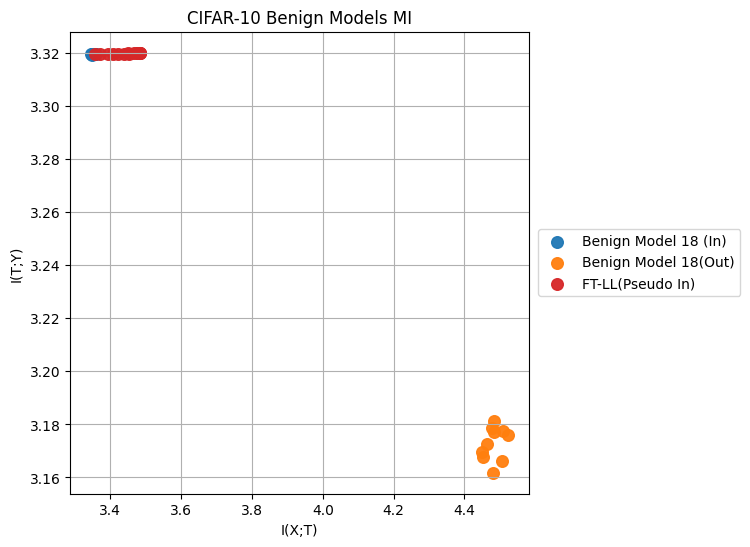

In [156]:
neg18_in_group = GroupSpec(
    label="Benign Model 18 (In)",
    csv_paths=neg_group_18,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

neg18_out_group = GroupSpec(
    label="Benign Model 18(Out)",
    csv_paths=neg_group_18,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

ft18_pseudo_in_group = GroupSpec(
    label="FT-LL(Pseudo In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_PseudoLabel_10000_42_1.0_FT-LL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)



plot_information_plane([neg18_in_group, neg18_out_group, ft18_pseudo_in_group], title="CIFAR-10 Benign Models MI")

In [ ]:
neg16_in_group = GroupSpec(
    label="Benign Model 16(In)",
    csv_paths=neg_group_16,
    domain="in",
    style={"marker": "x", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

neg16_out_group = GroupSpec(
    label="Benign Model 16(Out)",
    csv_paths=neg_group_16,
    domain="out",
    style={"marker": "x", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)


In [ ]:
target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)


plot_information_plane([target18_in_group, target18_out_group, ft18_pseudo_in_group, ft18_pseudo_out_group], title="ResNet18 CIFAR-10 Pseudo FT-LL")


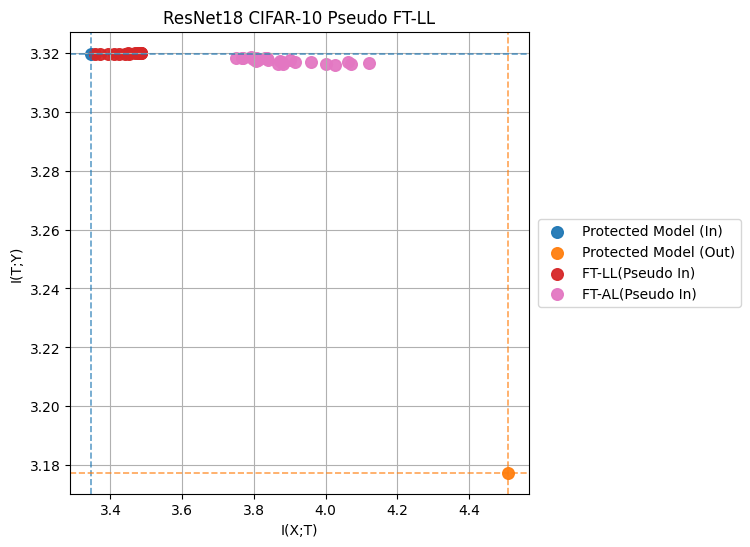

In [160]:
target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ftll18_pseudo_in_group = GroupSpec(
    label="FT-LL(Pseudo In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_PseudoLabel_10000_42_1.0_FT-LL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)

ftal18_pseudo_in_group = GroupSpec(
    label="FT-AL(Pseudo In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_PseudoLabel_10000_42_1.0_FT-AL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:pink", "s": 70, "alpha": 0.95},
    mode="trajectory",
)

plot_information_plane([target18_in_group, target18_out_group, ftll18_pseudo_in_group, ftal18_pseudo_in_group], title="ResNet18 CIFAR-10 Pseudo FT-LL")


In [146]:
import os
from dataclasses import dataclass
from typing import Callable, List, Optional, Dict, Any, Tuple, Literal, Union, Sequence

import pandas as pd
import matplotlib.pyplot as plt

Point = Dict[str, Any]
SelectFn = Callable[[List[Point]], List[Point]]


# -----------------------------
# Specs
# -----------------------------
@dataclass
class GroupSpec:
    label: str
    csv_paths: List[str]
    style: Dict[str, Any]

    domain: str = "in"
    epochs: Optional[List[int]] = None

    mode: Literal["points", "trajectory", "single"] = "points"
    connect: bool = False  # if True and mode="trajectory", draw per-file lines

    # selection reducer (applied per-file when mode in {"single","trajectory"}; and also in "points" if you want)
    select_fn: Optional[SelectFn] = None

    annotate: bool = False
    annotate_text_fn: Optional[Callable[[Point], str]] = None
    annotate_kwargs: Optional[Dict[str, Any]] = None

    # reference line controls
    ref_line: bool = False
    ref_line_style: Optional[Dict[str, Any]] = None
    ref_line_label: bool = False


@dataclass
class AnchorSpec:
    """
    Anchor is selected by returning a Point (NOT an index) from the group's plotted points.
    This avoids index mismatch after filtering / per-file reductions.
    """
    group_label: str
    select_fn: Callable[[List[Point]], Point]  # returns the selected anchor Point
    style: Dict[str, Any]
    annotate_text: Optional[str] = None
    annotate_kwargs: Optional[Dict[str, Any]] = None


@dataclass
class MemorySpec:
    label: str
    points: Union[Tuple[float, float], List[Tuple[float, float]]]
    style: Dict[str, Any]

    epochs: Optional[List[int]] = None

    mode: Literal["points", "trajectory", "single"] = "points"
    connect: bool = False

    ref_line: bool = False
    ref_line_style: Optional[Dict[str, Any]] = None
    ref_line_label: bool = False

    annotate_texts: Optional[List[str]] = None


# -----------------------------
# IO helpers
# -----------------------------
def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}. Available: {list(df.columns)}")


def read_mi_points(csv_path: str, domain: str, epoch_col: str = "Epoch") -> List[Point]:
    """
    Read all MI points from one CSV. Each row corresponds to one epoch.
    """
    df = pd.read_csv(csv_path)

    if domain == "in":
        ix_col = find_column(df, ["I(X;T)-In"])
        iy_col = find_column(df, ["I(T;Y)-In"])
    elif domain == "out":
        ix_col = find_column(df, ["I(X;T)-Out"])
        iy_col = find_column(df, ["I(T;Y)-Out"])
    else:
        raise ValueError("domain must be 'in' or 'out'")

    epochs = df[epoch_col].tolist() if epoch_col in df.columns else [None] * len(df)

    points: List[Point] = []
    for e, ix, iy in zip(epochs, df[ix_col], df[iy_col]):
        points.append({"path": csv_path, "epoch": e, "ix": float(ix), "iy": float(iy)})
    return points


def points_from_memoryspec(m: MemorySpec) -> List[Point]:
    pts = m.points
    if isinstance(pts, tuple) and len(pts) == 2 and isinstance(pts[0], (int, float)):
        pts = [pts]

    out: List[Point] = []
    for i, (ix, iy) in enumerate(pts):
        e = m.epochs[i] if (m.epochs is not None and i < len(m.epochs)) else None
        out.append({"path": "<memory>", "epoch": e, "ix": float(ix), "iy": float(iy)})
    return out


# -----------------------------
# Selection helpers
# -----------------------------
def select_last(points: List[Point]) -> List[Point]:
    return [points[-1]] if points else []


def select_first(points: List[Point]) -> List[Point]:
    return points[:1] if points else []


def select_epoch(e: int) -> SelectFn:
    def _sel(points: List[Point]) -> List[Point]:
        return [p for p in points if p.get("epoch", None) == e]
    return _sel


def select_best_by(key: str, maximize: bool = True) -> SelectFn:
    def _sel(points: List[Point]) -> List[Point]:
        if not points:
            return []
        return [max(points, key=lambda p: p[key])] if maximize else [min(points, key=lambda p: p[key])]
    return _sel


# -----------------------------
# Core plotting
# -----------------------------
def plot_information_plane(
    groups: Sequence[Union[GroupSpec, MemorySpec]],
    title: Optional[str] = None,
    figsize: Tuple[int, int] = (7, 6),
    grid: bool = True,
    plain_ticks: bool = True,
    anchor: Optional[AnchorSpec] = None,
    legend_outside: bool = True,
):
    """
    Final behavior:
    - GroupSpec supports multiple csv_paths robustly.
      * mode="single": one point PER FILE (after optional select_fn, else last)
      * mode="trajectory": one trajectory PER FILE (after optional select_fn; connect controls line drawing)
      * mode="points": all points from all files (optionally filtered by epochs; optional select_fn applied per-file)
    - AnchorSpec.select_fn returns an actual Point from the plotted points (no index mismatch).
    """

    # Storage:
    # - scatter_points[label] = flat list of points to scatter
    # - trajectories[label] = list of trajectories, each trajectory is list[Point] (per file)
    scatter_points: Dict[str, List[Point]] = {}
    trajectories: Dict[str, List[List[Point]]] = {}

    # -----------------------------
    # Load & prepare points
    # -----------------------------
    for g in groups:
        if isinstance(g, MemorySpec):
            pts = points_from_memoryspec(g)
            pts.sort(key=lambda x: (x["epoch"] is None, x["epoch"]))

            # single -> last point only
            if g.mode == "single" and len(pts) > 1:
                pts = pts[-1:]

            scatter_points[g.label] = pts
            trajectories[g.label] = [pts] if (g.mode == "trajectory") else []
            continue

        # ---- GroupSpec (CSV-backed) ----
        paths = g.csv_paths if isinstance(g.csv_paths, list) else [g.csv_paths]

        per_file_trajs: List[List[Point]] = []
        per_file_scatter: List[Point] = []

        for p in paths:
            pts_p = read_mi_points(p, g.domain)

            # epoch filter
            if g.epochs is not None:
                pts_p = [pt for pt in pts_p if pt["epoch"] in g.epochs]

            # sort by epoch inside each file
            pts_p.sort(key=lambda x: (x["epoch"] is None, x["epoch"]))

            # apply select_fn PER FILE (important!)
            if g.select_fn is not None:
                pts_p = g.select_fn(pts_p)

            if g.mode == "single":
                pts_p = pts_p[-1:] if pts_p else []
                per_file_scatter.extend(pts_p)

            elif g.mode == "trajectory":
                # keep each file's trajectory separately
                per_file_trajs.append(pts_p)
                per_file_scatter.extend(pts_p)

            else:  # "points"
                per_file_scatter.extend(pts_p)

        scatter_points[g.label] = per_file_scatter
        trajectories[g.label] = per_file_trajs

    # -----------------------------
    # Anchor selection (returns Point)
    # -----------------------------
    anchor_point: Optional[Point] = None
    if anchor is not None:
        if anchor.group_label not in scatter_points:
            raise ValueError(f"Anchor group '{anchor.group_label}' not found.")
        candidates = scatter_points[anchor.group_label]
        if not candidates:
            raise ValueError(f"Anchor group '{anchor.group_label}' has no points after filtering/selection.")
        anchor_point = anchor.select_fn(candidates)

        # sanity: must be one of the plotted points (match by path+epoch+coords)
        def _same(a: Point, b: Point) -> bool:
            return (
                a.get("path") == b.get("path")
                and a.get("epoch") == b.get("epoch")
                and abs(a.get("ix") - b.get("ix")) < 1e-12
                and abs(a.get("iy") - b.get("iy")) < 1e-12
            )
        if not any(_same(anchor_point, p) for p in candidates):
            raise ValueError("AnchorSpec.select_fn must return a point that exists in the group's plotted points.")

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=figsize)
    ax = plt.gca()

    legend_seen = set()

    for g in groups:
        pts = scatter_points.get(g.label, [])

        # Per-file trajectory lines
        if isinstance(g, GroupSpec) and g.mode == "trajectory" and g.connect and trajectories.get(g.label):
            # build line kwargs from scatter style
            line_kw = {}
            if "color" in g.style:
                line_kw["color"] = g.style["color"]
            if "alpha" in g.style:
                line_kw["alpha"] = g.style["alpha"]
            # optional extras
            line_kw.setdefault("linewidth", 1.2)

            for traj in trajectories[g.label]:
                if len(traj) >= 2:
                    xs = [pt["ix"] for pt in traj]
                    ys = [pt["iy"] for pt in traj]
                    ax.plot(xs, ys, **line_kw)

        # Scatter points
        for pt in pts:
            is_anchor = (
                anchor_point is not None
                and pt.get("path") == anchor_point.get("path")
                and pt.get("epoch") == anchor_point.get("epoch")
                and abs(pt["ix"] - anchor_point["ix"]) < 1e-12
                and abs(pt["iy"] - anchor_point["iy"]) < 1e-12
            )

            style = dict(g.style)
            label = "Anchor" if is_anchor else g.label

            # legend key: keep in/out separate if user uses same label accidentally by including domain
            legend_key = (label, getattr(g, "domain", None))
            label_for_scatter = None if legend_key in legend_seen else label
            legend_seen.add(legend_key)

            if is_anchor and anchor is not None:
                style.update(anchor.style)

            ax.scatter(pt["ix"], pt["iy"], label=label_for_scatter, **style)

            # Reference crosshair: draw only for "single" groups OR anchor point
            if getattr(g, "ref_line", False) and (getattr(g, "mode", None) == "single" or is_anchor):
                kw = {"linestyle": "--", "linewidth": 1.2, "alpha": 0.7}
                if getattr(g, "ref_line_style", None):
                    kw.update(g.ref_line_style)
                ax.axvline(pt["ix"], **kw)
                ax.axhline(pt["iy"], **kw)

                if getattr(g, "ref_line_label", False):
                    ax.annotate(
                        g.label,
                        (pt["ix"], pt["iy"]),
                        textcoords="offset points",
                        xytext=(6, 6),
                        fontsize=9,
                        alpha=0.9,
                    )

            # Custom annotations
            if getattr(g, "annotate", False) and getattr(g, "annotate_text_fn", None):
                text = g.annotate_text_fn(pt)
                akw = g.annotate_kwargs or {"xytext": (6, 6), "fontsize": 9, "alpha": 0.9}
                ax.annotate(text, (pt["ix"], pt["iy"]), textcoords="offset points", **akw)

            # Anchor annotation
            if is_anchor and anchor is not None and anchor.annotate_text:
                akw = anchor.annotate_kwargs or {"xytext": (8, 8), "fontsize": 9, "fontweight": "bold"}
                ax.annotate(anchor.annotate_text, (pt["ix"], pt["iy"]), textcoords="offset points", **akw)

    # -----------------------------
    # Formatting
    # -----------------------------
    ax.set_xlabel("I(X;T)")
    ax.set_ylabel("I(T;Y)")
    ax.set_title(title)

    if grid:
        ax.grid(True)

    if plain_ticks:
        ax.ticklabel_format(style="plain", axis="both", useOffset=False)

    # -----------------------------
    # Legend placement
    # -----------------------------
    if legend_outside:
        plt.subplots_adjust(right=0.78)
        ax.legend(
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
            frameon=True
        )
    else:
        ax.legend(frameon=True)

    plt.show()


# -----------------------------
# Example anchor selector (Point-based)
# -----------------------------
def anchor_by_rate_from_filename(rate: float = 1.0) -> Callable[[List[Point]], Point]:
    """
    Example: choose anchor among points whose filename token[-2] == rate.
    Works best when the group is mode="single" (one point per file), so each file contributes one candidate.
    """
    def _sel(points: List[Point]) -> Point:
        candidates: List[Point] = []
        for pt in points:
            fname = os.path.basename(pt["path"]).replace(".csv", "")
            toks = fname.split("_")
            try:
                r = float(toks[-2])
            except Exception:
                continue
            if abs(r - rate) < 1e-12:
                candidates.append(pt)

        if not candidates:
            raise ValueError(f"No points found with rate={rate} in filename token[-2].")

        # choose max iy (tie-breaker: min ix)
        return max(candidates, key=lambda p: (p["iy"], -p["ix"]))
    return _sel


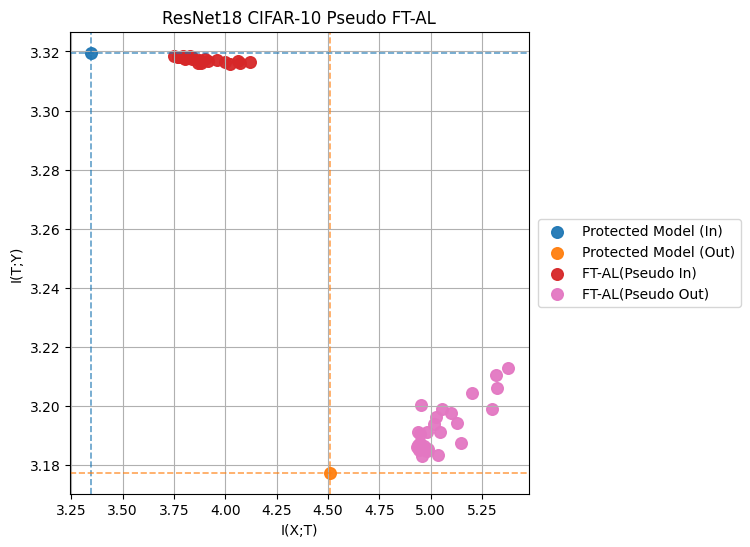

In [161]:
target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft18_pseudo_in_group = GroupSpec(
    label="FT-AL(Pseudo In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_PseudoLabel_10000_42_1.0_FT-AL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)

ft18_pseudo_out_group = GroupSpec(
    label="FT-AL(Pseudo Out)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_PseudoLabel_10000_42_1.0_FT-AL_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:pink", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target18_in_group, target18_out_group, ft18_pseudo_in_group, ft18_pseudo_out_group], title="ResNet18 CIFAR-10 Pseudo FT-AL")


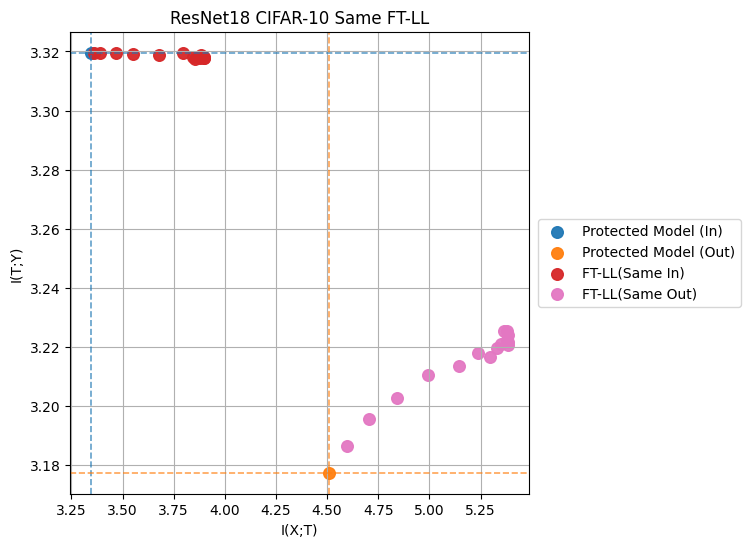

In [162]:
target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft18_pseudo_in_group = GroupSpec(
    label="FT-LL(Same In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_Same_10000_42_1.0_FT-LL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)

ft18_pseudo_out_group = GroupSpec(
    label="FT-LL(Same Out)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_Same_10000_42_1.0_FT-LL_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:pink", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target18_in_group, target18_out_group, ft18_pseudo_in_group,  ft18_pseudo_out_group], title="ResNet18 CIFAR-10 Same FT-LL")


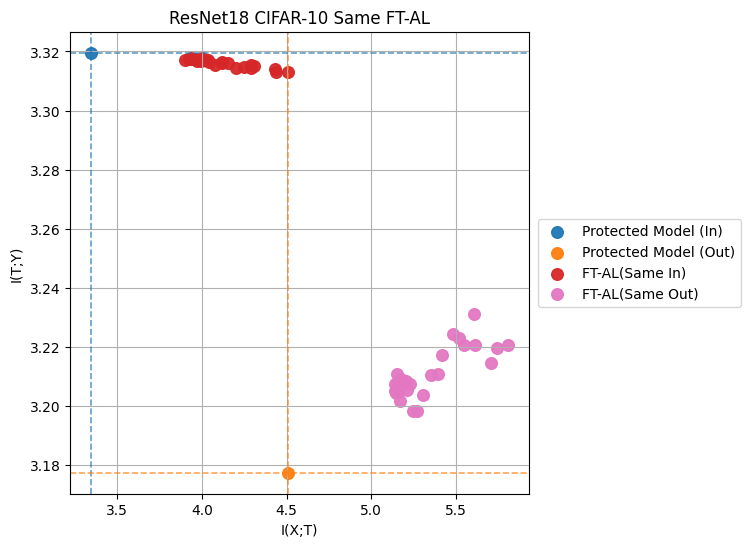

In [163]:
target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft18_pseudo_in_group = GroupSpec(
    label="FT-AL(Same In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_Same_10000_42_1.0_FT-AL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)

ft18_pseudo_out_group = GroupSpec(
    label="FT-AL(Same Out)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_Same_10000_42_1.0_FT-AL_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:pink", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target18_in_group, target18_out_group, ft18_pseudo_in_group, ft18_pseudo_out_group], title="ResNet18 CIFAR-10 Same FT-AL")


In [47]:
import pandas as pd
from typing import Tuple, Dict, Any, Optional

def find_column(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}\nAvailable: {list(df.columns)}")

def extract_mi_points_from_csv(
    csv_path: str,
    domain: str = "in",
    epoch_col_candidates=("Epoch", "epoch"),
    scenario_col_candidates=("Scenario", "scenario", "Scenario_Name", "ScenarioName"),
) -> pd.DataFrame:
    """
    Returns a DataFrame with columns:
      [scenario(optional), epoch(optional), ix, iy, inside(optional later)]
    One row per epoch (or per row in CSV).
    """
    df = pd.read_csv(csv_path)

    # domain -> choose columns
    if domain == "in":
        ix_col = find_column(df, ["I(X;T)-In", "I(X;T) - In", "IXT-In", "IXT_In"])
        iy_col = find_column(df, ["I(T;Y)-In", "I(T;Y) - In", "ITY-In", "ITY_In"])
    elif domain == "out":
        ix_col = find_column(df, ["I(X;T)-Out", "I(X;T) - Out", "IXT-Out", "IXT_Out"])
        iy_col = find_column(df, ["I(T;Y)-Out", "I(T;Y) - Out", "ITY-Out", "ITY_Out"])
    else:
        raise ValueError("domain must be 'in' or 'out'")

    # optional columns
    epoch_col = next((c for c in epoch_col_candidates if c in df.columns), None)
    scenario_col = next((c for c in scenario_col_candidates if c in df.columns), None)

    out = pd.DataFrame({
        "ix": pd.to_numeric(df[ix_col], errors="coerce"),
        "iy": pd.to_numeric(df[iy_col], errors="coerce"),
    })

    if epoch_col is not None:
        out["epoch"] = df[epoch_col]
    else:
        out["epoch"] = range(len(df))  # fallback

    if scenario_col is not None:
        out["scenario"] = df[scenario_col]
    else:
        out["scenario"] = None

    # keep only valid rows
    out = out.dropna(subset=["ix", "iy"]).reset_index(drop=True)

    # nice ordering
    out = out[["scenario", "epoch", "ix", "iy"]]
    return out

def filter_points_in_bounds(
    points_df: pd.DataFrame,
    x_low: float, x_high: float,
    y_low: float, y_high: float,
    inclusive: bool = False,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    Adds an 'inside' boolean column and returns:
      - full table with inside flag
      - summary dict
    """
    if inclusive:
        inside = (
            (points_df["ix"] >= x_low) & (points_df["ix"] <= x_high) &
            (points_df["iy"] >= y_low) & (points_df["iy"] <= y_high)
        )
    else:
        inside = (
            (points_df["ix"] > x_low) & (points_df["ix"] < x_high) &
            (points_df["iy"] > y_low) & (points_df["iy"] < y_high)
        )

    out = points_df.copy()
    out["inside"] = inside

    n_total = len(out)
    n_inside = int(out["inside"].sum())

    summary = {
        "n_total": n_total,
        "n_inside": n_inside,
        "pct_inside": (n_inside / n_total * 100.0) if n_total else 0.0,
        "x_low": x_low, "x_high": x_high,
        "y_low": y_low, "y_high": y_high,
        "inclusive": inclusive,
    }
    return out, summary


In [46]:
target_csv_path = "./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"
pts_in = extract_mi_points_from_csv(target_csv_path, domain="in")
pts_out = extract_mi_points_from_csv(target_csv_path, domain="out")

ixt_low, ity_high = float(pts_in["ix"].iloc[0]), float(pts_in["iy"].iloc[0])
ixt_high, ity_low = float(pts_out["ix"].iloc[0]), float(pts_out["iy"].iloc[0])
print(ixt_low)
print(ixt_high)
print(ity_low)
print(ity_high)

3.3641562461853027
4.517779350280762
3.178595542907715
3.319582939147949


In [48]:
ft_al_csv_path = "./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_Same_10000_42_1.0_FT-AL_MI.csv"

ft_al_pts_in = extract_mi_points_from_csv(ft_al_csv_path, domain="in")
table, summary = filter_points_in_bounds(ft_al_pts_in, ixt_low, ixt_high, ity_low, ity_high)
print(summary)

{'n_total': 25, 'n_inside': 22, 'pct_inside': 88.0, 'x_low': 3.3641562461853027, 'x_high': 4.517779350280762, 'y_low': 3.178595542907715, 'y_high': 3.319582939147949, 'inclusive': False}


In [49]:
ft_ll_csv_path = "./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_Same_10000_42_1.0_FT-LL_MI.csv"

ft_ll_pts_in = extract_mi_points_from_csv(ft_ll_csv_path, domain="in")
table, summary = filter_points_in_bounds(ft_ll_pts_in, ixt_low, ixt_high, ity_low, ity_high)
print(summary)

{'n_total': 15, 'n_inside': 12, 'pct_inside': 80.0, 'x_low': 3.3641562461853027, 'x_high': 4.517779350280762, 'y_low': 3.178595542907715, 'y_high': 3.319582939147949, 'inclusive': False}


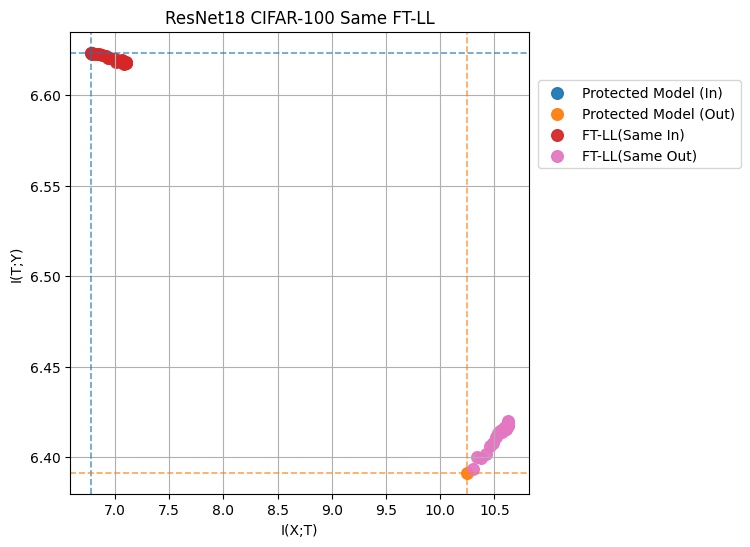

In [53]:
target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft18_same_in_group = GroupSpec(
    label="FT-LL(Same In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_Same_10000_42_1.0_FT-LL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)

ft18_same_out_group = GroupSpec(
    label="FT-LL(Same Out)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_Same_10000_42_1.0_FT-LL_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:pink", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target18_in_group, target18_out_group, ft18_same_in_group, ft18_same_out_group], title="ResNet18 CIFAR-100 Same FT-LL")


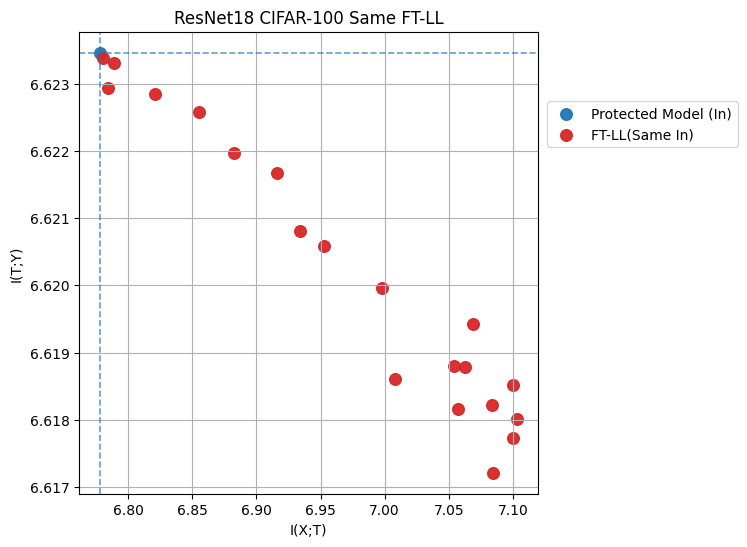

In [56]:
target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft18_same_in_group = GroupSpec(
    label="FT-LL(Same In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_Same_10000_42_1.0_FT-LL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)

ft18_same_out_group = GroupSpec(
    label="FT-LL(Same Out)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_Same_10000_42_1.0_FT-LL_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:pink", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target18_in_group, ft18_same_in_group], title="ResNet18 CIFAR-100 Same FT-LL")


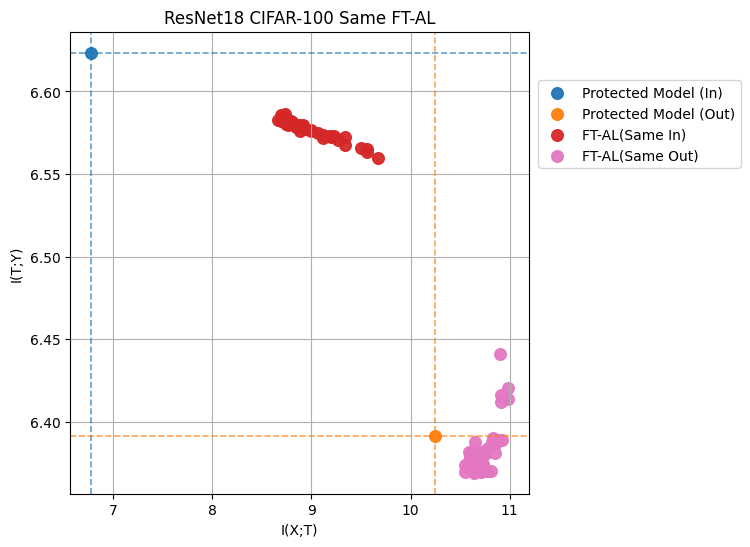

In [55]:
target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft18_same_in_group = GroupSpec(
    label="FT-AL(Same In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_Same_10000_42_1.0_FT-AL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)

ft18_same_out_group = GroupSpec(
    label="FT-AL(Same Out)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_Same_10000_42_1.0_FT-AL_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:pink", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target18_in_group, target18_out_group, ft18_same_in_group, ft18_same_out_group], title="ResNet18 CIFAR-100 Same FT-AL")


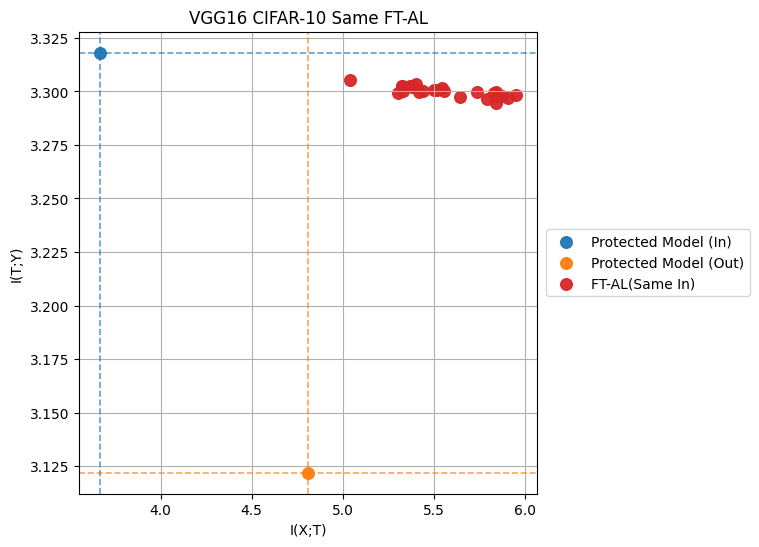

In [102]:
target16_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target16_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft16_same_in_group = GroupSpec(
    label="FT-AL(Same In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_VGG16_40000_Same_10000_42_1.0_FT-AL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target16_in_group, target16_out_group, ft16_same_in_group], title="VGG16 CIFAR-10 Same FT-AL")


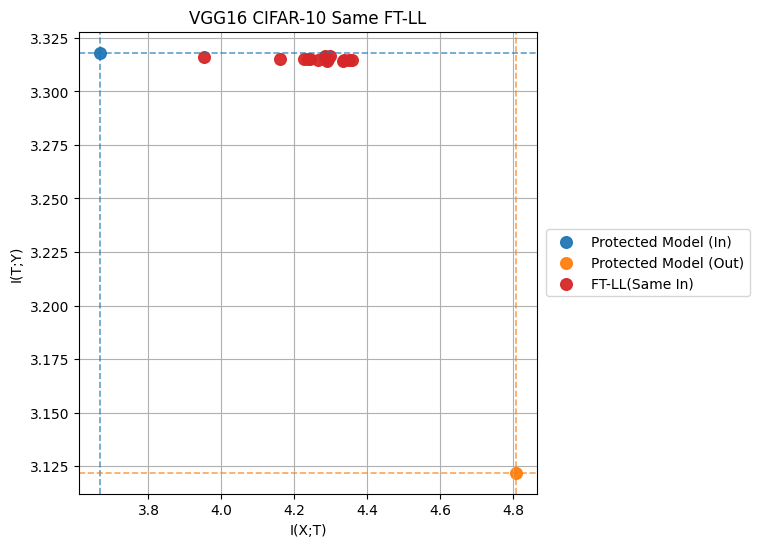

In [103]:
target16_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target16_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft16_same_in_group = GroupSpec(
    label="FT-LL(Same In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_VGG16_40000_Same_10000_42_1.0_FT-LL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target16_in_group, target16_out_group, ft16_same_in_group], title="VGG16 CIFAR-10 Same FT-LL")


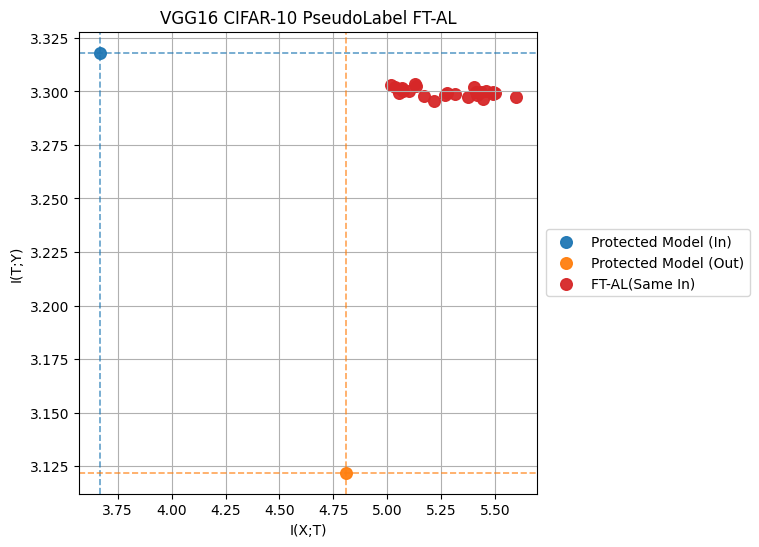

In [104]:
target16_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target16_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft16_same_in_group = GroupSpec(
    label="FT-AL(Same In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_VGG16_40000_PseudoLabel_10000_42_1.0_FT-AL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target16_in_group, target16_out_group, ft16_same_in_group], title="VGG16 CIFAR-10 PseudoLabel FT-AL")


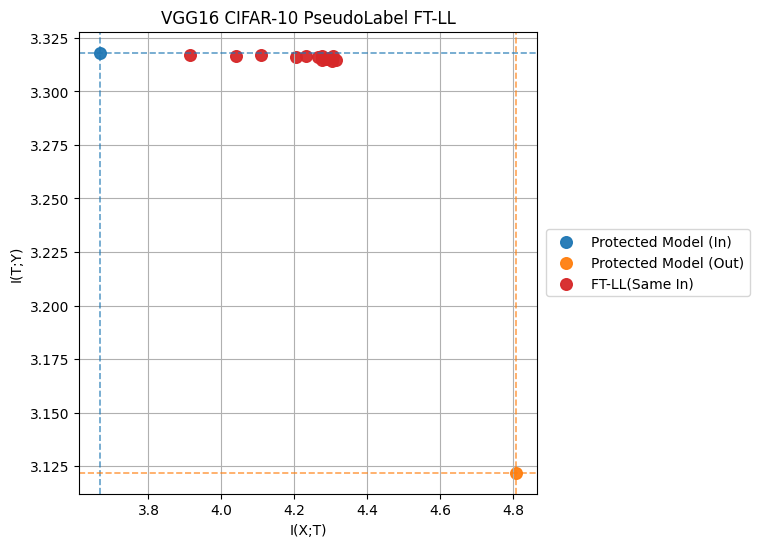

In [105]:
target16_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target16_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft16_same_in_group = GroupSpec(
    label="FT-LL(Same In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_VGG16_40000_PseudoLabel_10000_42_1.0_FT-LL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target16_in_group, target16_out_group, ft16_same_in_group], title="VGG16 CIFAR-10 PseudoLabel FT-LL")


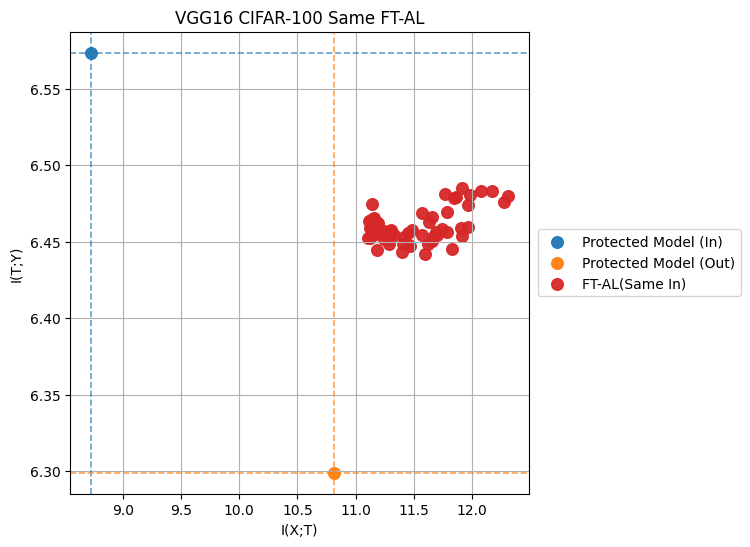

In [106]:
target16_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_VGG16_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target16_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_VGG16_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft16_same_in_group = GroupSpec(
    label="FT-AL(Same In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-100_VGG16_40000_Same_10000_42_1.0_FT-AL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target16_in_group, target16_out_group, ft16_same_in_group], title="VGG16 CIFAR-100 Same FT-AL")


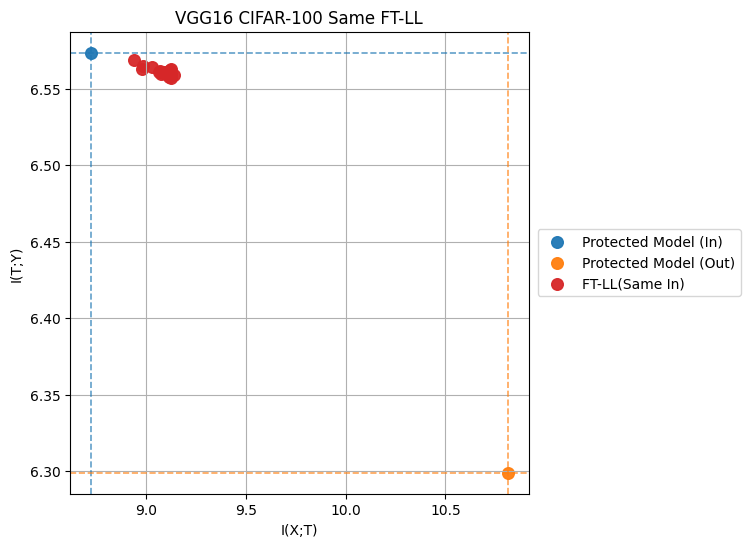

In [107]:
target16_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_VGG16_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target16_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_VGG16_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft16_same_in_group = GroupSpec(
    label="FT-LL(Same In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-100_VGG16_40000_Same_10000_42_1.0_FT-LL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target16_in_group, target16_out_group, ft16_same_in_group], title="VGG16 CIFAR-100 Same FT-LL")


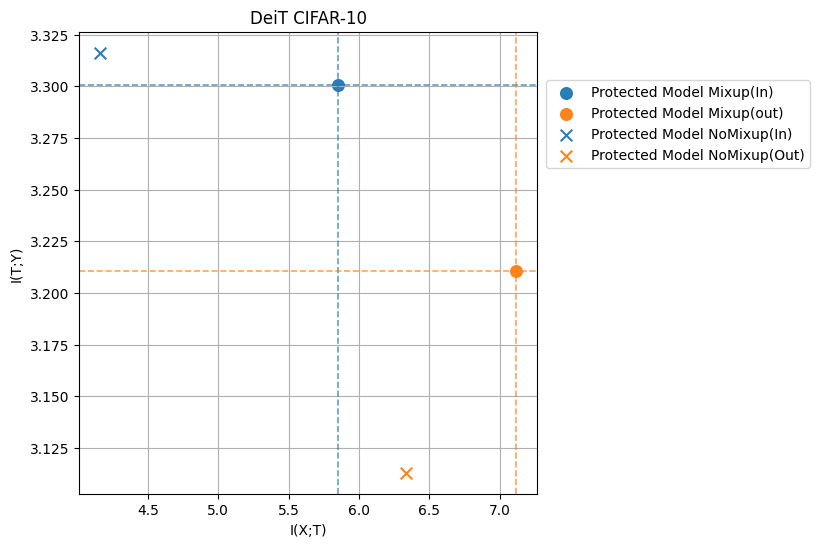

In [58]:
deit_in_group_mixup = GroupSpec(
    label="Protected Model Mixup(In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_DeiT_40000_Mixup_Hard_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

deit_out_group_mixup = GroupSpec(
    label="Protected Model Mixup(out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_DeiT_40000_Mixup_Hard_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:orange"},
)

deit_in_group_nomixup = GroupSpec(
    label="Protected Model NoMixup(In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_DeiT_40000_NoMixup_Hard_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "x", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

deit_out_group_nomixup = GroupSpec(
    label="Protected Model NoMixup(Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_DeiT_40000_NoMixup_Hard_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "x", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)


plot_information_plane([deit_in_group_mixup, deit_out_group_mixup, deit_in_group_nomixup, deit_out_group_nomixup], title="DeiT CIFAR-10")


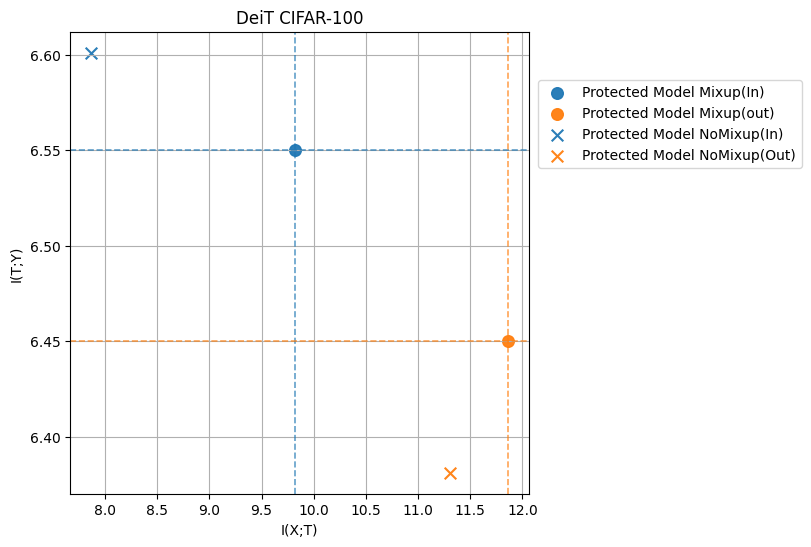

In [59]:
deit_in_group_mixup = GroupSpec(
    label="Protected Model Mixup(In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_DeiT_40000_Mixup_Hard_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

deit_out_group_mixup = GroupSpec(
    label="Protected Model Mixup(out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_DeiT_40000_Mixup_Hard_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:orange"},
)

deit_in_group_nomixup = GroupSpec(
    label="Protected Model NoMixup(In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_DeiT_40000_NoMixup_Hard_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "x", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

deit_out_group_nomixup = GroupSpec(
    label="Protected Model NoMixup(Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-100_DeiT_40000_NoMixup_Hard_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "x", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)


plot_information_plane([deit_in_group_mixup, deit_out_group_mixup, deit_in_group_nomixup, deit_out_group_nomixup], title="DeiT CIFAR-100")


# Knowledge Distillation

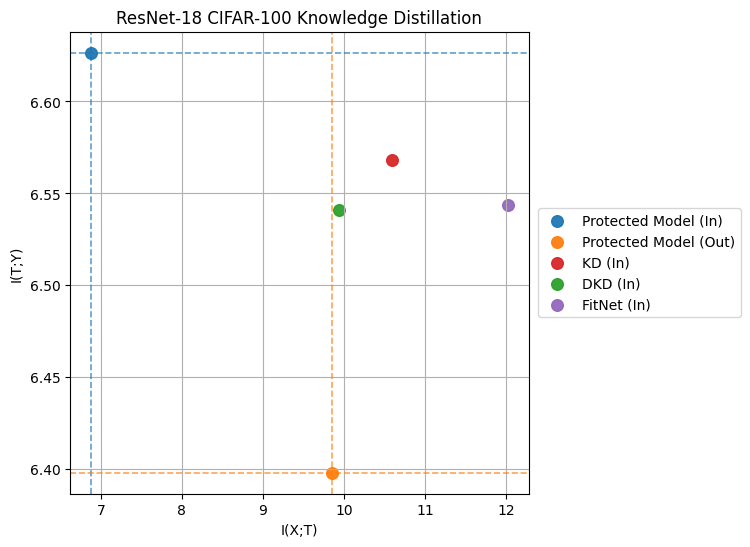

In [112]:
target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/distillation/MI/training_log_CIFAR-100_ResNet32x4_DKD_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/distillation/MI/training_log_CIFAR-100_ResNet32x4_DKD_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

dkd18_in_group = GroupSpec(
    label="KD (In)",
    csv_paths=["./saved_logs/distillation/MI/training_log_CIFAR-100_ResNet8x4_DKD_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="trajectory",
)

kd18_in_group = GroupSpec(
    label="DKD (In)",
    csv_paths=["./saved_logs/distillation/MI/training_log_CIFAR-100_ResNet8x4_KD_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:green", "s": 70, "alpha": 0.95},
    mode="trajectory",
)

fitnet18_in_group = GroupSpec(
    label="FitNet (In)",
    csv_paths=["./saved_logs/distillation/MI/training_log_CIFAR-100_ResNet8x4_Fitnet_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:purple", "s": 70, "alpha": 0.95},
    mode="trajectory",
)


plot_information_plane([target18_in_group, target18_out_group, dkd18_in_group, kd18_in_group, fitnet18_in_group], 
                       title="ResNet-18 CIFAR-100 Knowledge Distillation")


# -----------------------------------------------------------------

In [76]:
import numpy as np
def generate_csv_paths(file_dir, dataset, model, victim_seed, rate_ls):
    csv_ls = []
    for rate in rate_ls:
        csv_name = f"training_log_{dataset}_{model}_{victim_seed}_{rate}_MI.csv"
        csv_ls.append(file_dir + csv_name)

    return csv_ls

DATASET = ["CIFAR-10"]
MODEL = ["ResNet-18","VGG16"]
VICTIM_SEED = range(42, 43)

OVERLAPPING = np.linspace(0,1,11)
SUPER = range(5000, 25001, 5000)

neg_group_dict = {}
for d in DATASET:
    for m in MODEL:
        for s in VICTIM_SEED:
            neg_group1 = generate_csv_paths("./saved_logs/normal_nega/MI/", d, m, s, OVERLAPPING)
        neg_group_dict[m] = neg_group1

## Baseline Negative Group

In [9]:
neg18_in_group_spec = GroupSpec(
    label="Negative Group (In)",
    csv_paths=neg_group_dict['ResNet-18'],
    domain = "in",
    style={"marker": "o", "color": "tab:blue", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

neg18_out_group_spec = GroupSpec(
    label="Negative Group (Out)",
    csv_paths=neg_group_dict['ResNet-18'],
    domain = "out",
    style={"marker": "o", "color": "tab:orange", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

neg16_in_group_spec = GroupSpec(
    label="Negative Group (In)",
    csv_paths=neg_group_dict['VGG16'],
    domain = "in",
    style={"marker": "o", "color": "tab:blue", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

neg16_out_group_spec = GroupSpec(
    label="Negative Group(Out)",
    csv_paths=neg_group_dict['VGG16'],
    domain = "out",
    style={"marker": "o", "color": "tab:orange", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

anchor_spec = AnchorSpec(
    group_label="Negative Group (In)",
    select_fn=select_anchor_by_rate_1p0,
    style={"marker": "*", "s": 180, "alpha": 1.0, "color": "tab:blue",
           "edgecolors": "black", "linewidths": 1.2},
    annotate_text="1.0 (anchor)",
    annotate_kwargs={"xytext": (8, 8), "fontsize": 9, "fontweight": "bold"}
)

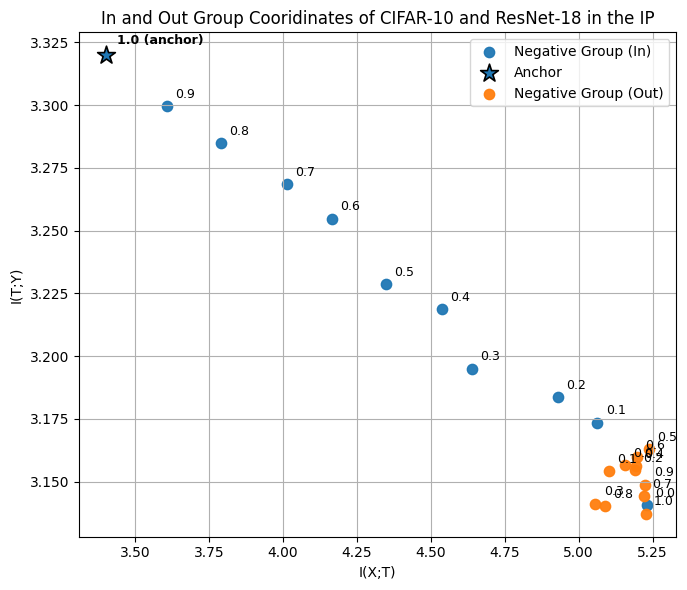

In [11]:
plot_information_plane(
    groups=[neg18_in_group_spec, neg18_out_group_spec],
    title="In and Out Group Cooridinates of CIFAR-10 and ResNet-18 in the IP",
    anchor=anchor_spec
)

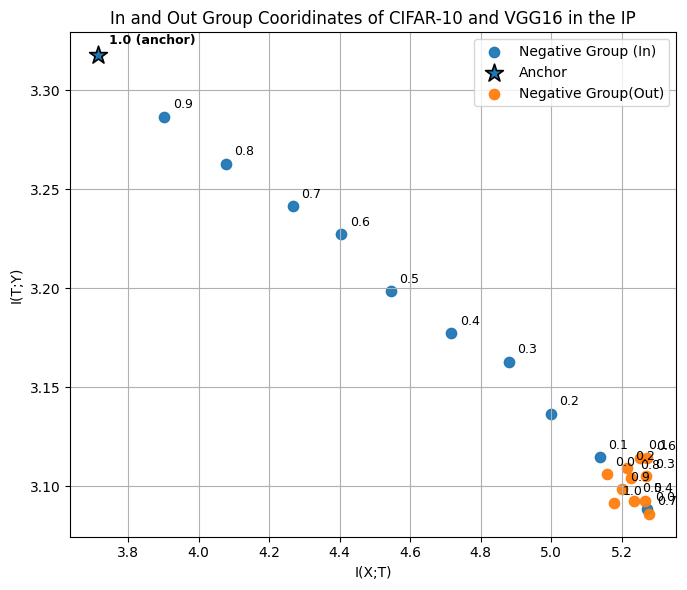

In [12]:
plot_information_plane(
    groups=[neg16_in_group_spec, neg16_out_group_spec],
    title="In and Out Group Cooridinates of CIFAR-10 and VGG16 in the IP",
    anchor=anchor_spec
)

## Model Pruning at Different Rate (0.2, 0.6, and 0.8) - Global Pruning

### Case 1: Pruning without Restoring Fine-tune

In [14]:
prune18_paths = ["./saved_logs/prune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_0.2_MI.csv",
              "./saved_logs/prune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_0.6_MI.csv",
              "./saved_logs/prune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_0.8_MI.csv"]
prune16_paths = ["./saved_logs/prune_new1/MI/training_log_CIFAR-10_VGG16_42_1.0_0.2_MI.csv",
              "./saved_logs/prune_new1/MI/training_log_CIFAR-10_VGG16_42_1.0_0.6_MI.csv",
              "./saved_logs/prune_new1/MI/training_log_CIFAR-10_VGG16_42_1.0_0.8_MI.csv"]

pr1802_in_group_spec = GroupSpec(
    label="pr=0.2",
    csv_paths=[prune18_paths[0]],
    domain = "in",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1806_in_group_spec = GroupSpec(
    label="pr=0.6",
    csv_paths=[prune18_paths[1]],
    domain = "in",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1808_in_group_spec = GroupSpec(
    label="pr=0.8",
    csv_paths=[prune18_paths[2]],
    domain = "in",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1802_out_group_spec = GroupSpec(
    label="pr=0.2",
    csv_paths=[prune18_paths[0]],
    domain = "out",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1806_out_group_spec = GroupSpec(
    label="pr=0.6",
    csv_paths=[prune18_paths[1]],
    domain = "out",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1808_out_group_spec = GroupSpec(
    label="pr=0.8",
    csv_paths=[prune18_paths[2]],
    domain = "out",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

In [15]:
pr1602_in_group_spec = GroupSpec(
    label="pr=0.2",
    csv_paths=[prune16_paths[0]],
    domain = "in",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1606_in_group_spec = GroupSpec(
    label="pr=0.6",
    csv_paths=[prune16_paths[1]],
    domain = "in",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1608_in_group_spec = GroupSpec(
    label="pr=0.8",
    csv_paths=[prune16_paths[2]],
    domain = "in",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1602_out_group_spec = GroupSpec(
    label="pr=0.2",
    csv_paths=[prune16_paths[0]],
    domain = "out",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1606_out_group_spec = GroupSpec(
    label="pr=0.6",
    csv_paths=[prune16_paths[1]],
    domain = "out",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1608_out_group_spec = GroupSpec(
    label="pr=0.8",
    csv_paths=[prune16_paths[2]],
    domain = "out",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

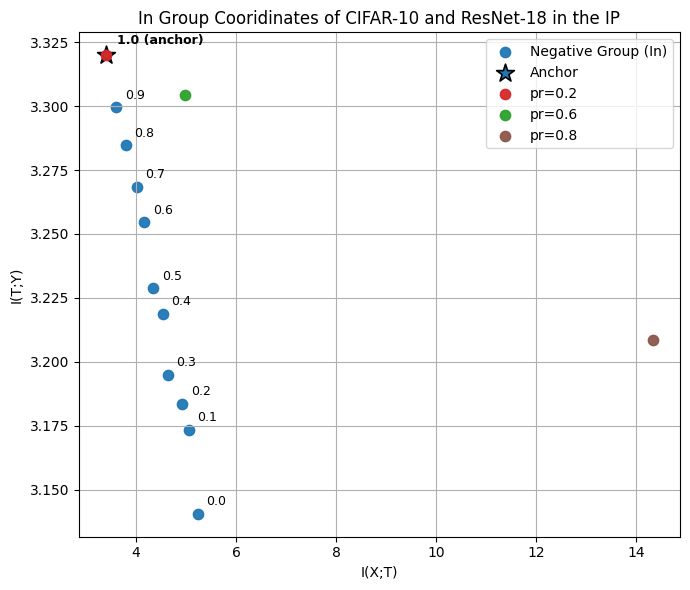

In [16]:
plot_information_plane(
    groups=[neg18_in_group_spec, pr1802_in_group_spec, pr1806_in_group_spec, pr1808_in_group_spec],
    title="In Group Cooridinates of CIFAR-10 and ResNet-18 in the IP",
    anchor=anchor_spec
)

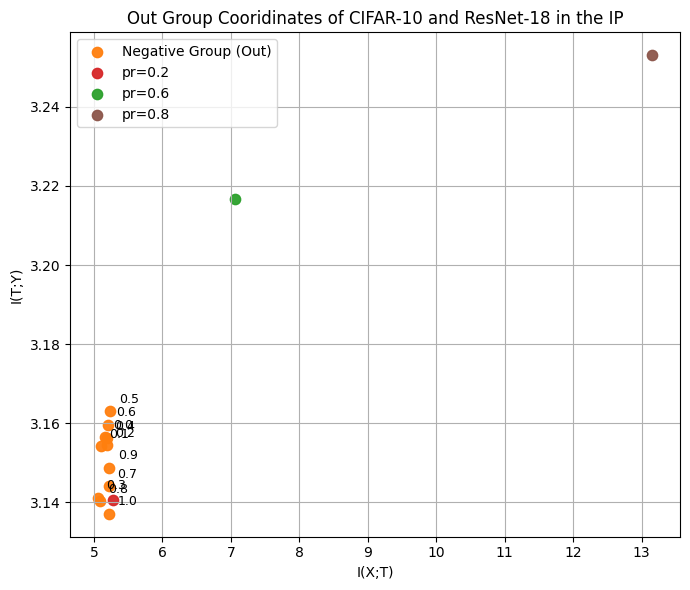

In [17]:
plot_information_plane(
    groups=[neg18_out_group_spec, pr1802_out_group_spec, pr1806_out_group_spec, pr1808_out_group_spec],
    title="Out Group Cooridinates of CIFAR-10 and ResNet-18 in the IP",
    anchor=None
) 

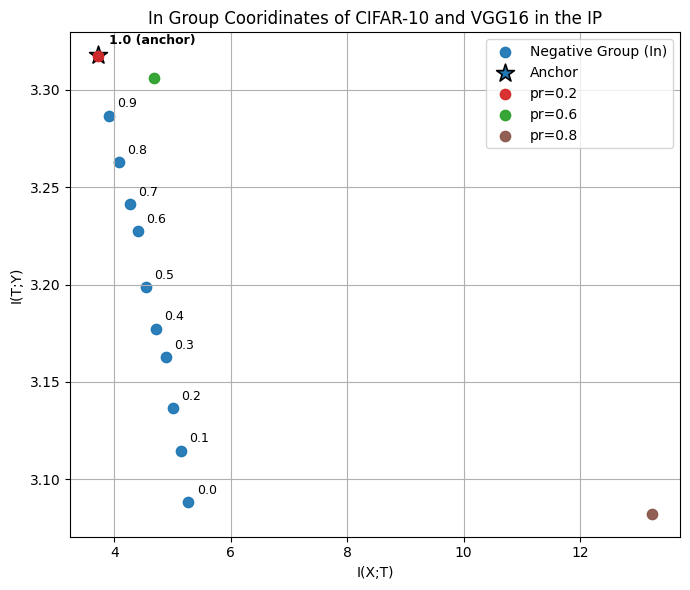

In [18]:
plot_information_plane(
    groups=[neg16_in_group_spec, pr1602_in_group_spec, pr1606_in_group_spec, pr1608_in_group_spec],
    title="In Group Cooridinates of CIFAR-10 and VGG16 in the IP",
    anchor=anchor_spec
)

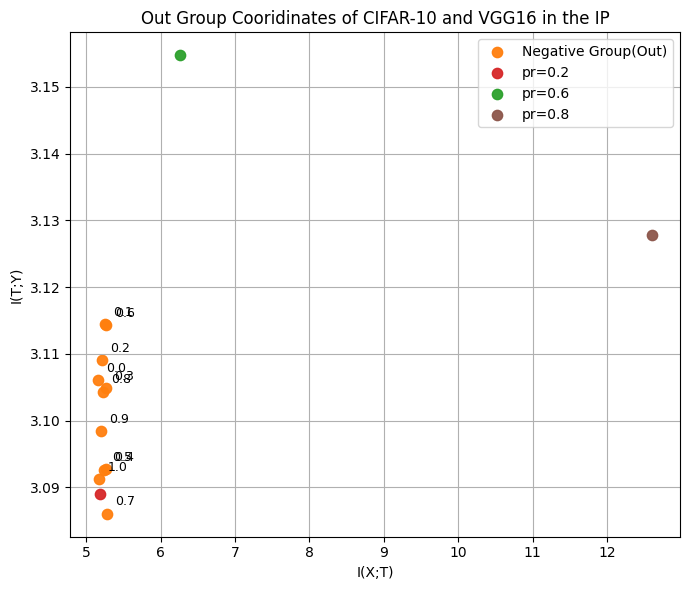

In [19]:
plot_information_plane(
    groups=[neg16_out_group_spec, pr1602_out_group_spec, pr1606_out_group_spec, pr1608_out_group_spec],
    title="Out Group Cooridinates of CIFAR-10 and VGG16 in the IP",
    anchor=None
) 

In [20]:
import pandas as pd

def show_log_table(
    csv_path: str,
    scenario: str | None = None,
    epoch_in: list[int] | None = None,
    sort_by: str = "Epoch",
    ascending: bool = True,
    cols: list[str] | None = None,
    max_rows: int | None = None,
    float_digits: int = 6,
):
    """
    Load a training/eval log CSV and print an extracted table in the notebook.

    Args:
        csv_path: path to your CSV log file.
        scenario: exact Scenario string to filter (None => no Scenario filter).
        epoch_in: list of epoch values to keep (e.g. [-2, -1] or [0,1,2]).
        sort_by: column to sort by (default 'Epoch').
        ascending: sort order.
        cols: columns to display (None => show all).
        max_rows: optionally truncate output to top N rows after filtering/sorting.
        float_digits: rounding digits for floats when printing.
    Returns:
        df_view: the filtered dataframe (so you can reuse it).
    """
    df = pd.read_csv(csv_path)

    # Basic normalization for safety
    if "Scenario" in df.columns and scenario is not None:
        df = df[df["Scenario"].astype(str) == str(scenario)]

    if "Epoch" in df.columns and epoch_in is not None:
        df = df[df["Epoch"].isin(epoch_in)]

    if sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=ascending)

    if cols is not None:
        missing = [c for c in cols if c not in df.columns]
        if missing:
            raise KeyError(f"Requested columns not found in CSV: {missing}")
        df_view = df[cols].copy()
    else:
        df_view = df.copy()

    if max_rows is not None:
        df_view = df_view.head(max_rows)

    # Pretty print in notebook
    with pd.option_context(
        "display.max_rows", None if max_rows is None else max_rows,
        "display.max_columns", None,
        "display.width", 0,
        "display.float_format", (lambda x: f"{x:.{float_digits}f}"),
    ):
        display(df_view)  # Jupyter notebook rich display

    return df_view


In [24]:
# show the two pre-eval rows (-1 and -2)
show_log_table(
    csv_path="./saved_logs/prune_new1/Performance/training_log_CIFAR-10_ResNet-18_42_1.0_0.2.csv",
    scenario="CIFAR-10_ResNet-18_42_1.0_0.2",
    epoch_in=[-1, -2],
    cols=["Epoch","Train_Loss","Train_Acc","Train_Precision","Train_Recall","Train_F1",
          "Test_Loss","Test_Acc","Test_Precision","Test_Recall","Test_F1"],
    float_digits=6
);


,Epoch,Train_Loss,Train_Acc,Train_Precision,Train_Recall,Train_F1,Test_Loss,Test_Acc,Test_Precision,Test_Recall,Test_F1
1,-2,0.001032,100.000000,1.000000,1.000000,1.000000,0.312178,91.930000,0.919300,0.919300,0.919300
0,-1,0.001032,100.000000,1.000000,1.000000,1.000000,0.190364,94.520000,0.945200,0.945200,0.945200


In [25]:
show_log_table(
    csv_path="./saved_logs/prune_new1/Performance/training_log_CIFAR-10_ResNet-18_42_1.0_0.6.csv",
    scenario="CIFAR-10_ResNet-18_42_1.0_0.6",
    epoch_in=[-1, -2],
    cols=["Epoch","Train_Loss","Train_Acc","Train_Precision","Train_Recall","Train_F1",
          "Test_Loss","Test_Acc","Test_Precision","Test_Recall","Test_F1"],
    float_digits=6
);

,Epoch,Train_Loss,Train_Acc,Train_Precision,Train_Recall,Train_F1,Test_Loss,Test_Acc,Test_Precision,Test_Recall,Test_F1
1,-2,0.016377,99.988000,0.999880,0.999880,0.999880,0.263164,91.780000,0.917800,0.917800,0.917800
0,-1,0.016377,99.988000,0.999880,0.999880,0.999880,0.192278,93.930000,0.939300,0.939300,0.939300


In [26]:
show_log_table(
    csv_path="./saved_logs/prune_new1/Performance/training_log_CIFAR-10_ResNet-18_42_1.0_0.8.csv",
    scenario="CIFAR-10_ResNet-18_42_1.0_0.8",
    epoch_in=[-1, -2],
    cols=["Epoch","Train_Loss","Train_Acc","Train_Precision","Train_Recall","Train_F1",
          "Test_Loss","Test_Acc","Test_Precision","Test_Recall","Test_F1"],
    float_digits=6
);

,Epoch,Train_Loss,Train_Acc,Train_Precision,Train_Recall,Train_F1,Test_Loss,Test_Acc,Test_Precision,Test_Recall,Test_F1
1,-2,0.625517,95.968000,0.959680,0.959680,0.959680,0.795672,84.300000,0.843000,0.843000,0.843000
0,-1,0.625517,95.968000,0.959680,0.959680,0.959680,0.780465,84.570000,0.845700,0.845700,0.845700


In [27]:
show_log_table(
    csv_path="./saved_logs/prune_new1/Performance/training_log_CIFAR-10_VGG16_42_1.0_0.2.csv",
    scenario="CIFAR-10_VGG16_42_1.0_0.2",
    epoch_in=[-1, -2],
    cols=["Epoch","Train_Loss","Train_Acc","Train_Precision","Train_Recall","Train_F1",
          "Test_Loss","Test_Acc","Test_Precision","Test_Recall","Test_F1"],
    float_digits=6
);

,Epoch,Train_Loss,Train_Acc,Train_Precision,Train_Recall,Train_F1,Test_Loss,Test_Acc,Test_Precision,Test_Recall,Test_F1
1,-2,0.008172,99.792000,0.997920,0.997920,0.997920,0.351507,90.940000,0.909400,0.909400,0.909400
0,-1,0.008172,99.792000,0.997920,0.997920,0.997920,0.227626,93.520000,0.935200,0.935200,0.935200


In [28]:
show_log_table(
    csv_path="./saved_logs/prune_new1/Performance/training_log_CIFAR-10_VGG16_42_1.0_0.6.csv",
    scenario="CIFAR-10_VGG16_42_1.0_0.6",
    epoch_in=[-1, -2],
    cols=["Epoch","Train_Loss","Train_Acc","Train_Precision","Train_Recall","Train_F1",
          "Test_Loss","Test_Acc","Test_Precision","Test_Recall","Test_F1"],
    float_digits=6
);

,Epoch,Train_Loss,Train_Acc,Train_Precision,Train_Recall,Train_F1,Test_Loss,Test_Acc,Test_Precision,Test_Recall,Test_F1
1,-2,0.021185,99.720000,0.997200,0.997200,0.997200,0.312710,90.540000,0.905400,0.905400,0.905400
0,-1,0.021185,99.720000,0.997200,0.997200,0.997200,0.246259,92.540000,0.925400,0.925400,0.925400


In [29]:
show_log_table(
    csv_path="./saved_logs/prune_new1/Performance/training_log_CIFAR-10_VGG16_42_1.0_0.8.csv",
    scenario="CIFAR-10_VGG16_42_1.0_0.8",
    epoch_in=[-1, -2],
    cols=["Epoch","Train_Loss","Train_Acc","Train_Precision","Train_Recall","Train_F1",
          "Test_Loss","Test_Acc","Test_Precision","Test_Recall","Test_F1"],
    float_digits=6
);

,Epoch,Train_Loss,Train_Acc,Train_Precision,Train_Recall,Train_F1,Test_Loss,Test_Acc,Test_Precision,Test_Recall,Test_F1
1,-2,1.074165,69.668000,0.696680,0.696680,0.696680,1.239811,62.510000,0.625100,0.625100,0.625100
0,-1,1.074165,69.668000,0.696680,0.696680,0.696680,1.242016,67.000000,0.670000,0.670000,0.670000


In [30]:
prune18_paths = ["./saved_logs/prune_new/MI/training_log_CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL_MI.csv",
              "./saved_logs/prune_new/MI/training_log_CIFAR-10_ResNet-18_42_1.0_0.6_FT-AL_MI.csv",
              "./saved_logs/prune_new/MI/training_log_CIFAR-10_ResNet-18_42_1.0_0.8_FT-AL_MI.csv"]
prune16_paths = ["./saved_logs/prune_new/MI/training_log_CIFAR-10_VGG16_42_1.0_0.2_FT-AL_MI.csv",
              "./saved_logs/prune_new/MI/training_log_CIFAR-10_VGG16_42_1.0_0.6_FT-AL_MI.csv",
              "./saved_logs/prune_new/MI/training_log_CIFAR-10_VGG16_42_1.0_0.8_FT-AL_MI.csv"]

pr1802_in_group_spec = GroupSpec(
    label="pr=0.2",
    csv_paths=[prune18_paths[0]],
    domain = "in",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1806_in_group_spec = GroupSpec(
    label="pr=0.6",
    csv_paths=[prune18_paths[1]],
    domain = "in",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1808_in_group_spec = GroupSpec(
    label="pr=0.8",
    csv_paths=[prune18_paths[2]],
    domain = "in",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1802_out_group_spec = GroupSpec(
    label="pr=0.2",
    csv_paths=[prune18_paths[0]],
    domain = "out",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1806_out_group_spec = GroupSpec(
    label="pr=0.6",
    csv_paths=[prune18_paths[1]],
    domain = "out",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr1808_out_group_spec = GroupSpec(
    label="pr=0.8",
    csv_paths=[prune18_paths[2]],
    domain = "out",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

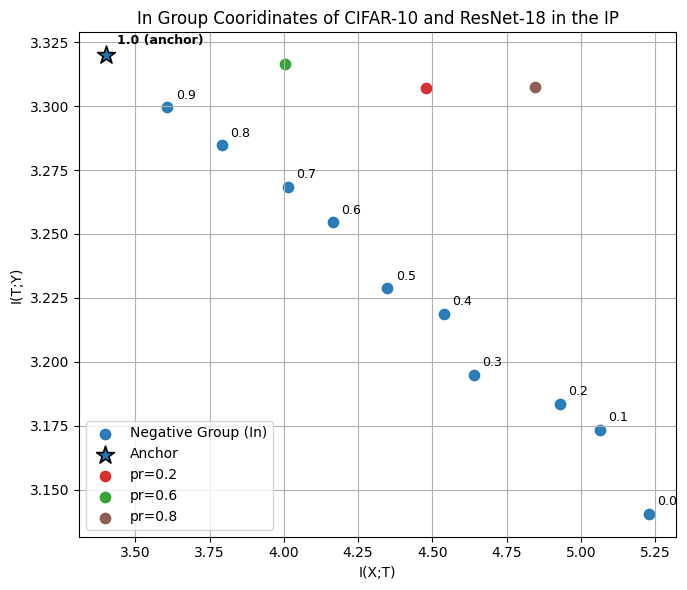

In [31]:
plot_information_plane(
    groups=[neg18_in_group_spec, pr1802_in_group_spec, pr1806_in_group_spec, pr1808_in_group_spec],
    title="In Group Cooridinates of CIFAR-10 and ResNet-18 in the IP",
    anchor=anchor_spec
)

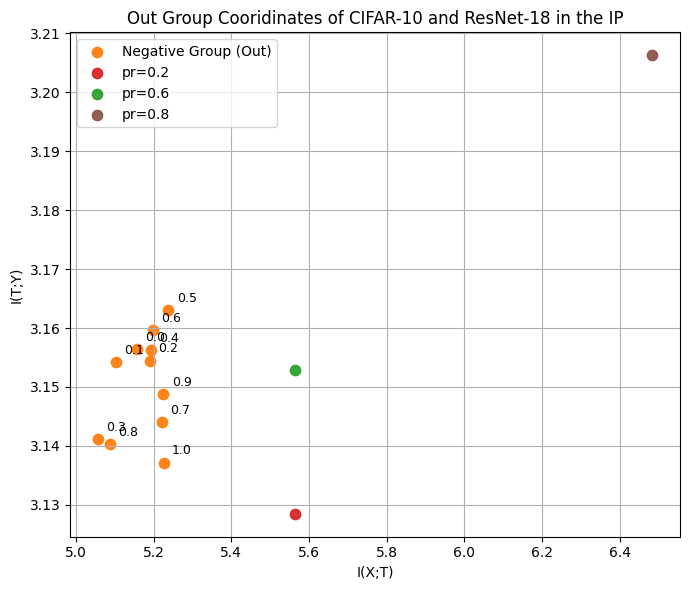

In [32]:
plot_information_plane(
    groups=[neg18_out_group_spec, pr1802_out_group_spec, pr1806_out_group_spec, pr1808_out_group_spec],
    title="Out Group Cooridinates of CIFAR-10 and ResNet-18 in the IP",
    anchor=None
) 

In [57]:
def check_pruned_weights(model):
    """
    Inspect the sparsity (percentage of zero weights) in each pruned layer.
    Also prints global sparsity across the entire model.
    """
    total_weights = 0
    total_zero = 0

    print("\n=== PRUNING CHECKER ===")
    for name, module in model.named_modules():

        # Only examine Conv2d and Linear layers (pruned layers)
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            if hasattr(module, "weight"):
                w = module.weight.data.cpu().numpy()
                num_total = w.size
                num_zero = (w == 0).sum()

                layer_sparsity = num_zero / num_total * 100

                print(f"{name}.weight: zero = {num_zero}/{num_total}  "
                      f"({layer_sparsity:.2f}% sparsity)")

                total_weights += num_total
                total_zero += num_zero

    global_sparsity = total_zero / total_weights * 100
    print(f"\nGLOBAL SPARSITY: {global_sparsity:.2f}%\n")
    return global_sparsity

def check_pruned_masks(model):
    print("\n=== PRUNING MASK CHECKER ===")
    total_zeros = 0
    total_params = 0

    for name, module in model.named_modules():
        if hasattr(module, "weight_mask"):
            mask = module.weight_mask
            zeros = (mask == 0).sum().item()
            total = mask.numel()

            print(f"{name}.mask: zero = {zeros}/{total} ({100*zeros/total:.2f}% sparsity)")

            total_zeros += zeros
            total_params += total

    if total_params > 0:
        print(f"\nGLOBAL MASK SPARSITY: {100*total_zeros/total_params:.2f}%")


In [65]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_name = "CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL"
model_dir = './saved_models/prune_new/'
model_folder = Path(model_dir)/model_name

ckpt_path = load_checkpoint_from_epoch(model_folder, "latest")
print(ckpt_path)
net = ResNet18(num_classes=10)
pruned_net = prune_model_global(model=net, amount=0.2)
state = torch.load(ckpt_path, map_location=device)
pruned_net.load_state_dict(state)

remove_prune_mask(pruned_net)

check_pruned_weights(pruned_net)

saved_models\prune_new\CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL\epoch_19.pth

=== PRUNING CHECKER ===
conv1.weight: zero = 109/1728  (6.31% sparsity)
layer1.0.conv1.weight: zero = 10362/36864  (28.11% sparsity)
layer1.0.conv2.weight: zero = 6557/36864  (17.79% sparsity)
layer1.1.conv1.weight: zero = 7070/36864  (19.18% sparsity)
layer1.1.conv2.weight: zero = 6139/36864  (16.65% sparsity)
layer2.0.conv1.weight: zero = 9981/73728  (13.54% sparsity)
layer2.0.conv2.weight: zero = 17316/147456  (11.74% sparsity)
layer2.0.downsample.0.weight: zero = 498/8192  (6.08% sparsity)
layer2.1.conv1.weight: zero = 17340/147456  (11.76% sparsity)
layer2.1.conv2.weight: zero = 14225/147456  (9.65% sparsity)
layer3.0.conv1.weight: zero = 20456/294912  (6.94% sparsity)
layer3.0.conv2.weight: zero = 43963/589824  (7.45% sparsity)
layer3.0.downsample.0.weight: zero = 1487/32768  (4.54% sparsity)
layer3.1.conv1.weight: zero = 50673/589824  (8.59% sparsity)
layer3.1.conv2.weight: zero = 61074/589824  (10.35% spar

np.float64(19.999996417167782)

In [67]:
ckpt_path = load_checkpoint_from_epoch(model_folder, epoch=15)
print(ckpt_path)
net = ResNet18(num_classes=10)
pruned_net = prune_model_global(model=net, amount=0.2)
state = torch.load(ckpt_path, map_location=device)
pruned_net.load_state_dict(state)

remove_prune_mask(pruned_net)

check_pruned_weights(pruned_net)

saved_models\prune_new\CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL\epoch_15.pth

=== PRUNING CHECKER ===
conv1.weight: zero = 109/1728  (6.31% sparsity)
layer1.0.conv1.weight: zero = 10362/36864  (28.11% sparsity)
layer1.0.conv2.weight: zero = 6557/36864  (17.79% sparsity)
layer1.1.conv1.weight: zero = 7070/36864  (19.18% sparsity)
layer1.1.conv2.weight: zero = 6139/36864  (16.65% sparsity)
layer2.0.conv1.weight: zero = 9981/73728  (13.54% sparsity)
layer2.0.conv2.weight: zero = 17316/147456  (11.74% sparsity)
layer2.0.downsample.0.weight: zero = 498/8192  (6.08% sparsity)
layer2.1.conv1.weight: zero = 17340/147456  (11.76% sparsity)
layer2.1.conv2.weight: zero = 14225/147456  (9.65% sparsity)
layer3.0.conv1.weight: zero = 20456/294912  (6.94% sparsity)
layer3.0.conv2.weight: zero = 43963/589824  (7.45% sparsity)
layer3.0.downsample.0.weight: zero = 1487/32768  (4.54% sparsity)
layer3.1.conv1.weight: zero = 50673/589824  (8.59% sparsity)
layer3.1.conv2.weight: zero = 61074/589824  (10.35% spar

np.float64(19.999996417167782)

In [68]:
model_name = "CIFAR-10_ResNet-18_42_1.0"
model_dir = './saved_models/normal_nega/'
model_folder = Path(model_dir)/model_name

ckpt_path = load_checkpoint_from_epoch(model_folder, "latest")
print(ckpt_path)
base_state = torch.load(ckpt_path, map_location=device)
net = ResNet18(num_classes=10)
net.load_state_dict(base_state)
pruned_net = prune_model_global(model=net, amount=0.2)

remove_prune_mask(pruned_net)

check_pruned_weights(pruned_net)

saved_models\normal_nega\CIFAR-10_ResNet-18_42_1.0\epoch_99.pth

=== PRUNING CHECKER ===
conv1.weight: zero = 109/1728  (6.31% sparsity)
layer1.0.conv1.weight: zero = 10362/36864  (28.11% sparsity)
layer1.0.conv2.weight: zero = 6557/36864  (17.79% sparsity)
layer1.1.conv1.weight: zero = 7070/36864  (19.18% sparsity)
layer1.1.conv2.weight: zero = 6139/36864  (16.65% sparsity)
layer2.0.conv1.weight: zero = 9981/73728  (13.54% sparsity)
layer2.0.conv2.weight: zero = 17316/147456  (11.74% sparsity)
layer2.0.downsample.0.weight: zero = 498/8192  (6.08% sparsity)
layer2.1.conv1.weight: zero = 17340/147456  (11.76% sparsity)
layer2.1.conv2.weight: zero = 14225/147456  (9.65% sparsity)
layer3.0.conv1.weight: zero = 20456/294912  (6.94% sparsity)
layer3.0.conv2.weight: zero = 43963/589824  (7.45% sparsity)
layer3.0.downsample.0.weight: zero = 1487/32768  (4.54% sparsity)
layer3.1.conv1.weight: zero = 50673/589824  (8.59% sparsity)
layer3.1.conv2.weight: zero = 61074/589824  (10.35% sparsity)
la

np.float64(19.999996417167782)

In [ ]:
model_name = "CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL"
model_dir = './saved_models/prune_new/'
model_folder = Path(model_dir)/model_name

ckpt_path = load_checkpoint_from_epoch(model_folder, epoch=15)
print(ckpt_path)
net2 = ResNet18(num_classes=10)
pruned_net2 = prune_model_global(model=net2, amount=0.2)
state2 = torch.load(ckpt_path, map_location=device)

net.load_state_dict(state)

saved_models\normal_nega\CIFAR-10_ResNet-18_42_1.0\epoch_99.pth


# ------------------------------------------------------------------------

In [68]:
from pathlib import Path
import numpy as np

def balanced_subset_from_indices(
    dataset,
    base_indices,
    subset_size,
    num_classes,
    seed=42,
):
    """
    Build a class-balanced subset of `subset_size` from `base_indices`.
    Assumes `dataset[idx] -> (_, y)`.

    Returns: list[int] subset_indices (subset of base_indices)
    """
    rng = np.random.default_rng(seed)

    if subset_size % num_classes != 0:
        raise ValueError(f"subset_size={subset_size} must be divisible by num_classes={num_classes}")

    k_per_class = subset_size // num_classes
    base_set = set(base_indices)

    # bucket only indices that are in base_indices
    by_class = {c: [] for c in range(num_classes)}
    for idx in base_indices:
        _, y = dataset[idx]
        by_class[int(y)].append(idx)

    # sample k_per_class from each class
    subset = []
    for c in range(num_classes):
        arr = np.array(by_class[c], dtype=int)
        if len(arr) < k_per_class:
            raise ValueError(
                f"Not enough samples in class {c} within base_indices: "
                f"have {len(arr)}, need {k_per_class}"
            )
        rng.shuffle(arr)
        subset.extend(arr[:k_per_class])

    rng.shuffle(subset)
    return subset


In [191]:
exp_setup

{'Dataset': <Dataset.CIFAR_10.CIFAR10Dataset at 0x23b38b22e40>,
 'NumClasses': 10,
 'GroupSize': 40000,
 'Model': ModifiedVGG16(
   (features): Sequential(
     (0): vgg16_conv_block(
       (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (1): vgg16_conv_block(
       (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
       (dropout): Dropout(p=0.3, inplace=False)
     )
     (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (3): vgg16_conv_block(
       (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, 

# Creating Overlapping Train Dataset Benign Models

In [ ]:
from util import *
from calculate_MI import *

exp_dir = "./saved_exp_plan/train_plan"
yaml_files = sorted(glob.glob(os.path.join(exp_dir, "*.yaml")))
yaml_file_path = yaml_files[1]

exp_yaml = process_yaml_file(yaml_file_path)
exp_setup = process_experiment_setup(exp_yaml) 

print(device)
print('==> Loading model..')
model_name = exp_yaml["Scenario_Name"] + f"_{42}_{1.0}"
model_dir = './saved_models/vanilla/'
model_folder = Path(model_dir)/model_name

# ckpt_path = load_last_checkpoint(model_folder)
ckpt_path = load_best_checkpoint(model_folder)
if ckpt_path is None:
    print(f"[⚠️] No .pth files found in {model_folder}")

net = exp_setup["Model"].to(device) # load model
state = torch.load(ckpt_path, map_location=device)
net.load_state_dict(state)

print('==> Preparing data..')
g = torch.Generator()
g.manual_seed(42)

in_sample_set = exp_setup["Dataset"].in_sample_set # No data augmentation here
out_sample_set =  exp_setup["Dataset"].test_set

group_A = create_or_load_group_A(dataset=in_sample_set, save_dir=f'./Indices/{exp_yaml['Dataset']['name']}/',
                                                  group_size=exp_setup["GroupSize"], num_classes=exp_setup["NumClasses"], seed=42, force_rebuild=False)

group_B = create_or_load_group_B(group_size=10000, overlap_rate=0.0, 
                                         save_dir=f'./Indices/{exp_yaml['Dataset']['name']}/',
                                         seed=42)
frac_ls = [ ]

for frac in np.arange(0.05, 1.0, 0.05):
    mix_idx, mix_A, mix_B = create_class_balanced_mix_from_A_B(
        dataset=in_sample_set,
        group_A_indices=group_A,
        group_B_indices=group_B,
        num_classes=10,
        total_size=10000,
        frac_from_A=round(frac,2),
        seed=42,
        return_parts=True,
    )    
    in_sample_subset = exp_setup["Dataset"].subset("train", mix_idx, clean=True)
    in_sample_loader = DataLoader(in_sample_subset,batch_size=128,shuffle=False,num_workers=8, # in sample without augmentation
                    worker_init_fn=seed_worker,generator=g, persistent_workers=True, 
                    pin_memory=True)
    value_xt_in, value_ty_in = evaluate2(net, in_sample_loader, device)
    frac_ls.append((value_xt_in, value_ty_in))

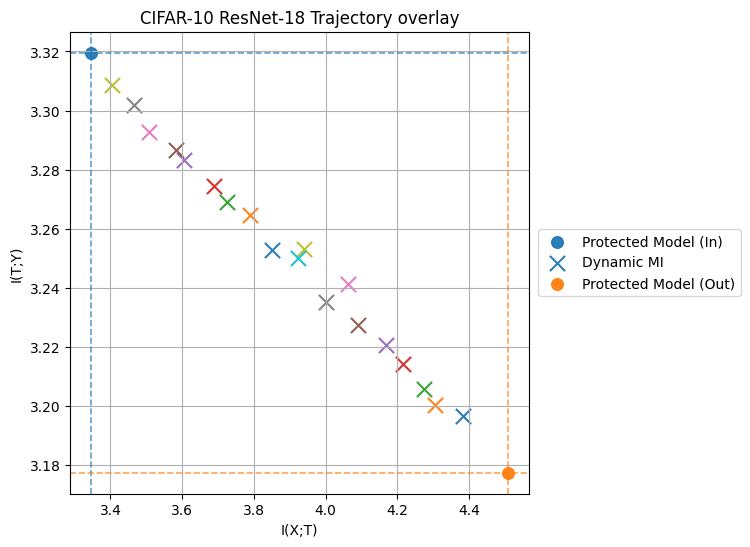

In [175]:
dyn = MemorySpec(
    label="Dynamic MI",
    points=frac_ls,
    style={"marker": "x", "s": 120, "alpha": 0.95},
)

target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)
plot_information_plane([target18_in_group, dyn, target18_out_group], title="CIFAR-10 ResNet-18 Trajectory overlay")

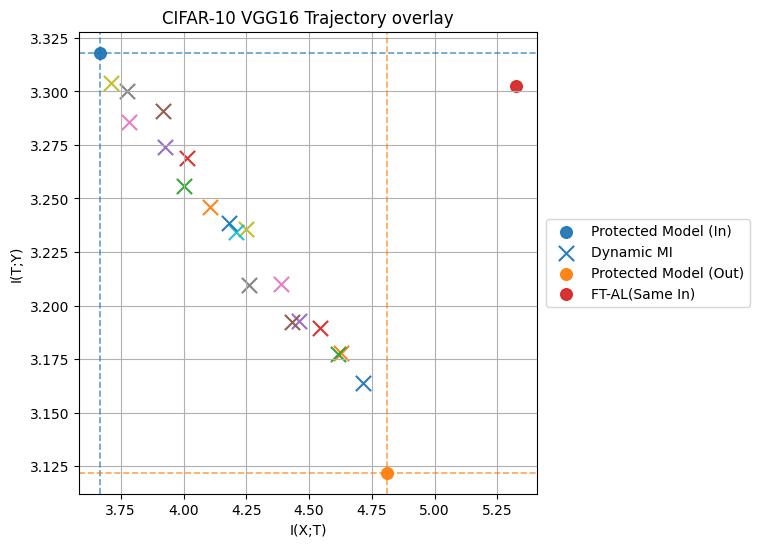

In [178]:
dyn = MemorySpec(
    label="Dynamic MI",
    points=frac_ls,
    style={"marker": "x", "s": 120, "alpha": 0.95},
)

target16_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target16_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)

ft16_same_in_group = GroupSpec(
    label="FT-AL(Same In)",
    csv_paths=["./saved_logs/fine_tune_vanilla/MI/training_log_CIFAR-10_VGG16_40000_Same_10000_42_1.0_FT-AL_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:red", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
)

plot_information_plane([target16_in_group, dyn, target16_out_group, ft16_same_in_group], title="CIFAR-10 VGG16 Trajectory overlay")

cuda
this time experiment blueprint:{'Scenario_Name': 'CIFAR-10_ResNet-18_40000', 'Dataset': {'name': 'CIFAR-10', 'normalization': 'cifar10', 'img_size': 32, 'train_transforms': [{'name': 'RandomCrop', 'params': {'size': 32, 'padding': 4}}, {'name': 'RandomHorizontalFlip', 'params': {'p': 0.5}}, {'name': 'ToTensor'}, {'name': 'Normalize'}], 'test_transforms': [{'name': 'ToTensor'}, {'name': 'Normalize'}], 'group_size': 40000}, 'Model': 'ResNet-18', 'Optimizer': {'name': 'SGD', 'params': {'lr': 0.1, 'momentum': 0.9, 'weight_decay': 0.0005, 'nesterov': True}}, 'Scheduler': {'name': 'CosineAnnealingLR', 'params': {'T_max': 100, 'eta_min': 1e-06}}, 'Epochs': 100, 'BatchSize': 128}
==> Loading model..
[📦] Loading best checkpoint: best_epoch.pth
==> Preparing data..


In [84]:
group_A = create_or_load_group_A(dataset=in_sample_set, save_dir=f'./Indices/{exp_yaml['Dataset']['name']}/',
                                                  group_size=exp_setup["GroupSize"], num_classes=exp_setup["NumClasses"], seed=42, force_rebuild=False)

group_B = create_or_load_group_B(group_size=10000, overlap_rate=0.0, 
                                         save_dir=f'./Indices/{exp_yaml['Dataset']['name']}/',
                                         seed=42)

[INFO] Loading Group A from Indices\CIFAR-10\group_A_40000_seed42.npy
[INFO] Loading Group B from Indices\CIFAR-10\group_B_10000_0.0_seed42.npy


In [ ]:
num_ls = []

for num in [5000, 10000, 20000, 30000, 35000]:
    group_A_small = balanced_subset_from_indices(
        dataset=in_sample_set,
        base_indices=group_A,
        subset_size=num, # 10000 out of 40000 training samples
        num_classes=exp_setup["NumClasses"],
        seed=42,
    )
    in_sample_subset = exp_setup["Dataset"].subset("train", group_A_small, clean=True)
    in_sample_loader = DataLoader(in_sample_subset,batch_size=128,shuffle=False,num_workers=8, # in sample without augmentation
                    worker_init_fn=seed_worker,generator=g, persistent_workers=True, 
                    pin_memory=True)
    value_xt_in, value_ty_in = evaluate2(net, in_sample_loader, device)
    num_ls.append((value_xt_in, value_ty_in))

In [81]:
print(num_ls)

[(3.365607261657715, 3.3198471069335938), (3.3720850944519043, 3.3173673152923584), (3.3386759757995605, 3.31882643699646), (3.3505043983459473, 3.3193299770355225), (3.3389182090759277, 3.3219282627105713)]


In [85]:
in_sample_subset = exp_setup["Dataset"].subset("train", group_B, clean=True)
in_sample_loader = DataLoader(in_sample_subset,batch_size=128,shuffle=False,num_workers=8, # in sample without augmentation
                worker_init_fn=seed_worker,generator=g, persistent_workers=True, 
                pin_memory=True)
value_xt_in, value_ty_in = evaluate2(net, in_sample_loader, device)

Out features are 10.
MI calculation begins:
2.4087233543395996
MI calculation ends.


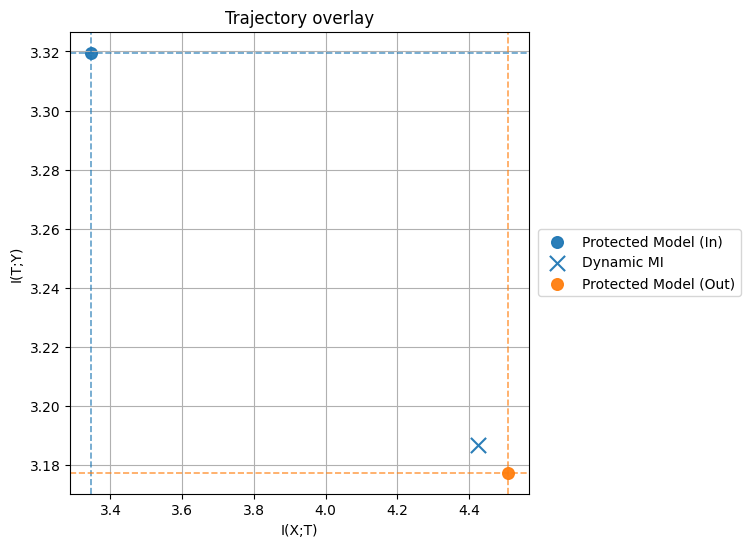

In [86]:
dyn = MemorySpec(
    label="Dynamic MI",
    points=(value_xt_in, value_ty_in),
    style={"marker": "x", "s": 120, "alpha": 0.95},
)

target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)
plot_information_plane([target18_in_group, dyn, target18_out_group], title="Trajectory overlay")

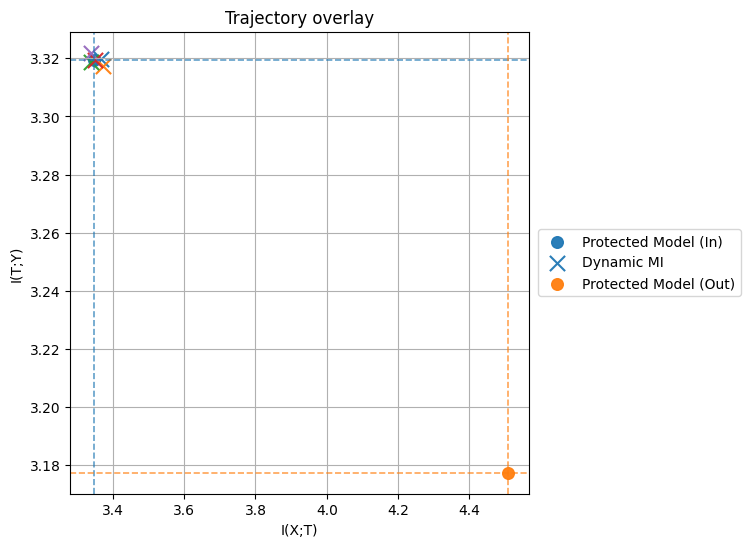

In [83]:
dyn = MemorySpec(
    label="Dynamic MI",
    points=num_ls,
    style={"marker": "x", "s": 120, "alpha": 0.95},
)

target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)
plot_information_plane([target18_in_group, dyn], title="Trajectory overlay")

In [164]:
import numpy as np
from typing import Sequence, Optional, Tuple, Union, List, Dict

def create_class_balanced_mix_from_A_B(
    dataset,
    group_A_indices: Sequence[int],
    group_B_indices: Sequence[int],
    num_classes: int = 10,
    total_size: Optional[int] = None,          # total mixed size (must be divisible by num_classes)
    per_class: Optional[int] = None,           # alternative: directly set per-class size
    frac_from_A: Optional[float] = None,       # if set, take this fraction per class from A
    per_class_from_A: Optional[int] = None,    # alternative: directly set per-class count from A
    seed: int = 42,
    replace: bool = False,
    shuffle: bool = True,
    return_parts: bool = False,
) -> Union[np.ndarray, Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """
    Build a mixed index set that is class-balanced, drawing from class-balanced group_A and group_B.

    You specify the mixed size either by:
      - total_size (must be divisible by num_classes), OR
      - per_class (#samples per class in the final mixed set)

    And specify composition either by:
      - frac_from_A (0..1), OR
      - per_class_from_A (integer)

    Returns:
      mixed indices (np.ndarray), optionally also (picked_A, picked_B).
    """
    rng = np.random.default_rng(seed)

    A = np.array(list(group_A_indices), dtype=int)
    B = np.array(list(group_B_indices), dtype=int)

    # ---- determine per_class ----
    if per_class is None:
        if total_size is None:
            raise ValueError("Provide either total_size or per_class.")
        if total_size % num_classes != 0:
            raise ValueError(f"total_size={total_size} must be divisible by num_classes={num_classes}.")
        per_class = total_size // num_classes
    else:
        per_class = int(per_class)

    # ---- determine per_class_from_A ----
    if per_class_from_A is None:
        if frac_from_A is None:
            raise ValueError("Provide either frac_from_A or per_class_from_A.")
        if not (0.0 <= frac_from_A <= 1.0):
            raise ValueError("frac_from_A must be in [0, 1].")
        per_class_from_A = int(round(per_class * frac_from_A))
    else:
        per_class_from_A = int(per_class_from_A)

    per_class_from_B = per_class - per_class_from_A
    if per_class_from_B < 0:
        raise ValueError("per_class_from_A cannot exceed per_class.")

    # ---- build A_by_class, B_by_class (like your B function) ----
    A_by_class: Dict[int, List[int]] = {c: [] for c in range(num_classes)}
    for idx in A:
        _, y = dataset[idx]
        A_by_class[int(y)].append(int(idx))

    B_by_class: Dict[int, List[int]] = {c: [] for c in range(num_classes)}
    for idx in B:
        _, y = dataset[idx]
        B_by_class[int(y)].append(int(idx))

    picked_A = []
    picked_B = []

    # ---- sample per class ----
    for c in range(num_classes):
        A_c = np.array(A_by_class[c], dtype=int)
        B_c = np.array(B_by_class[c], dtype=int)

        if not replace:
            if per_class_from_A > len(A_c):
                raise ValueError(f"Class {c}: need {per_class_from_A} from A, only {len(A_c)} available.")
            if per_class_from_B > len(B_c):
                raise ValueError(f"Class {c}: need {per_class_from_B} from B, only {len(B_c)} available.")

        if per_class_from_A > 0:
            picked_A.append(rng.choice(A_c, size=per_class_from_A, replace=replace))
        if per_class_from_B > 0:
            picked_B.append(rng.choice(B_c, size=per_class_from_B, replace=replace))

    picked_A = np.concatenate(picked_A) if picked_A else np.array([], dtype=int)
    picked_B = np.concatenate(picked_B) if picked_B else np.array([], dtype=int)

    mixed = np.concatenate([picked_A, picked_B])

    if shuffle:
        rng.shuffle(mixed)

    if return_parts:
        return mixed, picked_A, picked_B
    return mixed

In [ ]:
frac_ls = [ ]

for frac in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    mix_idx, mix_A, mix_B = create_class_balanced_mix_from_A_B(
        dataset=in_sample_set,
        group_A_indices=group_A,
        group_B_indices=group_B,
        num_classes=10,
        total_size=10000,
        frac_from_A=frac,
        seed=42,
        return_parts=True,
    )    
    in_sample_subset = exp_setup["Dataset"].subset("train", mix_idx, clean=True)
    in_sample_loader = DataLoader(in_sample_subset,batch_size=128,shuffle=False,num_workers=8, # in sample without augmentation
                    worker_init_fn=seed_worker,generator=g, persistent_workers=True, 
                    pin_memory=True)
    value_xt_in, value_ty_in = evaluate2(net, in_sample_loader, device)
    frac_ls.append((value_xt_in, value_ty_in))

In [171]:
import numpy as np

# start, stop (exclusive), step
for frac in np.arange(0.05, 1.0, 0.05):
    print(round(frac, 2))

0.05
0.1
0.15
0.2
0.25
0.3
0.35
0.4
0.45
0.5
0.55
0.6
0.65
0.7
0.75
0.8
0.85
0.9
0.95


In [100]:
dyn_texts = []

for frac in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    dyn_texts.append(f"A={frac:.1f}")

print(dyn_texts)

['A=0.1', 'A=0.2', 'A=0.3', 'A=0.4', 'A=0.5', 'A=0.6', 'A=0.7', 'A=0.8', 'A=0.9']


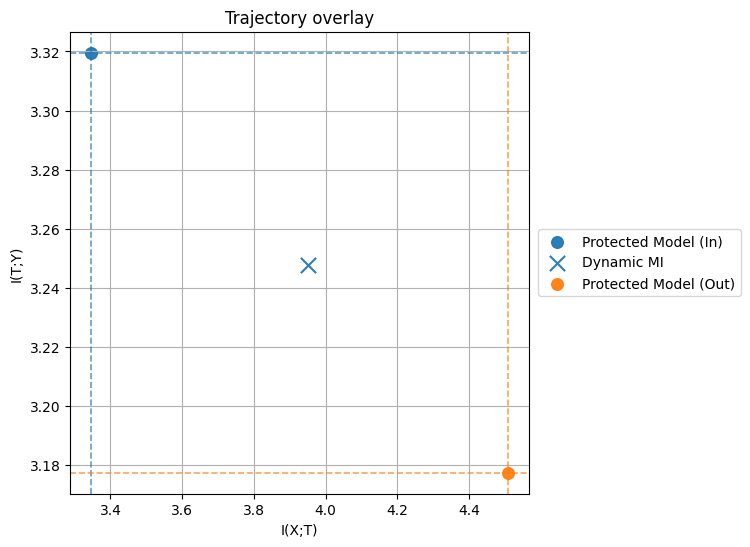

In [93]:
dyn = MemorySpec(
    label="Dynamic MI",
    points=(value_xt_in, value_ty_in),
    style={"marker": "x", "s": 120, "alpha": 0.95},
)

target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)
plot_information_plane([target18_in_group, dyn, target18_out_group], title="Trajectory overlay")

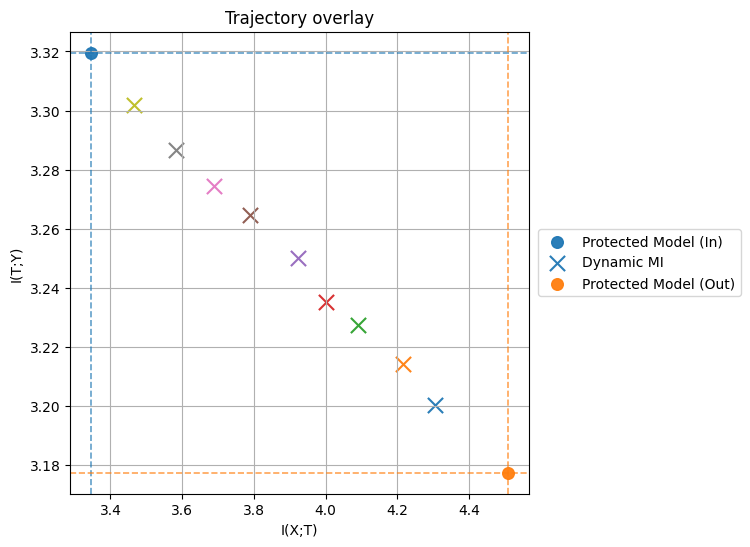

In [96]:
dyn = MemorySpec(
    label="Dynamic MI",
    points=frac_ls,
    style={"marker": "x", "s": 120, "alpha": 0.95},
)

target18_in_group = GroupSpec(
    label="Protected Model (In)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
    ref_line=True,                  # <-- just this
    ref_line_style={"color":"tab:blue"},
)

target18_out_group = GroupSpec(
    label="Protected Model (Out)",
    csv_paths=["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"],
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.95},
    mode="single",
    select_fn=select_last,
    ref_line=True,
    ref_line_style={"color":"tab:orange"},
)
plot_information_plane([target18_in_group, dyn, target18_out_group], title="Trajectory overlay")

In [97]:
import numpy as np
from typing import Sequence, Tuple, Optional

def add_class_balanced_from_A_to_full_B(
    dataset,
    group_A_indices: Sequence[int],
    group_B_indices: Sequence[int],
    num_classes: int = 10,
    add_size_from_A: Optional[int] = None,     # how many extra samples to add from A
    frac_from_A: Optional[float] = None,       # alternative: add_size_from_A = round(frac * len(B))
    seed: int = 42,
    replace: bool = False,
    shuffle: bool = True,
    return_parts: bool = False,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Variant B:
      mixed = (ALL of group_B) + (balanced subset from group_A of size add_size_from_A)

    Returns:
      mixed_idx, picked_A, full_B
    """
    rng = np.random.default_rng(seed)

    A = np.array(list(group_A_indices), dtype=int)
    B = np.array(list(group_B_indices), dtype=int)

    B_total = len(B)
    if frac_from_A is not None:
        add_size_from_A = int(round(frac_from_A * B_total))

    if add_size_from_A is None:
        raise ValueError("Provide add_size_from_A or frac_from_A.")

    # ensure divisibility for exact class balance
    add_size_from_A = int(add_size_from_A)
    add_size_from_A = (add_size_from_A // num_classes) * num_classes  # floor to multiple of C
    if add_size_from_A <= 0:
        mixed = B.copy()
        if shuffle:
            rng.shuffle(mixed)
        return (mixed, np.array([], dtype=int), B.copy()) if return_parts else (mixed,)

    a_per_class = add_size_from_A // num_classes

    # organize A by class
    A_by_class = {c: [] for c in range(num_classes)}
    for idx in A:
        _, y = dataset[int(idx)]
        A_by_class[int(y)].append(int(idx))

    picked_A = []
    for c in range(num_classes):
        A_c = np.array(A_by_class[c], dtype=int)
        if not replace and a_per_class > len(A_c):
            raise ValueError(f"Class {c}: need {a_per_class} from A, only {len(A_c)} available.")
        if a_per_class > 0:
            picked_A.append(rng.choice(A_c, size=a_per_class, replace=replace))

    picked_A = np.concatenate(picked_A) if picked_A else np.array([], dtype=int)

    mixed = np.concatenate([B, picked_A])
    if shuffle:
        rng.shuffle(mixed)

    if return_parts:
        return mixed, picked_A, B
    return mixed


In [ ]:
frac_ls_B = []          # store MI results
mix_sizes_B = []        # store dataset sizes used

B_total = len(group_B)

for frac in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
    mix_idx, add_A, full_B = add_class_balanced_from_A_to_full_B(
        dataset=in_sample_set,
        group_A_indices=group_A,
        group_B_indices=group_B,
        num_classes=10,
        frac_from_A=frac,     # add round(frac*|B|) from A
        seed=42,
        return_parts=True,
        shuffle=True
    )

    in_sample_subset = exp_setup["Dataset"].subset("train", mix_idx, clean=True)
    in_sample_loader = DataLoader(
        in_sample_subset,
        batch_size=128,
        shuffle=False,
        num_workers=8,
        worker_init_fn=seed_worker,
        generator=g,
        persistent_workers=True,
        pin_memory=True
    )

    value_xt_in, value_ty_in = evaluate2(net, in_sample_loader, device)
    frac_ls_B.append((value_xt_in, value_ty_in))
    mix_sizes_B.append(len(mix_idx))

    print(f"[Variant B] frac={frac:.1f} | add_A={len(add_A)} | total={len(mix_idx)}")


In [179]:
import numpy as np
from typing import Sequence, Optional, Tuple, Union, List, Dict, Literal

Split = Literal["train", "test"]
TaggedIndex = Tuple[Split, int]

def create_class_balanced_mix_train_test(
    train_dataset,
    test_dataset,
    train_in_indices: Sequence[int],            # e.g., group_A indices into train_dataset
    num_classes: int = 10,
    total_size: Optional[int] = None,           # total mixed size (divisible by num_classes)
    per_class: Optional[int] = None,            # samples per class in final mixed set
    frac_in_from_train: Optional[float] = None, # fraction per class coming from train_in_indices
    per_class_from_train: Optional[int] = None, # exact count per class from train
    seed: int = 42,
    replace: bool = False,
    shuffle: bool = True,
    return_parts: bool = False,
    test_out_indices: Optional[Sequence[int]] = None,  # optionally restrict test pool
) -> Union[
    List[TaggedIndex],
    Tuple[List[TaggedIndex], List[TaggedIndex], List[TaggedIndex]]
]:
    """
    Build a class-balanced mixed set where:
      - "in" samples come from train_dataset using train_in_indices (e.g., group_A)
      - "out" samples come from test_dataset (default: all test indices, or test_out_indices if provided)

    Returns:
      mixed: List[(split, idx)] where split in {"train","test"} and idx is index into that dataset.
      Optionally also returns (picked_train, picked_test).
    """
    rng = np.random.default_rng(seed)

    train_in = np.asarray(list(train_in_indices), dtype=int)
    test_pool = np.arange(len(test_dataset), dtype=int) if test_out_indices is None \
                else np.asarray(list(test_out_indices), dtype=int)

    # ---- determine per_class ----
    if per_class is None:
        if total_size is None:
            raise ValueError("Provide either total_size or per_class.")
        if total_size % num_classes != 0:
            raise ValueError(f"total_size={total_size} must be divisible by num_classes={num_classes}.")
        per_class = total_size // num_classes
    else:
        per_class = int(per_class)

    # ---- determine per_class_from_train ----
    if per_class_from_train is None:
        if frac_in_from_train is None:
            raise ValueError("Provide either frac_in_from_train or per_class_from_train.")
        if not (0.0 <= frac_in_from_train <= 1.0):
            raise ValueError("frac_in_from_train must be in [0, 1].")
        per_class_from_train = int(round(per_class * frac_in_from_train))
    else:
        per_class_from_train = int(per_class_from_train)

    per_class_from_test = per_class - per_class_from_train
    if per_class_from_test < 0:
        raise ValueError("per_class_from_train cannot exceed per_class.")

    # ---- build pools by class from TRAIN and TEST ----
    train_by_class: Dict[int, List[int]] = {c: [] for c in range(num_classes)}
    for idx in train_in:
        _, y = train_dataset[int(idx)]
        train_by_class[int(y)].append(int(idx))

    test_by_class: Dict[int, List[int]] = {c: [] for c in range(num_classes)}
    for idx in test_pool:
        _, y = test_dataset[int(idx)]
        test_by_class[int(y)].append(int(idx))

    picked_train: List[TaggedIndex] = []
    picked_test: List[TaggedIndex] = []

    # ---- sample per class ----
    for c in range(num_classes):
        Tr_c = np.asarray(train_by_class[c], dtype=int)
        Te_c = np.asarray(test_by_class[c], dtype=int)

        if not replace:
            if per_class_from_train > len(Tr_c):
                raise ValueError(f"Class {c}: need {per_class_from_train} from TRAIN, only {len(Tr_c)} available.")
            if per_class_from_test > len(Te_c):
                raise ValueError(f"Class {c}: need {per_class_from_test} from TEST, only {len(Te_c)} available.")

        if per_class_from_train > 0:
            chosen = rng.choice(Tr_c, size=per_class_from_train, replace=replace)
            picked_train.extend([("train", int(i)) for i in chosen])

        if per_class_from_test > 0:
            chosen = rng.choice(Te_c, size=per_class_from_test, replace=replace)
            picked_test.extend([("test", int(i)) for i in chosen])

    mixed = picked_train + picked_test
    if shuffle:
        rng.shuffle(mixed)

    if return_parts:
        return mixed, picked_train, picked_test
    return mixed


In [182]:
mixed, picked_train, picked_test = create_class_balanced_mix_train_test(
    train_dataset=in_sample_set,
    test_dataset=out_sample_set,
    train_in_indices=group_A,
    num_classes=10,
    total_size=10000,
    frac_in_from_train=0.5,
    seed=42,
    return_parts=True,
)


In [186]:
import torch
from torch.utils.data import Dataset
from typing import List, Tuple, Literal, Optional

Split = Literal["train", "test"]
TaggedIndex = Tuple[Split, int]

class MixedSplitDataset(Dataset):
    def __init__(
        self,
        train_dataset,
        test_dataset,
        tagged_indices: List[TaggedIndex],
        return_split: bool = False,   # if True, returns (x,y,split_id)
        split_ids: Tuple[int, int] = (0, 1),  # (train_id, test_id)
    ):
        self.train_dataset = train_dataset
        self.test_dataset = test_dataset
        self.tagged_indices = tagged_indices
        self.return_split = return_split
        self.train_id, self.test_id = split_ids

    def __len__(self):
        return len(self.tagged_indices)

    def __getitem__(self, i: int):
        split, idx = self.tagged_indices[i]
        if split == "train":
            x, y = self.train_dataset[idx]
            if self.return_split:
                return x, y, self.train_id
            return x, y
        elif split == "test":
            x, y = self.test_dataset[idx]
            if self.return_split:
                return x, y, self.test_id
            return x, y
        else:
            raise ValueError(f"Unknown split tag: {split}")


In [193]:
# mixed is your list of ("train"/"test", idx)
import numpy as np
from collections import Counter
from typing import List, Tuple, Literal, Dict, Any, Optional

Split = Literal["train", "test"]
TaggedIndex = Tuple[Split, int]

def check_mixed_tagged_indices(
    train_dataset,
    test_dataset,
    tagged_indices: List[TaggedIndex],
    num_classes: Optional[int] = None,
    train_allowed_indices: Optional[np.ndarray] = None,  # e.g., group_A_indices (train)
    test_allowed_indices: Optional[np.ndarray] = None,   # e.g., np.arange(len(test)) or a restricted pool
    verbose: bool = True,
) -> Dict[str, Any]:
    """
    Light checker for a mixed tagged-index list like [("train", i), ("test", j), ...].

    Verifies:
      1) All tags are valid and indices are in range.
      2) Optional membership: train indices are subset of train_allowed_indices; same for test.
      3) Class distribution overall, and per-split.
      4) Basic balance diagnostics (min/max per-class counts).
      5) Duplicate rate (helpful if replace=True was used upstream).

    Returns a dict summary you can log/print.
    """
    if num_classes is not None:
        num_classes = int(num_classes)

    n = len(tagged_indices)
    if n == 0:
        raise ValueError("tagged_indices is empty.")

    # --- allowed sets for fast membership checking ---
    train_allowed_set = set(map(int, train_allowed_indices)) if train_allowed_indices is not None else None
    test_allowed_set  = set(map(int, test_allowed_indices))  if test_allowed_indices is not None else None

    # --- counters ---
    total_by_split = Counter()
    bad_tag = 0
    out_of_range = 0
    bad_membership_train = 0
    bad_membership_test = 0

    # label counts
    overall_labels = Counter()
    train_labels = Counter()
    test_labels = Counter()

    # duplicates (tagged)
    dup_count = n - len(set(tagged_indices))

    # --- scan ---
    for split, idx in tagged_indices:
        if split not in ("train", "test"):
            bad_tag += 1
            continue

        idx = int(idx)
        total_by_split[split] += 1

        # range checks + label extraction
        if split == "train":
            if idx < 0 or idx >= len(train_dataset):
                out_of_range += 1
                continue
            if train_allowed_set is not None and idx not in train_allowed_set:
                bad_membership_train += 1

            _, y = train_dataset[idx]
            y = int(y)
            overall_labels[y] += 1
            train_labels[y] += 1

        else:  # test
            if idx < 0 or idx >= len(test_dataset):
                out_of_range += 1
                continue
            if test_allowed_set is not None and idx not in test_allowed_set:
                bad_membership_test += 1

            _, y = test_dataset[idx]
            y = int(y)
            overall_labels[y] += 1
            test_labels[y] += 1

    # --- class balance diagnostics ---
    def _balance_stats(label_counter: Counter) -> Dict[str, Any]:
        if len(label_counter) == 0:
            return {"min": 0, "max": 0, "missing_classes": None, "counts": {}}

        # If num_classes provided, include missing classes explicitly
        if num_classes is not None:
            counts = {c: int(label_counter.get(c, 0)) for c in range(num_classes)}
            missing = [c for c in range(num_classes) if counts[c] == 0]
            vals = list(counts.values())
        else:
            counts = {int(k): int(v) for k, v in sorted(label_counter.items())}
            missing = None
            vals = list(counts.values())

        return {
            "min": int(min(vals)) if vals else 0,
            "max": int(max(vals)) if vals else 0,
            "missing_classes": missing,
            "counts": counts,
        }

    overall_stats = _balance_stats(overall_labels)
    train_stats = _balance_stats(train_labels)
    test_stats = _balance_stats(test_labels)

    # balance heuristic: "well-balanced" if max-min <= 1 (typical when you enforce exact per-class)
    def _is_well_balanced(stats: Dict[str, Any]) -> bool:
        return (stats["max"] - stats["min"]) <= 1 and (stats["missing_classes"] is None or len(stats["missing_classes"]) == 0)

    summary = {
        "N_total": n,
        "split_counts": dict(total_by_split),
        "errors": {
            "bad_tag": bad_tag,
            "out_of_range": out_of_range,
            "bad_membership_train": bad_membership_train,
            "bad_membership_test": bad_membership_test,
        },
        "duplicates": {
            "num_duplicates": dup_count,
            "duplicate_rate": (dup_count / n) if n else 0.0,
        },
        "overall": {
            **overall_stats,
            "well_balanced": _is_well_balanced(overall_stats),
        },
        "train_part": {
            **train_stats,
            "well_balanced": _is_well_balanced(train_stats),
        },
        "test_part": {
            **test_stats,
            "well_balanced": _is_well_balanced(test_stats),
        },
    }

    if verbose:
        print("==== Mixed Dataset Check ====")
        print(f"N_total: {summary['N_total']}")
        print(f"Split counts: {summary['split_counts']}")
        print("Errors:", summary["errors"])
        print(f"Duplicates: {summary['duplicates']['num_duplicates']} "
              f"({summary['duplicates']['duplicate_rate']:.2%})")
        print("\n-- Overall class balance --")
        print(f"min={summary['overall']['min']} max={summary['overall']['max']} "
              f"well_balanced={summary['overall']['well_balanced']}")
        if summary["overall"]["missing_classes"] is not None and len(summary["overall"]["missing_classes"]) > 0:
            print("missing_classes:", summary["overall"]["missing_classes"])

        print("\n-- Train part class balance --")
        print(f"min={summary['train_part']['min']} max={summary['train_part']['max']} "
              f"well_balanced={summary['train_part']['well_balanced']}")
        if summary["train_part"]["missing_classes"] is not None and len(summary["train_part"]["missing_classes"]) > 0:
            print("missing_classes:", summary["train_part"]["missing_classes"])

        print("\n-- Test part class balance --")
        print(f"min={summary['test_part']['min']} max={summary['test_part']['max']} "
              f"well_balanced={summary['test_part']['well_balanced']}")
        if summary["test_part"]["missing_classes"] is not None and len(summary["test_part"]["missing_classes"]) > 0:
            print("missing_classes:", summary["test_part"]["missing_classes"])

    return summary



summary = check_mixed_tagged_indices(
    train_dataset=in_sample_set,
    test_dataset=out_sample_set,
    tagged_indices=mixed,
    num_classes=10,
    train_allowed_indices=np.array(group_A),        # enforce "train must come from group_A"
    test_allowed_indices=np.arange(len(out_sample_set)),          # or a restricted test pool if you used one
    verbose=True
)


==== Mixed Dataset Check ====
N_total: 10000
Split counts: {'train': 5000, 'test': 5000}
Errors: {'bad_tag': 0, 'out_of_range': 0, 'bad_membership_train': 0, 'bad_membership_test': 0}
Duplicates: 0 (0.00%)

-- Overall class balance --
min=1000 max=1000 well_balanced=True

-- Train part class balance --
min=500 max=500 well_balanced=True

-- Test part class balance --
min=500 max=500 well_balanced=True


In [194]:
# Accessing each csv MI points

def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}. Available: {list(df.columns)}")


def read_mi_points1(csv_path: str, domain: str, epoch_col: str = "Epoch") -> List[Point]:
    """
    Read all MI points from one CSV. Each row corresponds to one epoch.
    """
    df = pd.read_csv(csv_path)

    if domain == "in":
        ix_col = find_column(df, ["I(X;T)-In"])
        iy_col = find_column(df, ["I(T;Y)-In"])
    elif domain == "out":
        ix_col = find_column(df, ["I(X;T)-Out"])
        iy_col = find_column(df, ["I(T;Y)-Out"])
    else:
        raise ValueError("domain must be 'in' or 'out'")

    epochs = df[epoch_col].tolist() if epoch_col in df.columns else [None] * len(df)

    points: List[Point] = []
    for e, ix, iy in zip(epochs, df[ix_col], df[iy_col]):
        points.append({"path": csv_path, "epoch": e, "ix": float(ix), "iy": float(iy)})
    return points


In [199]:
sample_csv_path = ["./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_tagging_0.1_size_10000_MI.csv",
                   "./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_tagging_0.1_size_10000_MI.csv"]

for path in sample_csv_path:
    points = read_mi_points1(path, "in")
    print(points)

[{'path': './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_tagging_0.1_size_10000_MI.csv', 'epoch': 99, 'ix': 4.385152816772461, 'iy': 3.1958348751068115}]
[{'path': './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_tagging_0.1_size_10000_MI.csv', 'epoch': 99, 'ix': 4.385152816772461, 'iy': 3.1958348751068115}]


In [197]:
points

[{'path': './saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_tagging_0.1_size_10000_MI.csv',
  'epoch': 99,
  'ix': 4.385152816772461,
  'iy': 3.1958348751068115}]

In [343]:
overlapping_model_18 = [] # interior points in this tube
for frac in np.arange(0.05, 1.0, 0.05):
    round_frac = round(frac, 2)
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_tagging_{round_frac}_size_10000_MI.csv"
    overlapping_model_18.append(log_path)

same_model_18 = [] # endpoints in this tube
for seed in range(42, 52):
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_{seed}_1.0_MI.csv"
    same_model_18.append(log_path)

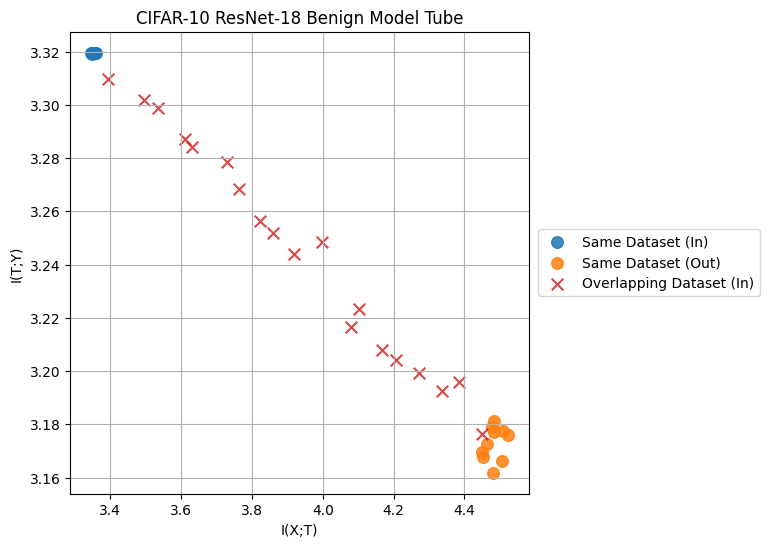

In [210]:
endpoints18_in_group = GroupSpec(
    label="Same Dataset (In)",
    csv_paths=same_model_18,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

endpoints18_out_group = GroupSpec(
    label="Same Dataset (Out)",
    csv_paths=same_model_18,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

overlapping18_in_group = GroupSpec(
    label="Overlapping Dataset (In)",
    csv_paths=overlapping_model_18,
    domain="in",
    style={"marker": "x", "color": "tab:red", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

plot_information_plane([endpoints18_in_group, endpoints18_out_group, overlapping18_in_group], title="CIFAR-10 ResNet-18 Benign Model Tube")

In [390]:
overlapping_model_deit = [] # interior points in this tube
for frac in np.arange(0.05, 1.0, 0.05):
    round_frac = round(frac, 2)
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-100_DeiT_40000_NoMixup_Hard_42_1.0_tagging_{round_frac}_size_10000_MI.csv"
    overlapping_model_deit.append(log_path)

same_model_deit = [] # endpoints in this tube
for seed in range(42, 43):
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-100_DeiT_40000_NoMixup_Hard_{seed}_1.0_MI.csv"
    same_model_deit.append(log_path)

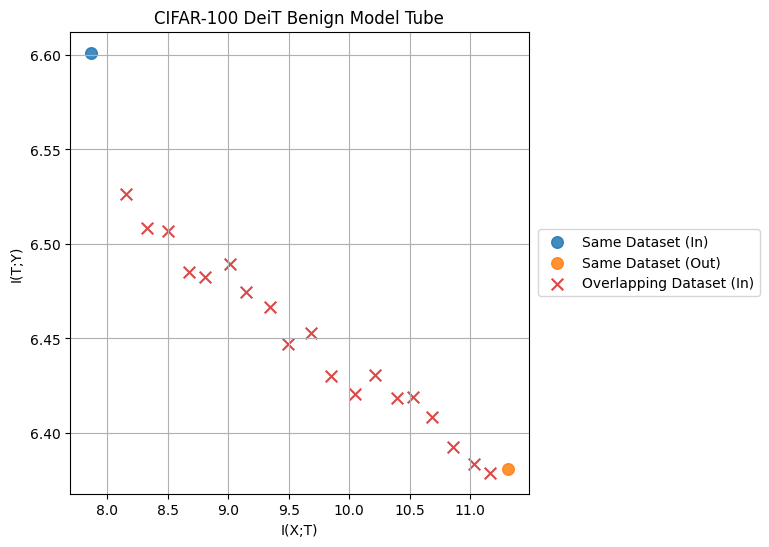

In [391]:
endpoints_in_group = GroupSpec(
    label="Same Dataset (In)",
    csv_paths=same_model_deit,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

endpoints_out_group = GroupSpec(
    label="Same Dataset (Out)",
    csv_paths=same_model_deit,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

overlapping_in_group = GroupSpec(
    label="Overlapping Dataset (In)",
    csv_paths=overlapping_model_deit,
    domain="in",
    style={"marker": "x", "color": "tab:red", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

plot_information_plane([endpoints_in_group, endpoints_out_group, overlapping_in_group], title="CIFAR-100 DeiT Benign Model Tube")

In [392]:
overlapping_model_deit = [] # interior points in this tube
for frac in np.arange(0.05, 1.0, 0.05):
    round_frac = round(frac, 2)
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-10_DeiT_40000_Mixup_Hard_42_1.0_tagging_{round_frac}_size_10000_MI.csv"
    overlapping_model_deit.append(log_path)

same_model_deit = [] # endpoints in this tube
for seed in range(42, 43):
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-10_DeiT_40000_Mixup_Hard_{seed}_1.0_MI.csv"
    same_model_deit.append(log_path)

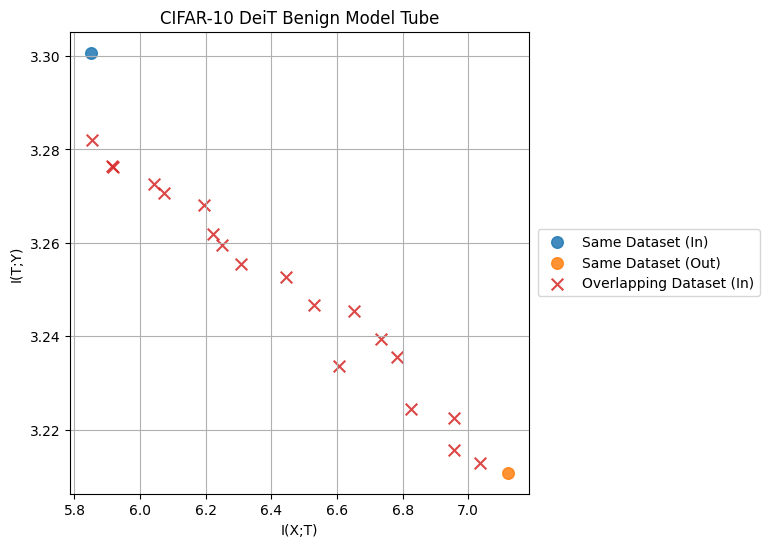

In [393]:
endpoints_in_group = GroupSpec(
    label="Same Dataset (In)",
    csv_paths=same_model_deit,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

endpoints_out_group = GroupSpec(
    label="Same Dataset (Out)",
    csv_paths=same_model_deit,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

overlapping_in_group = GroupSpec(
    label="Overlapping Dataset (In)",
    csv_paths=overlapping_model_deit,
    domain="in",
    style={"marker": "x", "color": "tab:red", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

plot_information_plane([endpoints_in_group, endpoints_out_group, overlapping_in_group], title="CIFAR-10 DeiT Benign Model Tube")

In [397]:
overlapping_model_deit = [] # interior points in this tube
for frac in np.arange(0.05, 1.0, 0.05):
    round_frac = round(frac, 2)
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-10_DeiT_40000_NoMixup_Hard_42_1.0_tagging_{round_frac}_size_10000_MI.csv"
    overlapping_model_deit.append(log_path)

same_model_deit = [] # endpoints in this tube
for seed in range(42, 43):
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-10_DeiT_40000_NoMixup_Hard_{seed}_1.0_MI.csv"
    same_model_deit.append(log_path)

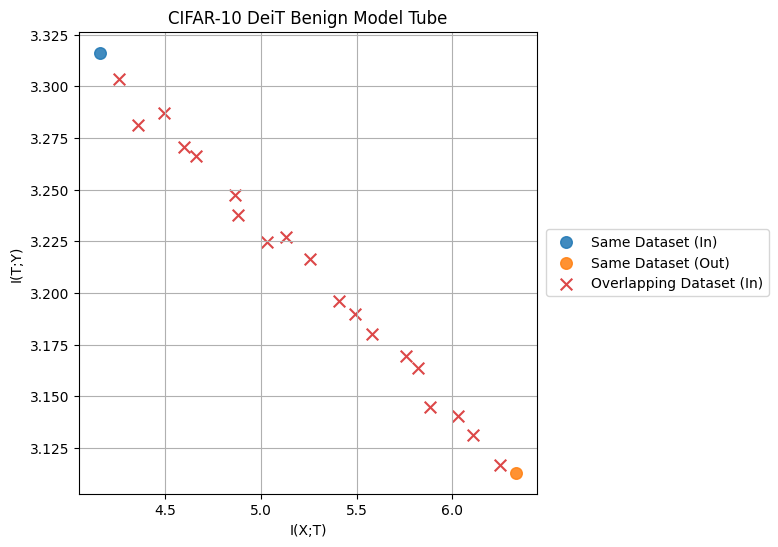

In [398]:
endpoints_in_group = GroupSpec(
    label="Same Dataset (In)",
    csv_paths=same_model_deit,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

endpoints_out_group = GroupSpec(
    label="Same Dataset (Out)",
    csv_paths=same_model_deit,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

overlapping_in_group = GroupSpec(
    label="Overlapping Dataset (In)",
    csv_paths=overlapping_model_deit,
    domain="in",
    style={"marker": "x", "color": "tab:red", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

plot_information_plane([endpoints_in_group, endpoints_out_group, overlapping_in_group], title="CIFAR-10 DeiT Benign Model Tube")

In [394]:
overlapping_model_deit = [] # interior points in this tube
for frac in np.arange(0.05, 1.0, 0.05):
    round_frac = round(frac, 2)
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-100_DeiT_40000_Mixup_Hard_42_1.0_tagging_{round_frac}_size_10000_MI.csv"
    overlapping_model_deit.append(log_path)

same_model_deit = [] # endpoints in this tube
for seed in range(42, 43):
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-100_DeiT_40000_Mixup_Hard_{seed}_1.0_MI.csv"
    same_model_deit.append(log_path)

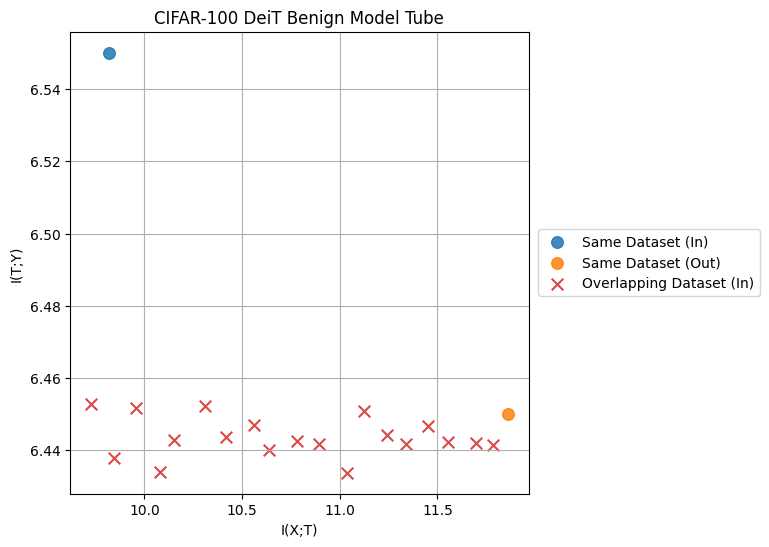

In [396]:
endpoints_in_group = GroupSpec(
    label="Same Dataset (In)",
    csv_paths=same_model_deit,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

endpoints_out_group = GroupSpec(
    label="Same Dataset (Out)",
    csv_paths=same_model_deit,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

overlapping_in_group = GroupSpec(
    label="Overlapping Dataset (In)",
    csv_paths=overlapping_model_deit,
    domain="in",
    style={"marker": "x", "color": "tab:red", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

plot_information_plane([endpoints_in_group, endpoints_out_group, overlapping_in_group], title="CIFAR-100 DeiT Benign Model Tube")

# Hypothesis Test ResNet-18 Case

In [321]:
def collecting_test_samples(benign_path_ls, held_out_size):
    benign_ls = []

    for path in benign_path_ls[0]:
        points = read_mi_points1(path, "in")
        benign_ls.append((points[0]['ix'], points[0]['iy']))

    for path in benign_path_ls[1]:
        points = read_mi_points1(path, "in")
        benign_ls.append((points[0]['ix'], points[0]['iy']))
    
    for path in benign_path_ls[1]:
        points = read_mi_points1(path, "out")
        benign_ls.append((points[0]['ix'], points[0]['iy']))

    series_custom = np.random.choice(len(benign_ls), size=held_out_size, replace=False)
    sorted_series = np.sort(series_custom)
    print(sorted_series)
    benign_arr = np.array(benign_ls, dtype=float)
    selected_samples = benign_arr[sorted_series]
    remaining_samples = np.delete(benign_arr, sorted_series, axis=0)

    return selected_samples, remaining_samples

def collecting_full_test_samples(benign_path_ls):
    benign_ls = []

    for path in benign_path_ls[0]:
        points = read_mi_points1(path, "in")
        benign_ls.append((points[0]['ix'], points[0]['iy']))

    for path in benign_path_ls[1]:
        points = read_mi_points1(path, "in")
        benign_ls.append((points[0]['ix'], points[0]['iy']))
    
    for path in benign_path_ls[1]:
        points = read_mi_points1(path, "out")
        benign_ls.append((points[0]['ix'], points[0]['iy']))

    return np.array(benign_ls, dtype=float)

In [305]:
# positive pairs
import glob
import os

# Replace this with the actual path shown in your file explorer image
folder_path = r'E:\Experiment\saved_logs\fine_tune_vanilla\MI'

# This grabs every file ending in .csv and puts the full path in a list
csv_paths = glob.glob(os.path.join(folder_path, "*CIFAR-10_*ResNet-18*.csv"))
print(csv_paths)
positive_18 = []
for path in csv_paths:
    points = read_mi_points1(path, "in")
    positive_18.append((points[-1]['ix'], points[-1]['iy'])) # only loading the last epoch here

positive_arr = np.array(positive_18, dtype=float)

['E:\\Experiment\\saved_logs\\fine_tune_vanilla\\MI\\training_log_CIFAR-10_ResNet-18_40000_PseudoLabel_10000_42_1.0_FT-AL_MI.csv', 'E:\\Experiment\\saved_logs\\fine_tune_vanilla\\MI\\training_log_CIFAR-10_ResNet-18_40000_PseudoLabel_10000_42_1.0_FT-LL_MI.csv', 'E:\\Experiment\\saved_logs\\fine_tune_vanilla\\MI\\training_log_CIFAR-10_ResNet-18_40000_Same_10000_42_1.0_FT-AL_MI.csv', 'E:\\Experiment\\saved_logs\\fine_tune_vanilla\\MI\\training_log_CIFAR-10_ResNet-18_40000_Same_10000_42_1.0_FT-LL_MI.csv']


In [424]:
import numpy as np
from scipy.stats import chi2

def hotelling_T2_raw_fit(aux_matrix, ddof=1):
    X = np.asarray(aux_matrix, dtype=float)
    k, p = X.shape
    mu = X.mean(axis=0)
    S = np.cov(X, rowvar=False, ddof=ddof)

    evals = np.linalg.eigvalsh(S)
    cond = float(evals.max() / max(evals.min(), 1e-12))

    info = {"mu": mu, "S": S, "eigvals": evals, "cond": cond, "k": k, "p": p}
    return mu, S, info

def hotelling_T2_raw_score(mu, S, x, k=None, scaling="none"):
    """
    scaling:
      - "none": T2 = md2
      - "paper": T2 = (k/(k+1)) * md2   (Eq.(6)-style single-sample correction)
      - "k": T2 = k * md2               (some codebases do this; not Eq.(6))
    """
    x = np.asarray(x, dtype=float).ravel()
    diff = x - mu

    Sinv = np.linalg.inv(S)
    md2 = float(diff @ Sinv @ diff)

    if scaling == "none":
        T2 = md2
    elif scaling == "paper":
        if k is None:
            raise ValueError("k must be provided for scaling='paper'")
        T2 = float((k / (k + 1.0)) * md2)
    elif scaling == "k":
        if k is None:
            raise ValueError("k must be provided for scaling='k'")
        T2 = float(k * md2)
    else:
        raise ValueError("scaling must be in {'none','paper','k'}")

    p_value = 1.0 - chi2.cdf(T2, df=len(mu))
    return T2, p_value, {"diff": diff, "md2": md2, "scaling": scaling}

def decisions_from_p(p_value, alphas=(0.10, 0.05, 0.01, 0.001)):
    """
    Reject H0 if p < alpha.
    Returns dict: {alpha: True/False}
    """
    return {a: (p_value < a) for a in alphas}

def evaluate_group(name, samples, mu, S, alphas=(0.10, 0.05, 0.01, 0.001), verbose=False, k=None, scaling="none"):
    """
    samples: iterable of 2D points like (ix,iy) or array-like shape (2,)
    Returns per-sample records and a structured summary of rejection rates.
    """
    records = []
    for idx, x in enumerate(samples):
        T2, pval, extra = hotelling_T2_raw_score(mu, S, x, k, scaling)
        dec = decisions_from_p(pval, alphas=alphas)
        rec = {"group": name, "idx": idx, "x": np.asarray(x, float), "T2": T2, "p": pval, **dec}
        records.append(rec)
        if verbose:
            print(f"[{name} #{idx}] x={rec['x']}  T2={T2:.6f}  p={pval:.6g}  " +
                  " ".join([f"a={a}:{'REJ' if rec[a] else 'OK'}" for a in alphas]))

    n = len(records)
    
    # Store counts and rates in dictionaries with the alpha floats as keys
    counts = {}
    rates = {}
    
    for a in alphas:
        rej = sum(1 for r in records if r[a])
        counts[a] = rej
        rates[a] = rej / max(n, 1)

    # Structured summary
    summary = {
        "group": name, 
        "n": n,
        "counts": counts, 
        "rates": rates
    }

    return records, summary



# Sanity Check

In [326]:
import numpy as np
from scipy.stats import chi2

def sanity_check_chi2(
    M,                    # array shape (N, p): MI vectors for many known-independent models
    k=20,
    R=2000,
    ddof=1,
    scaling="paper",
    alphas=(0.10, 0.05, 0.01),
    shrinkage=None,       # e.g. 0.05 or None
    seed=0,
):
    M = np.asarray(M, float)
    N, p = M.shape
    rng = np.random.default_rng(seed)

    T2s = np.empty(R, dtype=float)

    for r in range(R):
        # pick k auxiliaries and 1 disjoint null target
        idx = rng.choice(N, size=k+1, replace=False)
        aux_idx = idx[:k]
        tgt_idx = idx[k]

        mu, S, info = hotelling_T2_raw_fit(M[aux_idx], ddof=ddof)

        if shrinkage is not None:
            lam = float(shrinkage)
            S = (1.0 - lam) * S + lam * (np.trace(S) / p) * np.eye(p)

        # compute T2 for the null target
        T2, _, _ = hotelling_T2_raw_score(mu, S, M[tgt_idx], k=k, scaling=scaling)
        T2s[r] = T2

    # tail calibration against chi2_p
    out = {"k": k, "R": R, "p": p, "mean_T2": float(T2s.mean()), "var_T2": float(T2s.var(ddof=1))}
    for a in alphas:
        crit = chi2.ppf(1.0 - a, df=p)
        out[f"crit@{a}"] = float(crit)
        out[f"tail_rate@{a}"] = float((T2s > crit).mean())  # should be ~ a
        out[f"tail_err@{a}"] = out[f"tail_rate@{a}"] - a

    return T2s, out

In [328]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

def qq_plot_chi2_envelope(
    T2s, df=2, title="QQ plot: T2 vs chi-square",
    add_fit=True, envelope_B=200, envelope_alpha=0.05,
    show=True, ax=None, seed=0
):
    T2s = np.asarray(T2s, float)
    T2s = T2s[np.isfinite(T2s)]
    T2s = np.sort(T2s)
    n = len(T2s)
    if n < 20:
        # envelope is not very meaningful with tiny n
        envelope_B = 0

    probs = (np.arange(1, n + 1) - 0.5) / n
    theo = chi2.ppf(probs, df=df)

    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    ax.plot(theo, T2s, marker='o', linestyle='none', label="Empirical")

    # 45-degree reference
    lo = float(min(theo.min(), T2s.min()))
    hi = float(max(theo.max(), T2s.max()))
    ax.plot([lo, hi], [lo, hi], label="y=x")

    # Optional fitted line
    fit_info = None
    if add_fit:
        b, a = np.polyfit(theo, T2s, deg=1)  # T2 ≈ a + b*theo
        ax.plot([lo, hi], [a + b*lo, a + b*hi], label=f"Fit: y={a:.3g}+{b:.3g}x")
        fit_info = {"intercept": float(a), "slope": float(b)}

    # Optional envelope under chi2
    if envelope_B and envelope_B > 0:
        rng = np.random.default_rng(seed)
        sims = rng.chisquare(df=df, size=(envelope_B, n))
        sims.sort(axis=1)
        lower = np.quantile(sims, envelope_alpha/2, axis=0)
        upper = np.quantile(sims, 1-envelope_alpha/2, axis=0)
        ax.fill_between(theo, lower, upper, alpha=0.2, label=f"{int((1-envelope_alpha)*100)}% envelope")

    ax.set_xlabel(f"Theoretical quantiles: χ²(df={df})")
    ax.set_ylabel("Empirical quantiles: T²")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

    if show:
        plt.show()

    return fig, ax, fit_info

In [342]:
import numpy as np

def cov_inverse_quality(S, *, rcond_rank=1e-12, eps_eig=1e-12, residual_trials=8, seed=0):
    """
    Diagnose whether covariance matrix S is safe to invert for Mahalanobis / Hotelling T^2.

    Returns a dict with:
      - eigvals, min/max eig, cond
      - rank estimate
      - is_symmetric, is_pd (Cholesky)
      - logdet (if PD) and det sign
      - inverse_residual: ||I - S @ invS||_F / ||I||_F
      - solve_residual:   ||I - S @ solve(S, I)||_F / ||I||_F
      - directional_gain_max: max_x (x^T S^{-1} x)/(x^T x) over random x (approx)
      - flags: list of warnings
    """
    S = np.asarray(S, dtype=float)
    p, q = S.shape
    assert p == q, "S must be square."

    info = {"p": p}
    flags = []

    # Symmetry check (cov should be symmetric; numeric noise is ok)
    sym_err = float(np.linalg.norm(S - S.T, ord='fro') / (np.linalg.norm(S, ord='fro') + 1e-30))
    is_sym = sym_err < 1e-10
    info["sym_err_rel_fro"] = sym_err
    info["is_symmetric"] = is_sym
    if not is_sym:
        flags.append(f"not_symmetric(rel_fro={sym_err:.2e})")

    # Use symmetrized version for eig/Cholesky (stabilizes tiny asymmetry)
    Ssym = 0.5 * (S + S.T)

    # Eigen spectrum (robust for symmetric matrices)
    eigvals = np.linalg.eigvalsh(Ssym)
    eig_min = float(eigvals.min())
    eig_max = float(eigvals.max())
    info["eigvals"] = eigvals
    info["eig_min"] = eig_min
    info["eig_max"] = eig_max

    # Condition number (avoid divide by 0)
    denom = max(abs(eig_min), eps_eig)
    cond = float(abs(eig_max) / denom)
    info["cond_eig"] = cond

    # Rank estimate (based on relative threshold)
    tol = max(eig_max, 1.0) * rcond_rank
    rank = int(np.sum(eigvals > tol))
    info["rank_est"] = rank
    info["rank_tol"] = float(tol)
    if rank < p:
        flags.append(f"rank_deficient(rank={rank}/{p}, tol={tol:.2e})")

    # Positive-definite check via Cholesky
    try:
        np.linalg.cholesky(Ssym)
        is_pd = True
    except np.linalg.LinAlgError:
        is_pd = False
        flags.append("not_positive_definite(cholesky_fail)")
    info["is_pd"] = is_pd

    # logdet if PD (more stable than det)
    if is_pd:
        sign, logdet = np.linalg.slogdet(Ssym)
        info["det_sign"] = float(sign)
        info["logdet"] = float(logdet)
        if sign <= 0:
            flags.append("slogdet_sign_nonpositive")  # rare if PD check passed
    else:
        sign, logdet = np.linalg.slogdet(Ssym)
        info["det_sign"] = float(sign)
        info["logdet"] = float(logdet)

    # Inverse/solve residuals: how close to identity do we get?
    I = np.eye(p)
    # solve is preferred; inv may fail if singular
    try:
        Sinv = np.linalg.inv(Ssym)
        inv_resid = float(np.linalg.norm(I - Ssym @ Sinv, ord='fro') / (np.linalg.norm(I, ord='fro') + 1e-30))
    except np.linalg.LinAlgError:
        Sinv = None
        inv_resid = np.inf
        flags.append("inv_failed")
    info["inverse_residual_rel_fro"] = inv_resid

    try:
        X = np.linalg.solve(Ssym, I)  # equals inv(S) if solvable, but more stable
        solve_resid = float(np.linalg.norm(I - Ssym @ X, ord='fro') / (np.linalg.norm(I, ord='fro') + 1e-30))
    except np.linalg.LinAlgError:
        X = None
        solve_resid = np.inf
        flags.append("solve_failed")
    info["solve_residual_rel_fro"] = solve_resid

    # Directional gain: large values mean S^{-1} amplifies noise massively along some direction
    # For symmetric PD, max gain = largest eigenvalue of S^{-1} = 1/min_eig.
    # We approximate it even if not PD via random probes.
    rng = np.random.default_rng(seed)
    gains = []
    if X is not None:
        # X is S^{-1}
        for _ in range(residual_trials):
            v = rng.normal(size=p)
            v /= (np.linalg.norm(v) + 1e-30)
            gains.append(float(v @ X @ v))  # v^T S^{-1} v
    info["directional_gain_max_approx"] = float(np.max(gains)) if gains else np.inf
    info["directional_gain_median_approx"] = float(np.median(gains)) if gains else np.inf

    # Heuristic warnings
    if eig_min <= 0:
        flags.append(f"nonpositive_min_eig({eig_min:.2e})")
    if cond > 1e6:
        flags.append(f"ill_conditioned(cond={cond:.2e})")
    if inv_resid > 1e-6 and np.isfinite(inv_resid):
        flags.append(f"inv_residual_large({inv_resid:.2e})")
    if solve_resid > 1e-6 and np.isfinite(solve_resid):
        flags.append(f"solve_residual_large({solve_resid:.2e})")

    info["flags"] = flags
    return info

In [344]:
benign_path_ls = [overlapping_model_18, same_model_18]

aux_matrix = collecting_full_test_samples(benign_path_ls)

T2s, report = sanity_check_chi2(aux_matrix, k=20, R=5000, shrinkage=None, seed=42)
print(report)

{'k': 20, 'R': 5000, 'p': 2, 'mean_T2': 2.2356630410521023, 'var_T2': 4.827574009496041, 'crit@0.1': 4.605170185988092, 'tail_rate@0.1': 0.117, 'tail_err@0.1': 0.017, 'crit@0.05': 5.991464547107979, 'tail_rate@0.05': 0.0638, 'tail_err@0.05': 0.013799999999999993, 'crit@0.01': 9.21034037197618, 'tail_rate@0.01': 0.0186, 'tail_err@0.01': 0.008599999999999998}


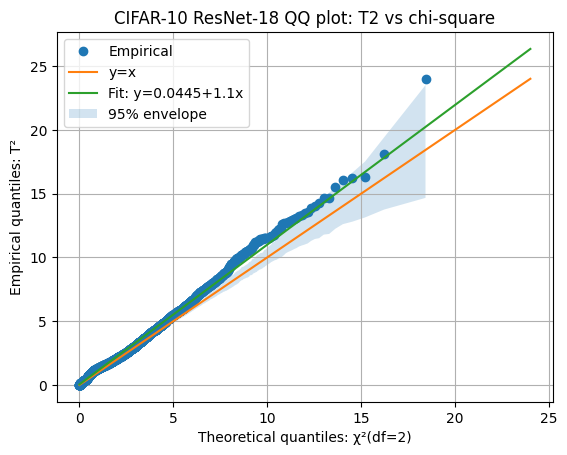

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'CIFAR-10 ResNet-18 QQ plot: T2 vs chi-square'}, xlabel='Theoretical quantiles: χ²(df=2)', ylabel='Empirical quantiles: T²'>,
 {'intercept': 0.04449982301915732, 'slope': 1.0956575523847059})

In [345]:
qq_plot_chi2_envelope(T2s, df=2, title="CIFAR-10 ResNet-18 QQ plot: T2 vs chi-square")

In [346]:
mu, S, fit_info = hotelling_T2_raw_fit(aux_matrix, ddof=1)

q = cov_inverse_quality(S)
print("cond:", q["cond_eig"], "min_eig:", q["eig_min"], "rank:", q["rank_est"], "flags:", q["flags"])

cond: 8150.097903393195 min_eig: 2.712303362976346e-05 rank: 2 flags: []


In [306]:
alphas = (0.10, 0.05, 0.01, 0.001)
held_out_size = 10
benign_path_ls = [overlapping_model_18, same_model_18]

for i in range(10):
    print(f"The {i} time sampling run:")
    neg_pairs, aux_matrix = collecting_test_samples(benign_path_ls, held_out_size)
    mu, S, fit_info = hotelling_T2_raw_fit(aux_matrix, ddof=1)
    print("FIT:", fit_info)
    
    neg_records, neg_summary = evaluate_group("NEG(benign-heldout)", neg_pairs, mu, S, alphas=alphas, verbose=True,
                                             k=29, scaling="paper")
    print("NEG SUMMARY:", neg_summary)
    
    pos_records, pos_summary = evaluate_group("POS(suspect)", positive_arr, mu, S, alphas=alphas, verbose=True,
                                             k=29, scaling="paper")
    print("POS SUMMARY:", pos_summary)

The 0 time sampling run:
[ 0  2  5 11 13 14 24 25 26 32]
FIT: {'mu': array([3.94483449, 3.24304661]), 'S': array([[ 0.22452992, -0.0289126 ],
       [-0.0289126 ,  0.00375603]]), 'eigvals': array([3.24308955e-05, 2.28253522e-01]), 'cond': 7038.15044183679, 'k': 29, 'p': 2}
[NEG(benign-heldout) #0] x=[4.44924974 3.1762104 ]  T2=1.199369  p=0.548985  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #1] x=[4.33650208 3.19253302]  T2=0.660629  p=0.718698  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #2] x=[4.16744328 3.20787716]  T2=1.453763  p=0.483414  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #3] x=[3.82328224 3.25647044]  T2=0.209209  p=0.900681  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #4] x=[3.73031139 3.27834439]  T2=1.924725  p=0.381989  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #5] x=[3.63142633 3.28415775]  T2=0.439544  p=0.802702  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #6]

# Hypothesis Test VGG16 Case

In [330]:
overlapping_model_16 = [] # interior points in this tube
for frac in np.arange(0.05, 1.0, 0.05):
    round_frac = round(frac, 2)
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_tagging_{round_frac}_size_10000_MI.csv"
    overlapping_model_16.append(log_path)

same_model_16 = [] # endpoints in this tube
for seed in range(42, 52):
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_{seed}_1.0_MI.csv"
    same_model_16.append(log_path)

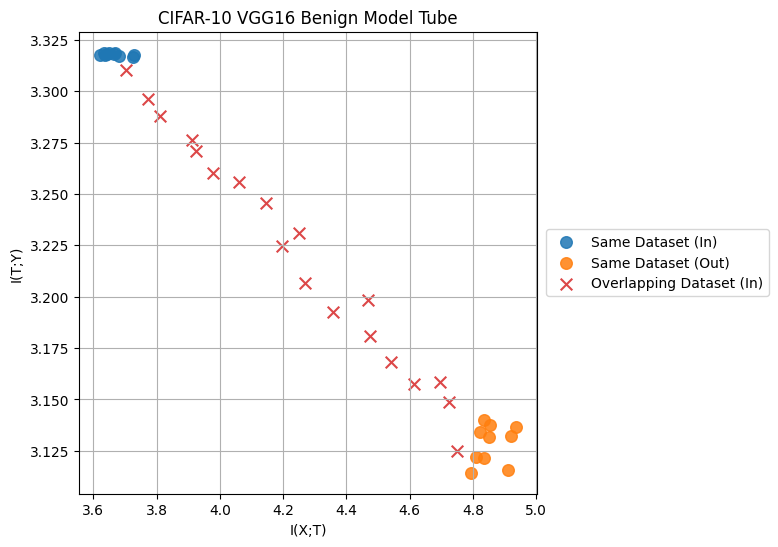

In [212]:
endpoints16_in_group = GroupSpec(
    label="Same Dataset (In)",
    csv_paths=same_model_16,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

endpoints16_out_group = GroupSpec(
    label="Same Dataset (Out)",
    csv_paths=same_model_16,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

overlapping16_in_group = GroupSpec(
    label="Overlapping Dataset (In)",
    csv_paths=overlapping_model_16,
    domain="in",
    style={"marker": "x", "color": "tab:red", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

plot_information_plane([endpoints16_in_group, endpoints16_out_group, overlapping16_in_group], title="CIFAR-10 VGG16 Benign Model Tube")

# Hypothesis Test for CIFAR-10 VGG16

In [297]:
# positive pairs
import glob
import os

# Replace this with the actual path shown in your file explorer image
folder_path = r'E:\Experiment\saved_logs\fine_tune_vanilla\MI'

# This grabs every file ending in .csv and puts the full path in a list
csv_paths = glob.glob(os.path.join(folder_path, "*CIFAR-10_*VGG16*.csv"))
print(csv_paths)
positive_16 = []
for path in csv_paths:
    points = read_mi_points1(path, "in")
    positive_16.append((points[-1]['ix'], points[-1]['iy'])) # only loading the last epoch here

positive_arr = np.array(positive_16, dtype=float)

['E:\\Experiment\\saved_logs\\fine_tune_vanilla\\MI\\training_log_CIFAR-10_VGG16_40000_PseudoLabel_10000_42_1.0_FT-AL_MI.csv', 'E:\\Experiment\\saved_logs\\fine_tune_vanilla\\MI\\training_log_CIFAR-10_VGG16_40000_PseudoLabel_10000_42_1.0_FT-LL_MI.csv', 'E:\\Experiment\\saved_logs\\fine_tune_vanilla\\MI\\training_log_CIFAR-10_VGG16_40000_Same_10000_42_1.0_FT-AL_MI.csv', 'E:\\Experiment\\saved_logs\\fine_tune_vanilla\\MI\\training_log_CIFAR-10_VGG16_40000_Same_10000_42_1.0_FT-LL_MI.csv']


# Sanity check

{'k': 20, 'R': 5000, 'p': 2, 'mean_T2': 2.342129191924892, 'var_T2': 6.490232601978705, 'crit@0.1': 4.605170185988092, 'tail_rate@0.1': 0.1102, 'tail_err@0.1': 0.0102, 'crit@0.05': 5.991464547107979, 'tail_rate@0.05': 0.0786, 'tail_err@0.05': 0.0286, 'crit@0.01': 9.21034037197618, 'tail_rate@0.01': 0.0354, 'tail_err@0.01': 0.0254}


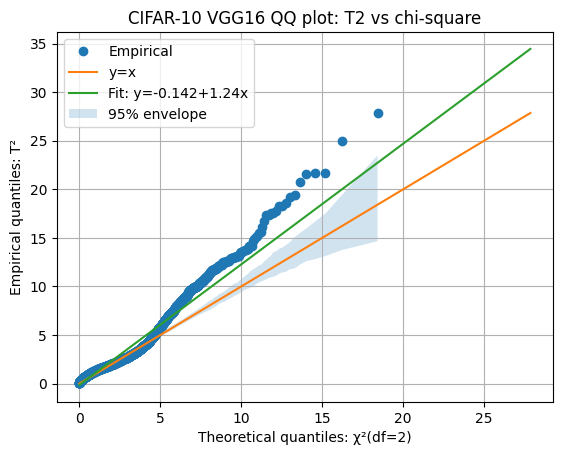

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'CIFAR-10 VGG16 QQ plot: T2 vs chi-square'}, xlabel='Theoretical quantiles: χ²(df=2)', ylabel='Empirical quantiles: T²'>,
 {'intercept': -0.14152351778385408, 'slope': 1.241912435594842})

In [333]:
benign_path_ls = [overlapping_model_16, same_model_16]

aux_matrix = collecting_full_test_samples(benign_path_ls)

T2s, report = sanity_check_chi2(aux_matrix, k=20, R=5000, shrinkage=None, seed=42)
print(report)

qq_plot_chi2_envelope(T2s, df=2, title="CIFAR-10 VGG16 QQ plot: T2 vs chi-square")

In [298]:
alphas = (0.10, 0.05, 0.01, 0.001)
held_out_size = 10
benign_path_ls = [overlapping_model_16, same_model_16]

for i in range(10):
    print(f"The {i} time sampling run:")
    neg_pairs, aux_matrix = collecting_test_samples(benign_path_ls, held_out_size)
    mu, S, fit_info = hotelling_T2_raw_fit(aux_matrix, ddof=1)
    print("FIT:", fit_info)
    
    neg_records, neg_summary = evaluate_group("NEG(benign-heldout)", neg_pairs, mu, S, alphas=alphas, verbose=False,
                                             k=29, scaling="paper")
    print("NEG SUMMARY:", neg_summary)
    
    pos_records, pos_summary = evaluate_group("POS(suspect)", positive_arr, mu, S, alphas=alphas, verbose=False,
                                             k=29, scaling="paper")
    print("POS SUMMARY:", pos_summary)

The 0 time sampling run:
[ 1  6  7 21 22 23 24 29 36 37]
FIT: {'mu': array([4.24481673, 3.22278676]), 'S': array([[ 0.23122219, -0.03677109],
       [-0.03677109,  0.00593569]]), 'eigvals': array([8.58365716e-05, 2.37072039e-01]), 'cond': 2761.900141707134, 'k': 29, 'p': 2}
NEG SUMMARY: {'group': 'NEG(benign-heldout)', 'n': 10, 'rej@0.1': 1, 'rate@0.1': 0.1, 'rej@0.05': 0, 'rate@0.05': 0.0, 'rej@0.01': 0, 'rate@0.01': 0.0, 'rej@0.001': 0, 'rate@0.001': 0.0}
POS SUMMARY: {'group': 'POS(suspect)', 'n': 4, 'rej@0.1': 4, 'rate@0.1': 1.0, 'rej@0.05': 4, 'rate@0.05': 1.0, 'rej@0.01': 4, 'rate@0.01': 1.0, 'rej@0.001': 4, 'rate@0.001': 1.0}
The 1 time sampling run:
[ 6  7 10 20 24 26 28 30 32 37]
FIT: {'mu': array([4.26007573, 3.22036398]), 'S': array([[ 0.24208547, -0.0382812 ],
       [-0.0382812 ,  0.00611097]]), 'eigvals': array([5.61272577e-05, 2.48140315e-01]), 'cond': 4421.030454872253, 'k': 29, 'p': 2}
NEG SUMMARY: {'group': 'NEG(benign-heldout)', 'n': 10, 'rej@0.1': 2, 'rate@0.1': 0.2

# CIFAR-100 ResNet-18

In [334]:
overlapping_model_18 = [] # interior points in this tube
for frac in np.arange(0.05, 1.0, 0.05):
    round_frac = round(frac, 2)
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_tagging_{round_frac}_size_10000_MI.csv"
    overlapping_model_18.append(log_path)

same_model_18 = [] # endpoints in this tube
for seed in range(42, 52):
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_{seed}_1.0_MI.csv"
    same_model_18.append(log_path)

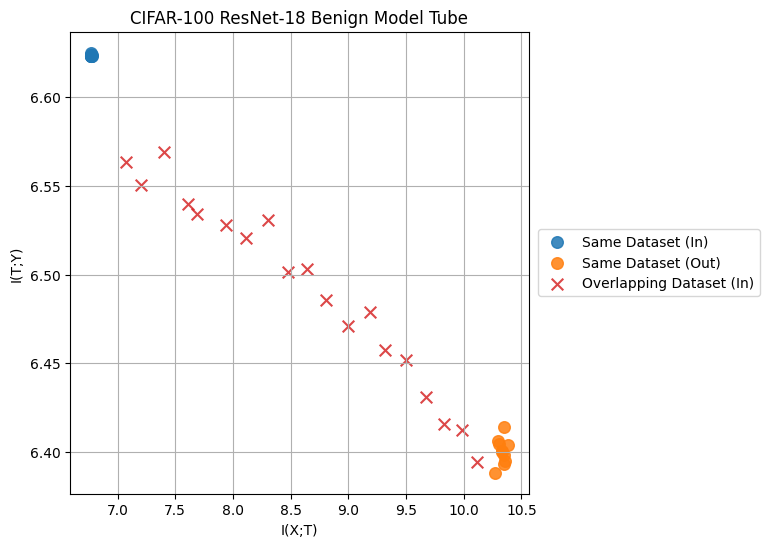

In [336]:
endpoints18_in_group = GroupSpec(
    label="Same Dataset (In)",
    csv_paths=same_model_18,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

endpoints18_out_group = GroupSpec(
    label="Same Dataset (Out)",
    csv_paths=same_model_18,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

overlapping18_in_group = GroupSpec(
    label="Overlapping Dataset (In)",
    csv_paths=overlapping_model_18,
    domain="in",
    style={"marker": "x", "color": "tab:red", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

ft18_in_group = GroupSpec(
    label="Fine-tune(In)",
    csv_paths=csv_paths,
    domain="in",
    style={"marker": "x", "color": "tab:pink", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

plot_information_plane([endpoints18_in_group, endpoints18_out_group, overlapping18_in_group], title="CIFAR-100 ResNet-18 Benign Model Tube")

# Sanity Check

{'k': 20, 'R': 5000, 'p': 2, 'mean_T2': 2.3413220493242615, 'var_T2': 8.053148783690013, 'crit@0.1': 4.605170185988092, 'tail_rate@0.1': 0.0876, 'tail_err@0.1': -0.012400000000000008, 'crit@0.05': 5.991464547107979, 'tail_rate@0.05': 0.0616, 'tail_err@0.05': 0.0116, 'crit@0.01': 9.21034037197618, 'tail_rate@0.01': 0.0316, 'tail_err@0.01': 0.0216}


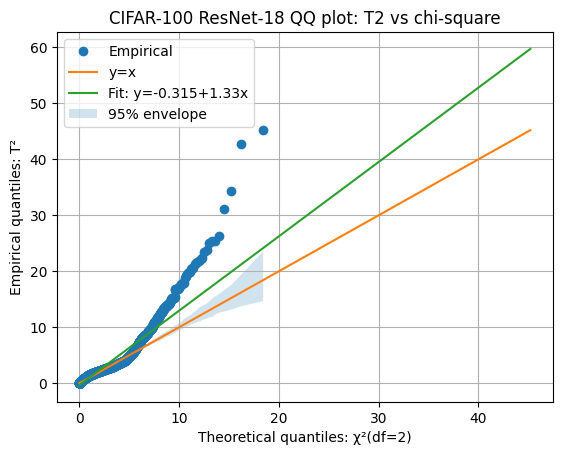

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'CIFAR-100 ResNet-18 QQ plot: T2 vs chi-square'}, xlabel='Theoretical quantiles: χ²(df=2)', ylabel='Empirical quantiles: T²'>,
 {'intercept': -0.31460387805529316, 'slope': 1.328055015235296})

In [338]:
benign_path_ls = [overlapping_model_18, same_model_18]

aux_matrix = collecting_full_test_samples(benign_path_ls)

T2s, report = sanity_check_chi2(aux_matrix, k=20, R=5000, shrinkage=None, seed=42)
print(report)

qq_plot_chi2_envelope(T2s, df=2, title="CIFAR-100 ResNet-18 QQ plot: T2 vs chi-square")

In [312]:
# positive pairs
import glob
import os

# Replace this with the actual path shown in your file explorer image
folder_path = r'E:\Experiment\saved_logs\fine_tune_vanilla\MI'

# This grabs every file ending in .csv and puts the full path in a list
csv_paths = glob.glob(os.path.join(folder_path, "*CIFAR-100_*ResNet-18*.csv"))
print(csv_paths)
positive_18 = []
for path in csv_paths:
    points = read_mi_points1(path, "in")
    positive_18.append((points[-1]['ix'], points[-1]['iy'])) # only loading the last epoch here

positive_arr = np.array(positive_18, dtype=float)

['E:\\Experiment\\saved_logs\\fine_tune_vanilla\\MI\\training_log_CIFAR-100_ResNet-18_40000_Same_10000_42_1.0_FT-AL_MI.csv', 'E:\\Experiment\\saved_logs\\fine_tune_vanilla\\MI\\training_log_CIFAR-100_ResNet-18_40000_Same_10000_42_1.0_FT-LL_MI.csv']


In [313]:
alphas = (0.10, 0.05, 0.01, 0.001)
held_out_size = 10
benign_path_ls = [overlapping_model_18, same_model_18]

for i in range(10):
    print(f"The {i} time sampling run:")
    neg_pairs, aux_matrix = collecting_test_samples(benign_path_ls, held_out_size)
    mu, S, fit_info = hotelling_T2_raw_fit(aux_matrix, ddof=1)
    print("FIT:", fit_info)
    
    neg_records, neg_summary = evaluate_group("NEG(benign-heldout)", neg_pairs, mu, S, alphas=alphas, verbose=True,
                                             k=29, scaling="paper")
    print("NEG SUMMARY:", neg_summary)
    
    pos_records, pos_summary = evaluate_group("POS(suspect)", positive_arr, mu, S, alphas=alphas, verbose=True,
                                             k=29, scaling="paper")
    print("POS SUMMARY:", pos_summary)

The 0 time sampling run:
[ 2  6  7 10 14 15 19 22 29 30]
FIT: {'mu': array([8.58452042, 6.50377836]), 'S': array([[ 2.28963828, -0.13866831],
       [-0.13866831,  0.00855953]]), 'eigvals': array([1.60710055e-04, 2.29803709e+00]), 'cond': 14299.27392378925, 'k': 29, 'p': 2}
[NEG(benign-heldout) #0] x=[9.83355522 6.4155426 ]  T2=1.608586  p=0.447404  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #1] x=[9.18558121 6.47888803]  T2=0.946750  p=0.622896  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #2] x=[9.00138855 6.47109938]  T2=0.404391  p=0.816935  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #3] x=[8.4784584  6.50130463]  T2=0.479156  p=0.78696  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #4] x=[7.68957615 6.53415585]  T2=3.739490  p=0.154163  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #5] x=[7.60646152 6.53964329]  T2=3.676885  p=0.159065  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #6]

# CIFAR-100 VGG16

In [339]:
overlapping_model_16 = [] # interior points in this tube
for frac in np.arange(0.05, 1.0, 0.05):
    round_frac = round(frac, 2)
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-100_VGG16_40000_42_1.0_tagging_{round_frac}_size_10000_MI.csv"
    overlapping_model_16.append(log_path)

same_model_16 = [] # endpoints in this tube
for seed in range(42, 52):
    log_path = f"./saved_logs/vanilla/MI/training_log_CIFAR-100_VGG16_40000_{seed}_1.0_MI.csv"
    same_model_16.append(log_path)

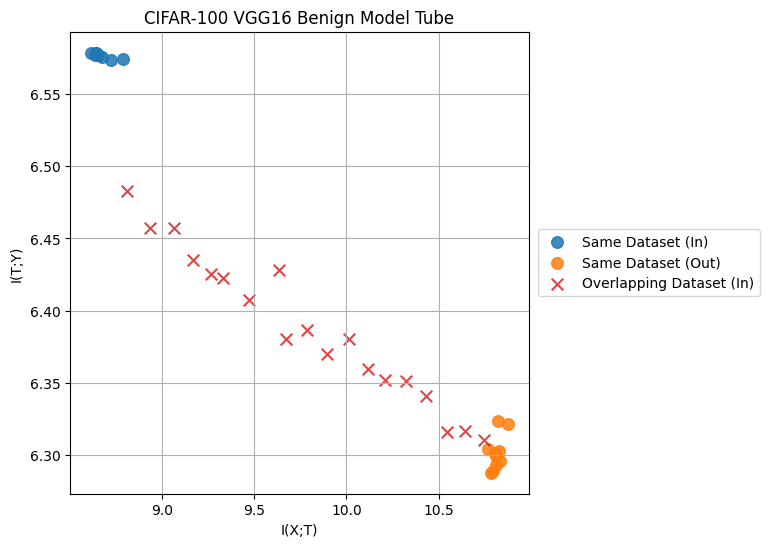

In [340]:
endpoints16_in_group = GroupSpec(
    label="Same Dataset (In)",
    csv_paths=same_model_16,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

endpoints16_out_group = GroupSpec(
    label="Same Dataset (Out)",
    csv_paths=same_model_16,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

overlapping16_in_group = GroupSpec(
    label="Overlapping Dataset (In)",
    csv_paths=overlapping_model_16,
    domain="in",
    style={"marker": "x", "color": "tab:red", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

plot_information_plane([endpoints16_in_group, endpoints16_out_group, overlapping16_in_group], title="CIFAR-100 VGG16 Benign Model Tube")

# Sanity Check

{'k': 20, 'R': 5000, 'p': 2, 'mean_T2': 2.2153921259244953, 'var_T2': 3.652966485584123, 'crit@0.1': 4.605170185988092, 'tail_rate@0.1': 0.0772, 'tail_err@0.1': -0.0228, 'crit@0.05': 5.991464547107979, 'tail_rate@0.05': 0.0312, 'tail_err@0.05': -0.018800000000000004, 'crit@0.01': 9.21034037197618, 'tail_rate@0.01': 0.0038, 'tail_err@0.01': -0.006200000000000001}


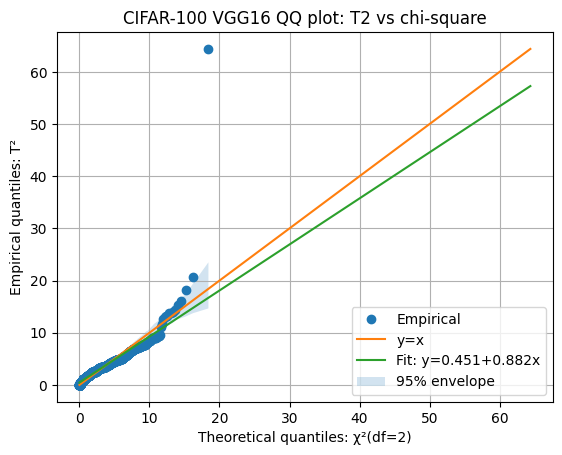

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'CIFAR-100 VGG16 QQ plot: T2 vs chi-square'}, xlabel='Theoretical quantiles: χ²(df=2)', ylabel='Empirical quantiles: T²'>,
 {'intercept': 0.45069836260343765, 'slope': 0.8824080440546325})

In [341]:
benign_path_ls = [overlapping_model_16, same_model_16]

aux_matrix = collecting_full_test_samples(benign_path_ls)

T2s, report = sanity_check_chi2(aux_matrix, k=20, R=5000, shrinkage=None, seed=42)
print(report)

qq_plot_chi2_envelope(T2s, df=2, title="CIFAR-100 VGG16 QQ plot: T2 vs chi-square")

In [317]:
# positive pairs
import glob
import os

# Replace this with the actual path shown in your file explorer image
folder_path = r'E:\Experiment\saved_logs\fine_tune_vanilla\MI'

# This grabs every file ending in .csv and puts the full path in a list
csv_paths = glob.glob(os.path.join(folder_path, "*CIFAR-100_*VGG16*.csv"))
print(csv_paths)
positive_16 = []
for path in csv_paths:
    points = read_mi_points1(path, "in")
    positive_16.append((points[-1]['ix'], points[-1]['iy'])) # only loading the last epoch here

positive_arr = np.array(positive_16, dtype=float)

['E:\\Experiment\\saved_logs\\fine_tune_vanilla\\MI\\training_log_CIFAR-100_VGG16_40000_Same_10000_42_1.0_FT-AL_MI.csv', 'E:\\Experiment\\saved_logs\\fine_tune_vanilla\\MI\\training_log_CIFAR-100_VGG16_40000_Same_10000_42_1.0_FT-LL_MI.csv']


In [318]:
alphas = (0.10, 0.05, 0.01, 0.001)
held_out_size = 10
benign_path_ls = [overlapping_model_16, same_model_16]

for i in range(10):
    print(f"The {i} time sampling run:")
    neg_pairs, aux_matrix = collecting_test_samples(benign_path_ls, held_out_size)
    mu, S, fit_info = hotelling_T2_raw_fit(aux_matrix, ddof=1)
    print("FIT:", fit_info)
    
    neg_records, neg_summary = evaluate_group("NEG(benign-heldout)", neg_pairs, mu, S, alphas=alphas, verbose=True,
                                             k=29, scaling="paper")
    print("NEG SUMMARY:", neg_summary)
    
    pos_records, pos_summary = evaluate_group("POS(suspect)", positive_arr, mu, S, alphas=alphas, verbose=True,
                                             k=29, scaling="paper")
    print("POS SUMMARY:", pos_summary)

The 0 time sampling run:
[ 0  2  9 12 13 15 21 25 29 30]
FIT: {'mu': array([9.75640958, 6.41877146]), 'S': array([[ 0.80777497, -0.09668624],
       [-0.09668624,  0.0124272 ]]), 'eigvals': array([0.0008423 , 0.81935987]), 'cond': 972.7606809521044, 'k': 29, 'p': 2}
[NEG(benign-heldout) #0] x=[10.7432766  6.3101716]  T2=1.268076  p=0.530445  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #1] x=[10.54203606  6.3157959 ]  T2=0.829051  p=0.660654  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #2] x=[9.78660202 6.38644648]  T2=0.933752  p=0.626958  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #3] x=[9.47288227 6.40744638]  T2=2.414056  p=0.299085  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #4] x=[9.32941246 6.42234612]  T2=2.774673  p=0.24974  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #5] x=[9.1676054  6.43496084]  T2=3.749299  p=0.153409  a=0.1:OK a=0.05:OK a=0.01:OK a=0.001:OK
[NEG(benign-heldout) #6] x=[8.

In [357]:
def generate_neg_csv_paths(dataset_name, model_name):
    overlapping = []
    for frac in np.arange(0.05, 1.0, 0.05):
        round_frac = round(frac, 2)
        log_path = f"./saved_logs/vanilla/MI/training_log_{dataset_name}_{model_name}_40000_42_1.0_tagging_{round_frac}_size_10000_MI.csv"
        overlapping.append(log_path)

    same = [] # endpoints in this tube
    for seed in range(42, 52):
        log_path = f"./saved_logs/vanilla/MI/training_log_{dataset_name}_{model_name}_40000_{seed}_1.0_MI.csv"
        same.append(log_path)

    return [overlapping, same]
    
import numpy as np
from scipy.stats import chi2

def cov_inverse_quality(S, *, rcond_rank=1e-12, eps_eig=1e-12, seed=0):
    """
    Lightweight covariance invertibility/quality diagnostics.
    Returns dict with cond, min/max eig, rank_est, is_pd, and solve residual.
    """
    S = np.asarray(S, float)
    p = S.shape[0]
    Ssym = 0.5 * (S + S.T)

    eigvals = np.linalg.eigvalsh(Ssym)
    eig_min = float(eigvals.min())
    eig_max = float(eigvals.max())
    cond = float(abs(eig_max) / max(abs(eig_min), eps_eig))

    tol = max(eig_max, 1.0) * rcond_rank
    rank = int(np.sum(eigvals > tol))

    # PD check
    try:
        np.linalg.cholesky(Ssym)
        is_pd = True
    except np.linalg.LinAlgError:
        is_pd = False

    # Solve residual check (how close solve(S,I) is to inverse)
    I = np.eye(p)
    try:
        X = np.linalg.solve(Ssym, I)
        solve_resid = float(np.linalg.norm(I - Ssym @ X, ord="fro") / (np.linalg.norm(I, ord="fro") + 1e-30))
        solve_ok = True
    except np.linalg.LinAlgError:
        solve_resid = float("inf")
        solve_ok = False

    flags = []
    if rank < p:
        flags.append(f"rank_deficient({rank}/{p})")
    if not is_pd:
        flags.append("not_pd(cholesky_fail)")
    if cond > 1e6:
        flags.append(f"ill_conditioned({cond:.2e})")
    if not solve_ok:
        flags.append("solve_failed")
    elif solve_resid > 1e-6:
        flags.append(f"solve_residual_large({solve_resid:.2e})")
    if eig_min <= 0:
        flags.append(f"nonpositive_min_eig({eig_min:.2e})")

    return {
        "p": p,
        "eigvals": eigvals,
        "eig_min": eig_min,
        "eig_max": eig_max,
        "cond_eig": cond,
        "rank_est": rank,
        "is_pd": is_pd,
        "solve_residual_rel_fro": solve_resid,
        "flags": flags,
    }


def hotelling_T2_score_solve(mu, S, x, k_ref, scaling="paper"):
    """
    Stable Mahalanobis distance using solve() instead of inv().
    scaling:
      - "none": T2 = md2
      - "paper": T2 = (k_ref/(k_ref+1)) * md2
      - "k": T2 = k_ref * md2 (not recommended for your paper-style test)
    """
    x = np.asarray(x, float).ravel()
    mu = np.asarray(mu, float).ravel()
    diff = x - mu

    # md2 = diff^T S^{-1} diff via solve
    md2 = float(diff @ np.linalg.solve(S, diff))

    if scaling == "none":
        T2 = md2
    elif scaling == "paper":
        T2 = float((k_ref / (k_ref + 1.0)) * md2)
    elif scaling == "k":
        T2 = float(k_ref * md2)
    else:
        raise ValueError("scaling must be in {'none','paper','k'}")

    pval = 1.0 - chi2.cdf(T2, df=len(mu))
    return T2, pval, {"diff": diff, "md2": md2, "scaling": scaling, "k_ref": k_ref}


def sanity_check_chi2_loo(
    M,                      # shape (N,p): MI vectors from known-independent models
    ddof=1,
    scaling="paper",
    alphas=(0.10, 0.05, 0.01),
    shrinkage=None,         # e.g. 0.05 or None
    rcond_rank=1e-12,
):
    """
    Leave-one-out sanity check:
      For each i:
        - target = M[i]
        - reference = M[all except i] (size k_ref=N-1)
        - fit mu, S on reference
        - optional shrinkage on S
        - compute T2_i
        - compute covariance inverse quality metrics

    Returns:
      T2s: shape (N,)
      report: summary dict (mean/var + tail rates vs chi2_p + quality summaries)
      qualities: list of per-fold quality dicts (length N)
      pvals: shape (N,)
    """
    M = np.asarray(M, float)
    N, p = M.shape
    if N < p + 3:
        raise ValueError(f"Need N >= p+3 for stable LOO covariance; got N={N}, p={p}")

    k_ref = N - 1
    T2s = np.empty(N, dtype=float)
    pvals = np.empty(N, dtype=float)
    qualities = []

    for i in range(N):
        ref_mask = np.ones(N, dtype=bool)
        ref_mask[i] = False
        Xref = M[ref_mask]  # (N-1, p)

        mu = Xref.mean(axis=0)
        S = np.cov(Xref, rowvar=False, ddof=ddof)

        if shrinkage is not None:
            lam = float(shrinkage)
            S = (1.0 - lam) * S + lam * (np.trace(S) / p) * np.eye(p)

        q = cov_inverse_quality(S, rcond_rank=rcond_rank)
        q["i_left_out"] = i
        q["k_ref"] = k_ref
        qualities.append(q)

        T2, pv, _ = hotelling_T2_score_solve(mu, S, M[i], k_ref=k_ref, scaling=scaling)
        T2s[i] = T2
        pvals[i] = pv

    # --- chi-square tail calibration (LOO sample as "null draws") ---
    report = {
        "N": N,
        "k_ref": k_ref,
        "p": p,
        "mean_T2": float(T2s.mean()),
        "var_T2": float(T2s.var(ddof=1)),
        "scaling": scaling,
        "shrinkage": shrinkage,
    }

    for a in alphas:
        crit = chi2.ppf(1.0 - a, df=p)
        report[f"crit@{a}"] = float(crit)
        report[f"tail_rate@{a}"] = float((T2s > crit).mean())
        report[f"tail_err@{a}"] = report[f"tail_rate@{a}"] - a

    # --- quality summaries ---
    conds = np.array([q["cond_eig"] for q in qualities], float)
    mins = np.array([q["eig_min"] for q in qualities], float)
    resid = np.array([q["solve_residual_rel_fro"] for q in qualities], float)
    n_flagged = sum(1 for q in qualities if len(q["flags"]) > 0)

    report.update({
        "cond_med": float(np.median(conds)),
        "cond_max": float(np.max(conds)),
        "min_eig_med": float(np.median(mins)),
        "min_eig_min": float(np.min(mins)),
        "solve_resid_med": float(np.median(resid)),
        "solve_resid_max": float(np.max(resid)),
        "n_flagged": int(n_flagged),
    })

    return T2s, report, qualities, pvals


In [367]:
csv_10_18 = generate_neg_csv_paths("CIFAR-10", "ResNet-18")
csv_10_16 = generate_neg_csv_paths("CIFAR-10", "VGG16")
aux_10_18 = collecting_full_test_samples(csv_10_18)
aux_10_16 = collecting_full_test_samples(csv_10_16)

In [368]:
T2s, rep, qualities, pvals = sanity_check_chi2_loo(
    aux_10_18, ddof=1, scaling="paper", shrinkage=None
)
print(rep)

# Find the worst covariance folds
worst = sorted(qualities, key=lambda q: q["cond_eig"], reverse=True)[:5]
for q in worst:
    print("left_out:", q["i_left_out"], "cond:", q["cond_eig"], "min_eig:", q["eig_min"], "flags:", q["flags"])

# Find top T2 outliers and inspect their covariance quality
top_idx = np.argsort(T2s)[-5:][::-1]
for i in top_idx:
    q = qualities[i]
    print("T2:", T2s[i], "left_out:", i, "cond:", q["cond_eig"], "min_eig:", q["eig_min"], "flags:", q["flags"])

{'N': 39, 'k_ref': 38, 'p': 2, 'mean_T2': 2.130787850817858, 'var_T2': 3.1912775199279992, 'scaling': 'paper', 'shrinkage': None, 'crit@0.1': 4.605170185988092, 'tail_rate@0.1': 0.10256410256410256, 'tail_err@0.1': 0.002564102564102555, 'crit@0.05': 5.991464547107979, 'tail_rate@0.05': 0.05128205128205128, 'tail_err@0.05': 0.0012820512820512775, 'crit@0.01': 9.21034037197618, 'tail_rate@0.01': 0.0, 'tail_err@0.01': -0.01, 'cond_med': 8056.86498952178, 'cond_max': 9546.126582458275, 'min_eig_med': 2.773095303377441e-05, 'min_eig_min': 2.3768097181525814e-05, 'solve_resid_med': 5.48635606952986e-14, 'solve_resid_max': 1.65686272453032e-13, 'n_flagged': 0}
left_out: 8 cond: 9546.126582458275 min_eig: 2.3768097181525814e-05 flags: []
left_out: 33 cond: 9090.715081883392 min_eig: 2.4013508621057843e-05 flags: []
left_out: 6 cond: 8842.97199193262 min_eig: 2.5597989180713068e-05 flags: []
left_out: 1 cond: 8833.167558152712 min_eig: 2.503150879698112e-05 flags: []
left_out: 35 cond: 8655.025

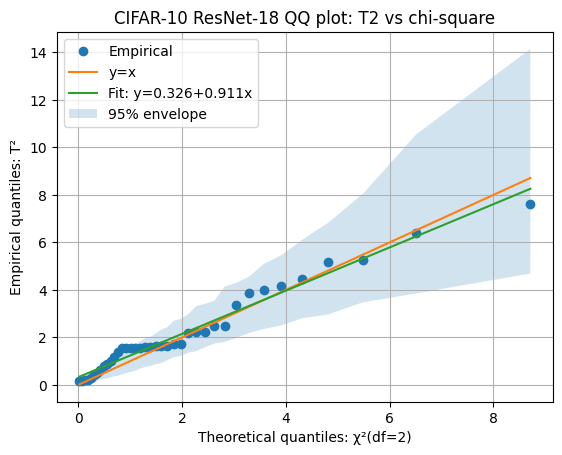

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'CIFAR-10 ResNet-18 QQ plot: T2 vs chi-square'}, xlabel='Theoretical quantiles: χ²(df=2)', ylabel='Empirical quantiles: T²'>,
 {'intercept': 0.32580620856781123, 'slope': 0.910557549807069})

In [369]:
qq_plot_chi2_envelope(T2s, df=2, title="CIFAR-10 ResNet-18 QQ plot: T2 vs chi-square")

In [370]:
T2s, rep, qualities, pvals = sanity_check_chi2_loo(
    aux_10_16, ddof=1, scaling="paper", shrinkage=None
)
print(rep)

# Find the worst covariance folds
worst = sorted(qualities, key=lambda q: q["cond_eig"], reverse=True)[:5]
for q in worst:
    print("left_out:", q["i_left_out"], "cond:", q["cond_eig"], "min_eig:", q["eig_min"], "flags:", q["flags"])

# Find top T2 outliers and inspect their covariance quality
top_idx = np.argsort(T2s)[-5:][::-1]
for i in top_idx:
    q = qualities[i]
    print("T2:", T2s[i], "left_out:", i, "cond:", q["cond_eig"], "min_eig:", q["eig_min"], "flags:", q["flags"])

{'N': 39, 'k_ref': 38, 'p': 2, 'mean_T2': 2.150252410766732, 'var_T2': 4.291826005908133, 'scaling': 'paper', 'shrinkage': None, 'crit@0.1': 4.605170185988092, 'tail_rate@0.1': 0.10256410256410256, 'tail_err@0.1': 0.002564102564102555, 'crit@0.05': 5.991464547107979, 'tail_rate@0.05': 0.05128205128205128, 'tail_err@0.05': 0.0012820512820512775, 'crit@0.01': 9.21034037197618, 'tail_rate@0.01': 0.02564102564102564, 'tail_err@0.01': 0.015641025641025638, 'cond_med': 2931.0042652862994, 'cond_max': 3399.8268008322198, 'min_eig_med': 8.585885420121873e-05, 'min_eig_min': 7.116693391584668e-05, 'solve_resid_med': 2.061511536472324e-14, 'solve_resid_max': 5.893403276171213e-14, 'n_flagged': 0}
left_out: 30 cond: 3399.8268008322198 min_eig: 7.116693391584668e-05 flags: []
left_out: 32 cond: 3355.431609418702 min_eig: 7.352369988160648e-05 flags: []
left_out: 0 cond: 3188.1770331807033 min_eig: 7.77898898594179e-05 flags: []
left_out: 7 cond: 3102.630827325927 min_eig: 8.212924884930597e-05 fla

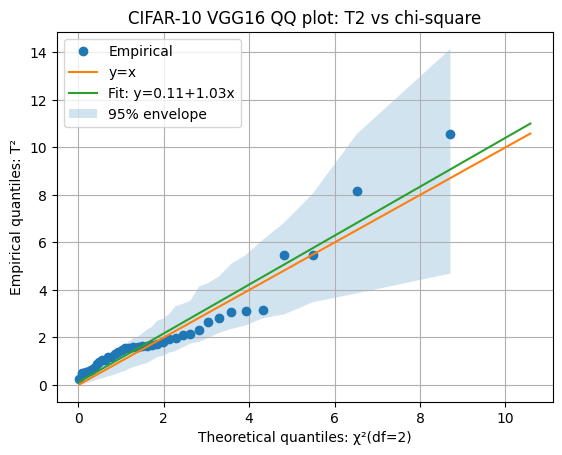

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'CIFAR-10 VGG16 QQ plot: T2 vs chi-square'}, xlabel='Theoretical quantiles: χ²(df=2)', ylabel='Empirical quantiles: T²'>,
 {'intercept': 0.1095950933996699, 'slope': 1.0294486566529897})

In [371]:
qq_plot_chi2_envelope(T2s, df=2, title="CIFAR-10 VGG16 QQ plot: T2 vs chi-square")

In [376]:
csv_100_18 = generate_neg_csv_paths("CIFAR-100", "ResNet-18")
csv_100_16 = generate_neg_csv_paths("CIFAR-100", "VGG16")
aux_100_18 = collecting_full_test_samples(csv_100_18)
aux_100_16 = collecting_full_test_samples(csv_100_16)

In [377]:
T2s, rep, qualities, pvals = sanity_check_chi2_loo(
    aux_100_18, ddof=1, scaling="paper", shrinkage=None
)
print(rep)

# Find the worst covariance folds
worst = sorted(qualities, key=lambda q: q["cond_eig"], reverse=True)[:5]
for q in worst:
    print("left_out:", q["i_left_out"], "cond:", q["cond_eig"], "min_eig:", q["eig_min"], "flags:", q["flags"])

# Find top T2 outliers and inspect their covariance quality
top_idx = np.argsort(T2s)[-5:][::-1]
for i in top_idx:
    q = qualities[i]
    print("T2:", T2s[i], "left_out:", i, "cond:", q["cond_eig"], "min_eig:", q["eig_min"], "flags:", q["flags"])

{'N': 39, 'k_ref': 38, 'p': 2, 'mean_T2': 2.1476077168693104, 'var_T2': 4.194327491805393, 'scaling': 'paper', 'shrinkage': None, 'crit@0.1': 4.605170185988092, 'tail_rate@0.1': 0.05128205128205128, 'tail_err@0.1': -0.048717948717948725, 'crit@0.05': 5.991464547107979, 'tail_rate@0.05': 0.05128205128205128, 'tail_err@0.05': 0.0012820512820512775, 'crit@0.01': 9.21034037197618, 'tail_rate@0.01': 0.02564102564102564, 'tail_err@0.01': 0.015641025641025638, 'cond_med': 12610.481692778678, 'cond_max': 15844.94496927425, 'min_eig_med': 0.00016731632607915482, 'min_eig_min': 0.0001345018609642326, 'solve_resid_med': 2.4143216339399014e-14, 'solve_resid_max': 9.583864205856908e-14, 'n_flagged': 0}
left_out: 17 cond: 15844.94496927425 min_eig: 0.0001345018609642326 flags: []
left_out: 18 cond: 14737.765379792565 min_eig: 0.00014389584602761928 flags: []
left_out: 14 cond: 13841.962926065504 min_eig: 0.00015619640220352823 flags: []
left_out: 15 cond: 13769.687909268638 min_eig: 0.00015670072834

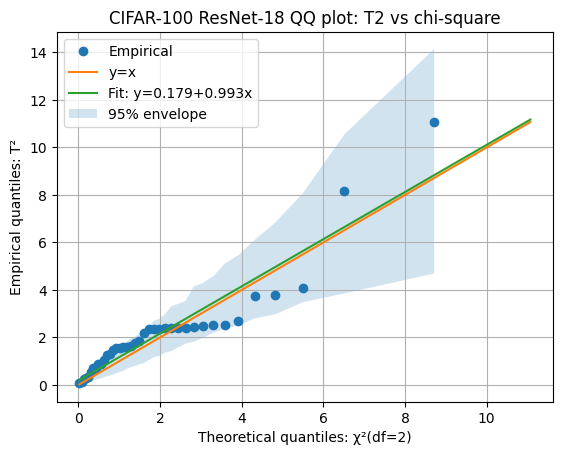

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'CIFAR-100 ResNet-18 QQ plot: T2 vs chi-square'}, xlabel='Theoretical quantiles: χ²(df=2)', ylabel='Empirical quantiles: T²'>,
 {'intercept': 0.17866874820484788, 'slope': 0.9932689624432237})

In [378]:
qq_plot_chi2_envelope(T2s, df=2, title="CIFAR-100 ResNet-18 QQ plot: T2 vs chi-square")

In [380]:
T2s, rep, qualities, pvals = sanity_check_chi2_loo(
    aux_100_16, ddof=1, scaling="paper", shrinkage=None
)
print(rep)

# Find the worst covariance folds
worst = sorted(qualities, key=lambda q: q["cond_eig"], reverse=True)[:5]
for q in worst:
    print("left_out:", q["i_left_out"], "cond:", q["cond_eig"], "min_eig:", q["eig_min"], "flags:", q["flags"])

# Find top T2 outliers and inspect their covariance quality
top_idx = np.argsort(T2s)[-5:][::-1]
for i in top_idx:
    q = qualities[i]
    print("T2:", T2s[i], "left_out:", i, "cond:", q["cond_eig"], "min_eig:", q["eig_min"], "flags:", q["flags"])

{'N': 39, 'k_ref': 38, 'p': 2, 'mean_T2': 2.092378782946922, 'var_T2': 1.4821921119512482, 'scaling': 'paper', 'shrinkage': None, 'crit@0.1': 4.605170185988092, 'tail_rate@0.1': 0.02564102564102564, 'tail_err@0.1': -0.07435897435897437, 'crit@0.05': 5.991464547107979, 'tail_rate@0.05': 0.0, 'tail_err@0.05': -0.05, 'crit@0.01': 9.21034037197618, 'tail_rate@0.01': 0.0, 'tail_err@0.01': -0.01, 'cond_med': 904.3665744513471, 'cond_max': 992.3233549628297, 'min_eig_med': 0.0008612286316615481, 'min_eig_min': 0.0007950314718222721, 'solve_resid_med': 5.4376046034259415e-15, 'solve_resid_max': 1.4211632037594365e-14, 'n_flagged': 0}
left_out: 17 cond: 992.3233549628297 min_eig: 0.0007950314718222721 flags: []
left_out: 15 cond: 982.6737241134396 min_eig: 0.000812084780759963 flags: []
left_out: 14 cond: 978.5709890309626 min_eig: 0.0008185762862472825 flags: []
left_out: 10 cond: 976.6411641354666 min_eig: 0.0008269744700295425 flags: []
left_out: 13 cond: 966.9593469620498 min_eig: 0.0008300

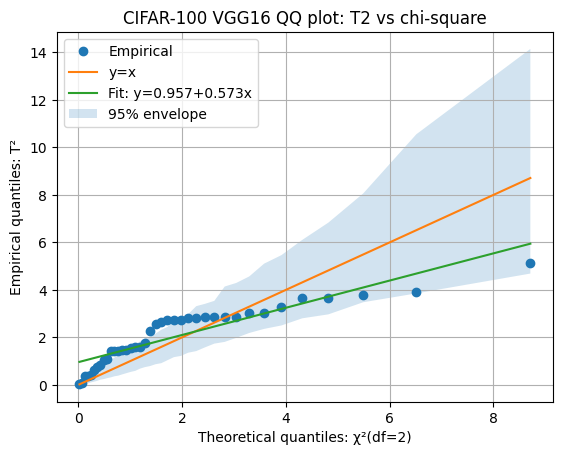

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'CIFAR-100 VGG16 QQ plot: T2 vs chi-square'}, xlabel='Theoretical quantiles: χ²(df=2)', ylabel='Empirical quantiles: T²'>,
 {'intercept': 0.9568651182984161, 'slope': 0.5728316100577572})

In [381]:
qq_plot_chi2_envelope(T2s, df=2, title="CIFAR-100 VGG16 QQ plot: T2 vs chi-square")

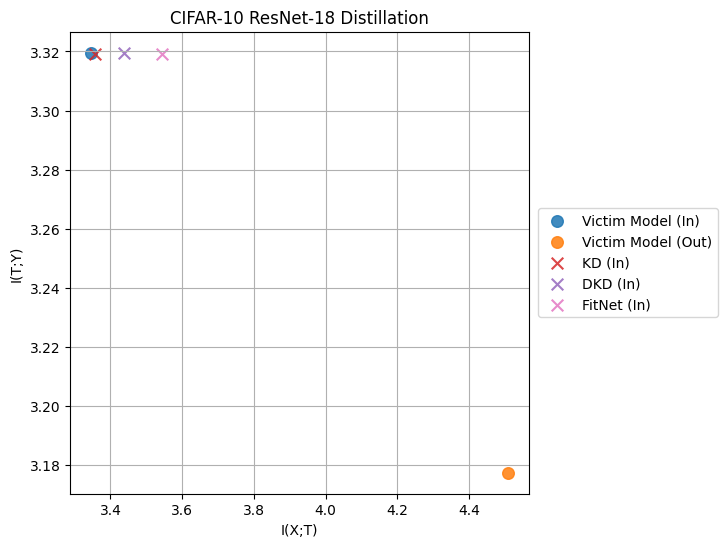

In [402]:
target_model_18 = [f"./saved_logs/vanilla/MI/training_log_CIFAR-10_ResNet-18_40000_42_1.0_MI.csv"] # interior points in this tube
kd_model_18 = [f"./saved_logs/kd_vanilla/MI/training_log_CIFAR-10_ResNet-18to10_40000_KD_42_1.0_MI.csv"]
dkd_model_18 = [f"./saved_logs/kd_vanilla/MI/training_log_CIFAR-10_ResNet-18to10_40000_DKD_42_1.0_MI.csv"]
fitnet_model_18 = [f"./saved_logs/kd_vanilla/MI/training_log_CIFAR-10_ResNet-18to10_40000_FitNet_42_1.0_MI.csv"]

negative18_in_group = GroupSpec(
    label="Victim Model (In)",
    csv_paths=target_model_18,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

negative18_out_group = GroupSpec(
    label="Victim Model (Out)",
    csv_paths=target_model_18,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

kd18_in_group = GroupSpec(
    label="KD (In)",
    csv_paths=kd_model_18,
    domain="in",
    style={"marker": "x", "color": "tab:red", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

dkd18_in_group = GroupSpec(
    label="DKD (In)",
    csv_paths=dkd_model_18,
    domain="in",
    style={"marker": "x", "color": "tab:purple", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

fitnet18_in_group = GroupSpec(
    label="FitNet (In)",
    csv_paths=fitnet_model_18,
    domain="in",
    style={"marker": "x", "color": "tab:pink", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)


plot_information_plane([negative18_in_group, negative18_out_group, kd18_in_group, dkd18_in_group, fitnet18_in_group], 
                       title="CIFAR-10 ResNet-18 Distillation")

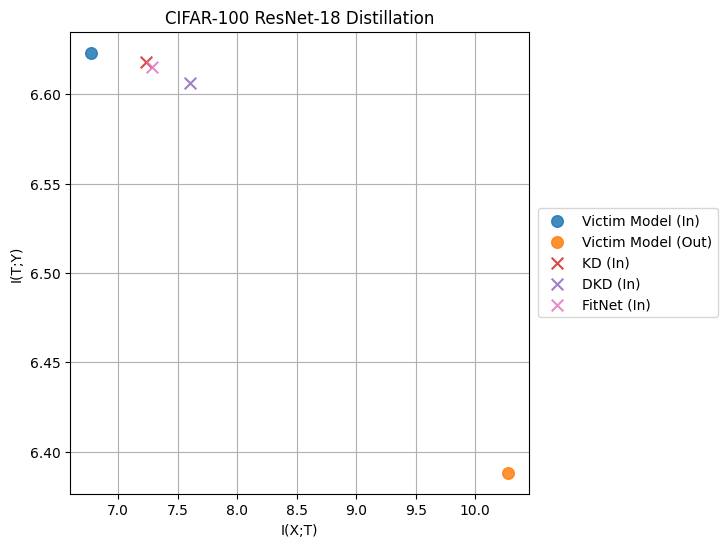

In [403]:
target_model_18 = [f"./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_MI.csv"] # interior points in this tube
kd_model_18 = [f"./saved_logs/kd_vanilla/MI/training_log_CIFAR-100_ResNet-18to10_40000_KD_42_1.0_MI.csv"]
dkd_model_18 = [f"./saved_logs/kd_vanilla/MI/training_log_CIFAR-100_ResNet-18to10_40000_DKD_42_1.0_MI.csv"]
fitnet_model_18 = [f"./saved_logs/kd_vanilla/MI/training_log_CIFAR-100_ResNet-18to10_40000_FitNet_42_1.0_MI.csv"]

negative18_in_group = GroupSpec(
    label="Victim Model (In)",
    csv_paths=target_model_18,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

negative18_out_group = GroupSpec(
    label="Victim Model (Out)",
    csv_paths=target_model_18,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

kd18_in_group = GroupSpec(
    label="KD (In)",
    csv_paths=kd_model_18,
    domain="in",
    style={"marker": "x", "color": "tab:red", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

dkd18_in_group = GroupSpec(
    label="DKD (In)",
    csv_paths=dkd_model_18,
    domain="in",
    style={"marker": "x", "color": "tab:purple", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

fitnet18_in_group = GroupSpec(
    label="FitNet (In)",
    csv_paths=fitnet_model_18,
    domain="in",
    style={"marker": "x", "color": "tab:pink", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)


plot_information_plane([negative18_in_group, negative18_out_group, kd18_in_group, dkd18_in_group, fitnet_in_group18], 
                       title="CIFAR-100 ResNet-18 Distillation")

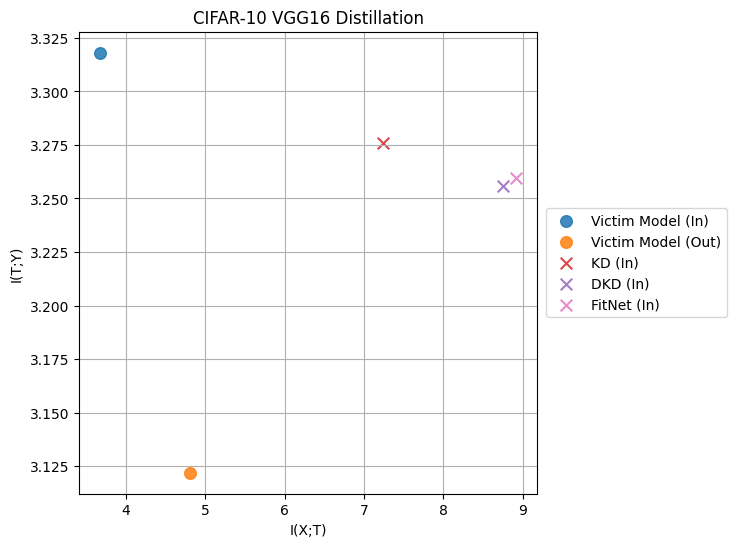

In [405]:
target_model_16 = [f"./saved_logs/vanilla/MI/training_log_CIFAR-10_VGG16_40000_42_1.0_MI.csv"] # interior points in this tube
kd_model_16 = [f"./saved_logs/kd_vanilla/MI/training_log_CIFAR-10_VGG16to8_40000_KD_42_1.0_MI.csv"]
dkd_model_16 = [f"./saved_logs/kd_vanilla/MI/training_log_CIFAR-10_VGG16to8_40000_DKD_42_1.0_MI.csv"]
fitnet_model_16 = [f"./saved_logs/kd_vanilla/MI/training_log_CIFAR-10_VGG16to8_40000_FitNet_42_1.0_MI.csv"]

negative16_in_group = GroupSpec(
    label="Victim Model (In)",
    csv_paths=target_model_16,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

negative16_out_group = GroupSpec(
    label="Victim Model (Out)",
    csv_paths=target_model_16,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

kd16_in_group = GroupSpec(
    label="KD (In)",
    csv_paths=kd_model_16,
    domain="in",
    style={"marker": "x", "color": "tab:red", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

dkd16_in_group = GroupSpec(
    label="DKD (In)",
    csv_paths=dkd_model_16,
    domain="in",
    style={"marker": "x", "color": "tab:purple", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

fitnet16_in_group = GroupSpec(
    label="FitNet (In)",
    csv_paths=fitnet_model_16,
    domain="in",
    style={"marker": "x", "color": "tab:pink", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)


plot_information_plane([negative16_in_group, negative16_out_group, kd16_in_group, dkd16_in_group, fitnet16_in_group], 
                       title="CIFAR-10 VGG16 Distillation")

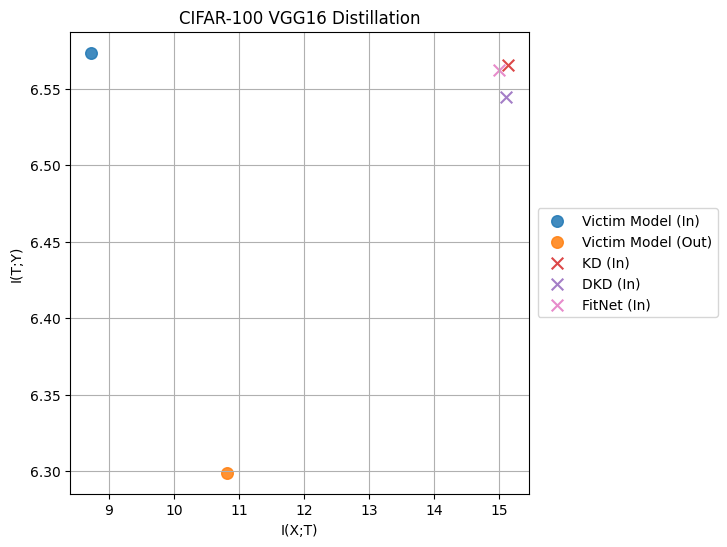

In [406]:
target_model_16 = [f"./saved_logs/vanilla/MI/training_log_CIFAR-100_VGG16_40000_42_1.0_MI.csv"] # interior points in this tube
kd_model_16 = [f"./saved_logs/kd_vanilla/MI/training_log_CIFAR-100_VGG16to8_40000_KD_42_1.0_MI.csv"]
dkd_model_16 = [f"./saved_logs/kd_vanilla/MI/training_log_CIFAR-100_VGG16to8_40000_DKD_42_1.0_MI.csv"]
fitnet_model_16 = [f"./saved_logs/kd_vanilla/MI/training_log_CIFAR-100_VGG16to8_40000_FitNet_42_1.0_MI.csv"]

negative16_in_group = GroupSpec(
    label="Victim Model (In)",
    csv_paths=target_model_16,
    domain="in",
    style={"marker": "o", "color": "tab:blue", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

negative16_out_group = GroupSpec(
    label="Victim Model (Out)",
    csv_paths=target_model_16,
    domain="out",
    style={"marker": "o", "color": "tab:orange", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

kd16_in_group = GroupSpec(
    label="KD (In)",
    csv_paths=kd_model_16,
    domain="in",
    style={"marker": "x", "color": "tab:red", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

dkd16_in_group = GroupSpec(
    label="DKD (In)",
    csv_paths=dkd_model_16,
    domain="in",
    style={"marker": "x", "color": "tab:purple", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)

fitnet16_in_group = GroupSpec(
    label="FitNet (In)",
    csv_paths=fitnet_model_16,
    domain="in",
    style={"marker": "x", "color": "tab:pink", "s": 70, "alpha": 0.85},
    mode="single",
    select_fn=select_last,          # recommended if CSV has many epochs
)


plot_information_plane([negative16_in_group, negative16_out_group, kd16_in_group, dkd16_in_group, fitnet16_in_group], 
                       title="CIFAR-100 VGG16 Distillation")

# Negative Pairs

In [408]:
neg_dict = {}
for frac in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:
    neg_dict[frac] = []

neg_dict[2.0] = []
print(neg_dict)

{0.0: [], 0.1: [], 0.2: [], 0.3: [], 0.4: [], 0.5: [], 0.6: [], 0.7: [], 0.8: [], 0.9: [], 1.0: [], 2.0: []}


In [455]:
import random

def move_random_samples(data):
    # Define the keys we are pulling from and the destination
    source_keys = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    target_key = 2.0
            
    # Loop through each source key, pop a random item, and append to 2.0
    for key in source_keys:
        # Pick a random index based on the current length of the list
        random_index = random.randrange(len(data[key]))
        
        # .pop() removes the item from the list and returns it
        chosen_value = data[key].pop(random_index)
        
        # Add the chosen value to the target key
        data[target_key].append(chosen_value)

    return data

# ==========================================
# Example Usage
# ==========================================

# 1. Setup the dictionary with some dummy data (e.g., 5 items per key)
my_dict = {
    0.0: ['A1', 'A2', 'A3', 'A4', 'A5'],
    0.1: ['B1', 'B2', 'B3', 'B4', 'B5'],
    0.2: ['C1', 'C2', 'C3', 'C4', 'C5'],
    0.3: ['D1', 'D2', 'D3', 'D4', 'D5'],
    0.4: ['E1', 'E2', 'E3', 'E4', 'E5'],
    0.5: ['F1', 'F2', 'F3', 'F4', 'F5'],
    0.6: ['G1', 'G2', 'G3', 'G4', 'G5'],
    0.7: ['H1', 'H2', 'H3', 'H4', 'H5'],
    0.8: ['I1', 'I2', 'I3', 'I4', 'I5'],
    0.9: ['J1', 'J2', 'J3', 'J4', 'J5'],
    1.0: ['K1', 'K2', 'K3', 'K4', 'K5'],
    2.0: []
}

# 2. Run the function (let's say we want to repeat the process 3 times)
my_dict = move_random_samples(my_dict)

print(my_dict)

{0.0: ['A1', 'A2', 'A3', 'A4'], 0.1: ['B1', 'B2', 'B4', 'B5'], 0.2: ['C1', 'C2', 'C4', 'C5'], 0.3: ['D1', 'D2', 'D3', 'D5'], 0.4: ['E1', 'E2', 'E4', 'E5'], 0.5: ['F1', 'F2', 'F4', 'F5'], 0.6: ['G1', 'G2', 'G3', 'G4'], 0.7: ['H1', 'H2', 'H3', 'H5'], 0.8: ['I1', 'I2', 'I3', 'I5'], 0.9: ['J2', 'J3', 'J4', 'J5'], 1.0: ['K1', 'K3', 'K4', 'K5'], 2.0: ['A5', 'B3', 'C3', 'D4', 'E3', 'F3', 'G5', 'H4', 'I4', 'J1', 'K2']}


In [452]:
def fill_in_neg_dict(neg_dict, seed_range, dataset_name, model_name, overlap_rate):
    for seed in seed_range:
        if overlap_rate == 1.0:
            neg_dict[overlap_rate].append(
                f"./saved_logs/vanilla/MI/training_log_{dataset_name}_{model_name}_40000_{seed}_1.0_MI.csv")
        else:
            neg_dict[overlap_rate].append(
                f"./saved_logs/vanilla/MI/training_log_{dataset_name}_{model_name}_40000_{seed}_1.0_overlap_{overlap_rate}_size_10000_MI.csv")

def reset_neg_dict():
    neg_dict = {}
    for frac in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:
        neg_dict[frac] = []
    
    neg_dict[2.0] = []
    return neg_dict

In [448]:
def filling_one_iteration(neg_dict, seed_range, dataset, model):
    for rate in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:
        fill_in_neg_dict(neg_dict, seed_range,dataset, model, rate)
    return neg_dict

In [454]:
for iter in range(0, 1):
    neg_dict = reset_neg_dict()
    neg_dict = filling_one_iteration(neg_dict, range(42, 44), "CIFAR-100", "ResNet-18")

print(neg_dict)

{0.1: ['./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_overlap_0.1_size_10000_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_43_1.0_overlap_0.1_size_10000_MI.csv'], 0.2: ['./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_overlap_0.2_size_10000_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_43_1.0_overlap_0.2_size_10000_MI.csv'], 0.3: ['./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_overlap_0.3_size_10000_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_43_1.0_overlap_0.3_size_10000_MI.csv'], 0.4: ['./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_overlap_0.4_size_10000_MI.csv', './saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_43_1.0_overlap_0.4_size_10000_MI.csv'], 0.5: ['./saved_logs/vanilla/MI/training_log_CIFAR-100_ResNet-18_40000_42_1.0_overlap_0.5_size_10000_MI.csv', './saved_logs/vanilla/MI/training_log_

In [ ]:
benign_ls = []
negative_ls = []

for path in neg_dict[0.0]:
    points = read_mi_points1(path, "out")
    benign_ls.append((points[0]['ix'], points[0]['iy']))

for rate in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:
    for path in neg_dict[rate]:
        points = read_mi_points1(path, "in")
        benign_ls.append((points[0]['ix'], points[0]['iy']))

for path in neg_dict[2.0]:
    points = read_mi_points1(path, "in")
    negative_ls.append((points[0]['ix'], points[0]['iy']))